In [1]:
# ============================================================
# SARCOPENIA AI — DAY 1
# CELL 1: ENVIRONMENT
# ============================================================

import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path

SEED = 42

torch.manual_seed(SEED)
np.random.seed(SEED)

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("=" * 60)
print("SARCOPENIA AI")
print("=" * 60)

print("PyTorch:", torch.__version__)
print("CUDA:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

print("Device:", device)

SARCOPENIA AI
PyTorch: 2.11.0+cu130
CUDA: True
GPU: Tesla T4
Device: cuda


In [2]:
# ============================================================
# CELL 2: DOWNLOAD COMPLETE SARCOPENIA DATASET
# ============================================================

import requests
from pathlib import Path

DATASET_DOI = "doi:10.57745/SQYDNX"

DOWNLOAD_URL = (
    "https://entrepot.recherche.data.gouv.fr"
    "/api/access/dataset/:persistentId/"
    "?persistentId=doi:10.57745/SQYDNX"
    "&format=original"
)

ZIP_PATH = Path("/content/sarcopenia_dataset.zip")

print("=" * 60)
print("DOWNLOADING SARCOPENIA DATASET")
print("=" * 60)

print("DOI:", DATASET_DOI)
print("Destination:", ZIP_PATH)

response = requests.get(
    DOWNLOAD_URL,
    stream=True
)

response.raise_for_status()

total_size = int(
    response.headers.get(
        "content-length",
        0
    )
)

downloaded = 0

with open(ZIP_PATH, "wb") as file:

    for chunk in response.iter_content(
        chunk_size=1024 * 1024
    ):

        if chunk:

            file.write(chunk)

            downloaded += len(chunk)

            print(
                f"\rDownloaded: "
                f"{downloaded / (1024**2):.1f} MB",
                end=""
            )

print("\n\nDownload complete!")

print(
    "File size:",
    round(
        ZIP_PATH.stat().st_size / (1024**2),
        2
    ),
    "MB"
)

DOWNLOADING SARCOPENIA DATASET
DOI: doi:10.57745/SQYDNX
Destination: /content/sarcopenia_dataset.zip
Downloaded: 259.4 MB

Download complete!
File size: 259.43 MB


In [3]:
# ============================================================
# CELL 3: VERIFY DOWNLOAD
# ============================================================

import zipfile

print("=" * 60)
print("VERIFYING DOWNLOAD")
print("=" * 60)

print(
    "Exists:",
    ZIP_PATH.exists()
)

print(
    "Size:",
    round(
        ZIP_PATH.stat().st_size / (1024**2),
        2
    ),
    "MB"
)

print(
    "Valid ZIP:",
    zipfile.is_zipfile(ZIP_PATH)
)

assert ZIP_PATH.exists(), "Dataset was not downloaded."

assert zipfile.is_zipfile(
    ZIP_PATH
), "Downloaded file is not a valid ZIP."

print("\n✓ Dataset download verified.")

VERIFYING DOWNLOAD
Exists: True
Size: 259.43 MB
Valid ZIP: True

✓ Dataset download verified.


In [4]:
# ============================================================
# CELL 4: EXTRACT DATASET
# ============================================================

import zipfile

DATA_DIR = Path(
    "/content/sarcopenia_data"
)

DATA_DIR.mkdir(
    parents=True,
    exist_ok=True
)

print("Extracting dataset...")

with zipfile.ZipFile(
    ZIP_PATH,
    "r"
) as zip_ref:

    zip_ref.extractall(
        DATA_DIR
    )

print("✓ Extraction complete.")

print("\nDataset location:")
print(DATA_DIR)

Extracting dataset...
✓ Extraction complete.

Dataset location:
/content/sarcopenia_data


In [5]:
# ============================================================
# CELL 5: DATASET AUDIT
# ============================================================

from collections import Counter

all_files = [
    file
    for file in DATA_DIR.rglob("*")
    if file.is_file()
]

print("=" * 60)
print("DATASET AUDIT")
print("=" * 60)

print(
    "Total files:",
    len(all_files)
)

extensions = Counter()

for file in all_files:

    filename = file.name.lower()

    if filename.endswith(".nrrd"):

        extensions["NRRD"] += 1

    elif filename.endswith(".tab"):

        extensions["TAB"] += 1

    elif filename.endswith(".xlsx"):

        extensions["XLSX"] += 1

    elif filename.endswith(".md"):

        extensions["README"] += 1

    elif file.suffix == "":

        extensions["NO EXTENSION"] += 1

    else:

        extensions[
            file.suffix.lower()
        ] += 1


print("\nFILE TYPES")
print("-" * 40)

for file_type, count in extensions.most_common():

    print(
        f"{file_type:<20} {count}"
    )

DATASET AUDIT
Total files: 404

FILE TYPES
----------------------------------------
NRRD                 209
NO EXTENSION         184
.png                 7
.txt                 2
README               1
XLSX                 1


In [6]:
# ============================================================
# CELL 6: INSPECT FIRST FILES
# ============================================================

print("=" * 60)
print("FIRST 40 FILES")
print("=" * 60)

for file in all_files[:40]:

    print(
        file.relative_to(DATA_DIR)
    )

FIRST 40 FILES
MANIFEST.TXT
doi10-57745-SQYDNX NORDEZ_README_V3.md
DATA_HuetJeremie_article/Donnees_tot.xlsx
DATA_HuetJeremie_article/Data/PL158/VL impossible, bouge trop.txt
DATA_HuetJeremie_article/Data/LJ168/VL/2D/I0000003
DATA_HuetJeremie_article/Data/LJ168/VL/3D/Segmentation.seg.nrrd
DATA_HuetJeremie_article/Data/LJ168/TA/2D/I0000001
DATA_HuetJeremie_article/Data/LJ168/TA/3D/Segmentation.seg.nrrd
DATA_HuetJeremie_article/Data/LJ168/RF/2D/I0000002
DATA_HuetJeremie_article/Data/LJ168/RF/3D/Segmentation.seg.nrrd
DATA_HuetJeremie_article/Data/LJ168/Repro/VL/3D/Segmentation.seg.nrrd
DATA_HuetJeremie_article/Data/LJ168/Repro/TA/3D/Segmentation.seg.nrrd
DATA_HuetJeremie_article/Data/LJ168/Repro/RF/3D/Segmentation.seg.nrrd
DATA_HuetJeremie_article/Data/IJ157/VL/2D/I0000003
DATA_HuetJeremie_article/Data/IJ157/VL/3D/Segmentation.seg.nrrd
DATA_HuetJeremie_article/Data/IJ157/TA/2D/I0000001
DATA_HuetJeremie_article/Data/IJ157/TA/3D/Segmentation.seg.nrrd
DATA_HuetJeremie_article/Data/IJ157/RF/2

In [7]:
# ============================================================
# CELL 7: DISCOVER DATA COMPONENTS
# ============================================================

clinical_files = []

ultrasound_files = []

segmentation_files = []


for file in all_files:

    name = file.name.lower()

    # Clinical/tabular data
    if (
        name.endswith(".tab")
        or name.endswith(".csv")
        or name.endswith(".xlsx")
    ):
        clinical_files.append(file)

    # Segmentation
    if name.endswith(".nrrd"):
        segmentation_files.append(file)

    # 2D ultrasound files
    if (
        "2D" in file.parts
        and file.is_file()
    ):
        ultrasound_files.append(file)


print("=" * 60)
print("DATA COMPONENTS")
print("=" * 60)

print(
    "Clinical files:",
    len(clinical_files)
)

print(
    "2D ultrasound files:",
    len(ultrasound_files)
)

print(
    "3D segmentation files:",
    len(segmentation_files)
)


print("\nClinical files:")

for file in clinical_files:

    print(
        file.relative_to(DATA_DIR)
    )


print("\nFirst 5 ultrasound files:")

for file in ultrasound_files[:5]:

    print(
        file.relative_to(DATA_DIR)
    )


print("\nFirst 5 segmentation files:")

for file in segmentation_files[:5]:

    print(
        file.relative_to(DATA_DIR)
    )

DATA COMPONENTS
Clinical files: 1
2D ultrasound files: 184
3D segmentation files: 209

Clinical files:
DATA_HuetJeremie_article/Donnees_tot.xlsx

First 5 ultrasound files:
DATA_HuetJeremie_article/Data/LJ168/VL/2D/I0000003
DATA_HuetJeremie_article/Data/LJ168/TA/2D/I0000001
DATA_HuetJeremie_article/Data/LJ168/RF/2D/I0000002
DATA_HuetJeremie_article/Data/IJ157/VL/2D/I0000003
DATA_HuetJeremie_article/Data/IJ157/TA/2D/I0000001

First 5 segmentation files:
DATA_HuetJeremie_article/Data/LJ168/VL/3D/Segmentation.seg.nrrd
DATA_HuetJeremie_article/Data/LJ168/TA/3D/Segmentation.seg.nrrd
DATA_HuetJeremie_article/Data/LJ168/RF/3D/Segmentation.seg.nrrd
DATA_HuetJeremie_article/Data/LJ168/Repro/VL/3D/Segmentation.seg.nrrd
DATA_HuetJeremie_article/Data/LJ168/Repro/TA/3D/Segmentation.seg.nrrd


In [8]:
# ============================================================
# CELL 8: FIND PATIENTS
# ============================================================

candidate_data_dirs = [
    path
    for path in DATA_DIR.rglob("Data")
    if path.is_dir()
]

print(
    "Candidate Data directories:",
    len(candidate_data_dirs)
)

for directory in candidate_data_dirs:

    print(directory)


assert len(candidate_data_dirs) > 0, (
    "Could not locate patient Data directory."
)

PATIENT_ROOT = candidate_data_dirs[0]


patient_folders = sorted([
    folder
    for folder in PATIENT_ROOT.iterdir()
    if folder.is_dir()
])


print("\nPatients found:")
print(
    len(patient_folders)
)


print("\nFirst 10 patient IDs:")

for patient in patient_folders[:10]:

    print(
        patient.name
    )

Candidate Data directories: 1
/content/sarcopenia_data/DATA_HuetJeremie_article/Data

Patients found:
60

First 10 patient IDs:
AL135
AM112
BA122
BA137
BC167
BH116
BJ128
BM103
BP149
CG115


In [9]:
# ============================================================
# CELL 9: INSPECT ONE PATIENT
# ============================================================

patient = patient_folders[0]

print("=" * 60)
print("PATIENT:", patient.name)
print("=" * 60)


patient_files = [
    file
    for file in patient.rglob("*")
    if file.is_file()
]


for file in patient_files:

    print(
        file.relative_to(patient)
    )

PATIENT: AL135
VL/2D/I0000003
VL/3D/Segmentation.seg.nrrd
TA/2D/I0000001
TA/3D/Segmentation.seg.nrrd
RF/2D/I0000002
RF/3D/Segmentation.seg.nrrd


In [10]:
# ============================================================
# CELL 10: INSPECT CLINICAL DATA
# ============================================================

clinical_path = (
    DATA_DIR
    / "DATA_HuetJeremie_article"
    / "Donnees_tot.xlsx"
)

clinical_df = pd.read_excel(clinical_path)

print("=" * 60)
print("CLINICAL DATA")
print("=" * 60)

print("Shape:")
print(clinical_df.shape)

print("\nColumns:")

for i, column in enumerate(clinical_df.columns):
    print(f"{i:02d} → {column}")

print("\nFirst 5 patients:")
display(clinical_df.head())

CLINICAL DATA
Shape:
(60, 42)

Columns:
00 → ID_patient
01 → Age
02 → Taille
03 → Poids
04 → Sexe
05 → Perte_poids
06 → MNA_depist
07 → MNA_tot
08 → Resistance
09 → Reactance
10 → Vmarche
11 → FTSS
12 → Accoudoirs
13 → MVIC_quadri
14 → Distance_quadri
15 → MVIC_releveur
16 → Hand_grip
17 → Repro
18 → MVIC_quadri2
19 → Distance2
20 → MVIC_releveur2
21 → Hand_grip2
22 → Volume_TA
23 → Volume_RF
24 → Volume_VL
25 → Volume_TA2
26 → Volume_RF2
27 → Volume_VL2
28 → DXA
29 → M_maigre_g
30 → M_grasse_g
31 → IMS_kgm2
32 → Jambe_dte_g
33 → Jambe_ghe_g
34 → Bras_dt_g
35 → Bras_ghe_g
36 → CSA_TA_cm2
37 → MT_TA_cm
38 → CSA_RF_cm2
39 → MT_RF_cm
40 → CSA_VL_cm2
41 → MT_VL_cm

First 5 patients:


,ID_patient,Age,Taille,Poids,Sexe,Perte_poids,MNA_depist,MNA_tot,Resistance,Reactance,...,Jambe_dte_g,Jambe_ghe_g,Bras_dt_g,Bras_ghe_g,CSA_TA_cm2,MT_TA_cm,CSA_RF_cm2,MT_RF_cm,CSA_VL_cm2,MT_VL_cm
0,DJ101,90,168,73.2,1,1,7,21.0,515,32.5,...,NaN,NaN,NaN,NaN,6.429902,2.420930,3.756370,0.986893,11.649393,0.946556
1,CS102,88,162,69.1,0,0,10,25.0,348,36.1,...,NaN,NaN,NaN,NaN,9.234279,2.640845,5.370713,1.039280,14.074999,1.275766
2,BM103,86,150,74.0,0,0,8,22.0,629,35.4,...,NaN,NaN,NaN,NaN,9.112245,2.592857,5.122222,1.000000,13.433406,1.132100
3,PP104,87,160,71.3,1,0,9,19.5,422,23.9,...,6082.0,6620.0,2097.0,2256.0,10.637994,2.721925,4.943754,1.089645,9.248488,0.636637
4,EP105,91,171,69.0,1,1,6,19.5,518,29.6,...,7828.0,8940.0,2749.0,2663.0,6.491768,2.307746,4.710059,1.069231,11.402880,1.132556


In [11]:
# ============================================================
# CELL 11: IDENTIFY ULTRASOUND FILE FORMAT
# ============================================================

sample_ultrasound = ultrasound_files[0]

print("=" * 60)
print("ULTRASOUND FILE INSPECTION")
print("=" * 60)

print("File:")
print(sample_ultrasound)

print("\nFilename:")
print(sample_ultrasound.name)

print("\nSize:")
print(
    round(
        sample_ultrasound.stat().st_size / 1024,
        2
    ),
    "KB"
)

with open(sample_ultrasound, "rb") as f:
    header = f.read(256)

print("\nFirst 256 bytes:")
print(header)

print("\nBytes 128-132:")
print(header[128:132])

if header[128:132] == b"DICM":
    print("\n✓ DICOM signature detected.")
else:
    print("\nNo standard DICM signature at byte 128.")

ULTRASOUND FILE INSPECTION
File:
/content/sarcopenia_data/DATA_HuetJeremie_article/Data/LJ168/VL/2D/I0000003

Filename:
I0000003

Size:
1374.18 KB

First 256 bytes:
b'\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00DICM\x02\x00\x00\x00UL\x04\x00\xd8\x00\x00\x00\x02\x00\x01\x00OB\x00\x00\x02\x00\x00\x00\x00\x01\x02\x00\x02\x00UI\x1c\x001.2.840.10008.5.1.4.1.1.6.1\x00\x02\x00\x03\x00UI.\x001.2.250.1.204.5.732915.20221018093451474780.0\x00\x02\x00\x10\x00UI\x16\x00'

Bytes 128-132:
b'DICM'

✓ DICOM signature detected.


In [12]:
# ============================================================
# CELL 12: INSTALL DICOM + JPEG LOSSLESS DECODER
# ============================================================

!pip install -q pydicom pylibjpeg pylibjpeg-libjpeg

import pydicom
import pylibjpeg

print("pydicom:", pydicom.__version__)
print("DICOM decoder installed successfully.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 39.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 102.4 MB/s eta 0:00:00
pydicom: 3.0.2
DICOM decoder installed successfully.


In [13]:
# ============================================================
# VERIFY DICOM DECODER
# ============================================================

import pydicom
import pylibjpeg

from pydicom.pixels import get_decoder
from pydicom.uid import JPEGLosslessSV1

print("pydicom version:", pydicom.__version__)

decoder = get_decoder(
    JPEGLosslessSV1
)

print("JPEG Lossless decoder:")
print(decoder)

print("\nAvailable plugins:")
print(decoder.available_plugins)

print("\nMissing dependencies:")
print(decoder.missing_dependencies)

pydicom version: 3.0.2
JPEG Lossless decoder:

Available plugins:
('pylibjpeg',)

Missing dependencies:
['gdcm - requires gdcm>=3.0.10']


In [14]:
# ============================================================
# CHECK WHAT WAS ACTUALLY INSTALLED
# ============================================================

!python -m pip show pylibjpeg
!python -m pip show pylibjpeg-libjpeg

Name: pylibjpeg
Version: 2.1.0
Summary: A Python framework for decoding JPEG and decoding/encoding DICOM RLE data, with a focus on supporting pydicom
Home-page: https://github.com/pydicom/pylibjpeg
Author: pylibjpeg contributors
Author-email: 
License: 
Location: /usr/local/lib/python3.13/dist-packages
Requires: numpy
Required-by: 
Name: pylibjpeg-libjpeg
Version: 2.4.0
Summary: A Python wrapper for libjpeg, with a focus on use as a plugin for for pylibjpeg
Home-page: https://github.com/pydicom/pylibjpeg-libjpeg
Author: pylibjpeg-libjpeg contributors
Author-email: 
License: GPL V3.0
Location: /usr/local/lib/python3.13/dist-packages
Requires: numpy
Required-by: 


In [15]:
# ============================================================
# CHECK WHAT WAS ACTUALLY INSTALLED
# ============================================================

!python -m pip show pylibjpeg
!python -m pip show pylibjpeg-libjpeg

Name: pylibjpeg
Version: 2.1.0
Summary: A Python framework for decoding JPEG and decoding/encoding DICOM RLE data, with a focus on supporting pydicom
Home-page: https://github.com/pydicom/pylibjpeg
Author: pylibjpeg contributors
Author-email: 
License: 
Location: /usr/local/lib/python3.13/dist-packages
Requires: numpy
Required-by: 
Name: pylibjpeg-libjpeg
Version: 2.4.0
Summary: A Python wrapper for libjpeg, with a focus on use as a plugin for for pylibjpeg
Home-page: https://github.com/pydicom/pylibjpeg-libjpeg
Author: pylibjpeg-libjpeg contributors
Author-email: 
License: GPL V3.0
Location: /usr/local/lib/python3.13/dist-packages
Requires: numpy
Required-by: 


In [16]:
# ============================================================
# CELL 13: READ JPEG-LOSSLESS DICOM ULTRASOUND
# ============================================================

import pydicom
import numpy as np

sample_path = ultrasound_files[0]

dicom = pydicom.dcmread(
    str(sample_path)
)

print("=" * 60)
print("DICOM ULTRASOUND")
print("=" * 60)

print("Patient file:")
print(sample_path)

print("\nRows:", dicom.Rows)
print("Columns:", dicom.Columns)

print(
    "Photometric Interpretation:",
    dicom.PhotometricInterpretation
)

print(
    "Samples Per Pixel:",
    dicom.SamplesPerPixel
)

print(
    "Bits Allocated:",
    dicom.BitsAllocated
)

print(
    "Transfer Syntax:",
    dicom.file_meta.TransferSyntaxUID.name
)

# ------------------------------------------------------------
# DECOMPRESS PIXEL DATA
# ------------------------------------------------------------

image_array = dicom.pixel_array

print("\n✓ Pixel data decoded successfully")

print("\nNumPy shape:")
print(image_array.shape)

print("\nData type:")
print(image_array.dtype)

print("\nPixel range:")
print(
    image_array.min(),
    "→",
    image_array.max()
)

DICOM ULTRASOUND
Patient file:
/content/sarcopenia_data/DATA_HuetJeremie_article/Data/LJ168/VL/2D/I0000003

Rows: 1080
Columns: 1440
Photometric Interpretation: RGB
Samples Per Pixel: 3
Bits Allocated: 8
Transfer Syntax: JPEG Lossless, Non-Hierarchical, First-Order Prediction (Process 14 [Selection Value 1])

✓ Pixel data decoded successfully

NumPy shape:
(1080, 1440, 3)

Data type:
uint8

Pixel range:
0 → 255


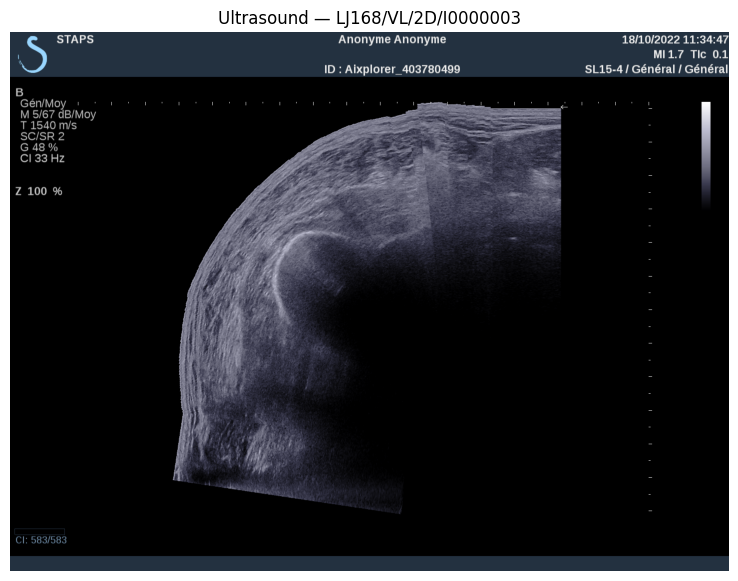

In [17]:
# ============================================================
# CELL 14: VISUALIZE ORIGINAL ULTRASOUND
# ============================================================

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 7))

plt.imshow(image_array)

plt.title(
    f"Ultrasound — {sample_path.relative_to(PATIENT_ROOT)}"
)

plt.axis("off")
plt.show()

In [18]:
# ============================================================
# CELL 15: RGB CHANNEL ANALYSIS
# ============================================================

red = image_array[:, :, 0].astype(np.float32)
green = image_array[:, :, 1].astype(np.float32)
blue = image_array[:, :, 2].astype(np.float32)

print("=" * 60)
print("RGB CHANNEL ANALYSIS")
print("=" * 60)

print("R range:", red.min(), "→", red.max())
print("G range:", green.min(), "→", green.max())
print("B range:", blue.min(), "→", blue.max())

print("\nMean absolute differences:")

print(
    "R vs G:",
    np.mean(np.abs(red - green))
)

print(
    "R vs B:",
    np.mean(np.abs(red - blue))
)

print(
    "G vs B:",
    np.mean(np.abs(green - blue))
)

RGB CHANNEL ANALYSIS
R range: 0.0 → 255.0
G range: 0.0 → 255.0
B range: 0.0 → 255.0

Mean absolute differences:
R vs G: 1.5245428
R vs B: 6.8050895
G vs B: 5.2805467


In [19]:
# ============================================================
# CELL 16: NUMPY → PYTORCH
# ============================================================

import torch

print("Before PyTorch:")
print(image_array.shape)

image_tensor = torch.from_numpy(
    image_array.copy()
)

print("\nAfter torch.from_numpy():")
print(image_tensor.shape)

# HWC → CHW

image_tensor = image_tensor.permute(
    2, 0, 1
)

print("\nAfter permute(2, 0, 1):")
print(image_tensor.shape)

# uint8 → float32

image_tensor = image_tensor.float()

# 0–255 → 0–1

image_tensor = image_tensor / 255.0

print("\nFinal tensor:")

print("Shape:", image_tensor.shape)
print("dtype:", image_tensor.dtype)

print(
    "Range:",
    image_tensor.min().item(),
    "→",
    image_tensor.max().item()
)

Before PyTorch:
(1080, 1440, 3)

After torch.from_numpy():
torch.Size([1080, 1440, 3])

After permute(2, 0, 1):
torch.Size([3, 1080, 1440])

Final tensor:
Shape: torch.Size([3, 1080, 1440])
dtype: torch.float32
Range: 0.0 → 1.0


In [20]:
# ============================================================
# CELL 17: RESIZE USING PYTORCH
# ============================================================

import torch.nn.functional as F

print(
    "Before resize:",
    image_tensor.shape
)

resized_tensor = F.interpolate(
    image_tensor.unsqueeze(0),
    size=(224, 224),
    mode="bilinear",
    align_corners=False
)

print(
    "Temporary batch shape:",
    resized_tensor.shape
)

resized_tensor = resized_tensor.squeeze(0)

print(
    "Final shape:",
    resized_tensor.shape
)

Before resize: torch.Size([3, 1080, 1440])
Temporary batch shape: torch.Size([1, 3, 224, 224])
Final shape: torch.Size([3, 224, 224])


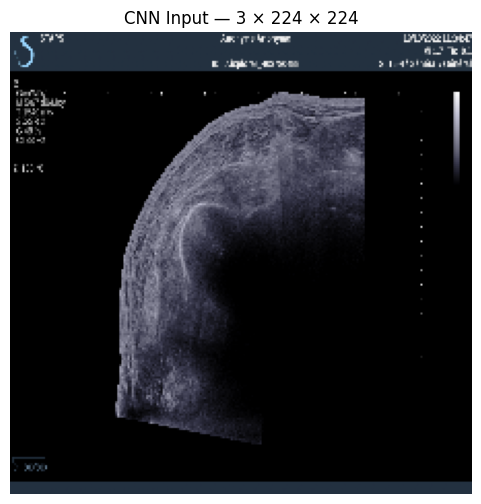

In [21]:
# ============================================================
# CELL 18: VISUALIZE PROCESSED TENSOR
# ============================================================

display_image = (
    resized_tensor
    .permute(1, 2, 0)
    .cpu()
    .numpy()
)

plt.figure(figsize=(6, 6))

plt.imshow(display_image)

plt.title("CNN Input — 3 × 224 × 224")

plt.axis("off")
plt.show()

In [22]:
# ============================================================
# CELL 19: REUSABLE DICOM → TENSOR FUNCTION
# ============================================================

def load_ultrasound(
    image_path,
    image_size=224
):
    """
    Load one DICOM ultrasound and convert it
    into a PyTorch tensor [C, H, W].
    """

    # Read DICOM
    ds = pydicom.dcmread(
        str(image_path)
    )

    # Decode JPEG-Lossless pixels
    image = ds.pixel_array

    # NumPy → Tensor
    image = torch.from_numpy(
        image.copy()
    )

    # HWC → CHW
    image = image.permute(
        2, 0, 1
    )

    # uint8 → float32
    image = image.float()

    # 0–255 → 0–1
    image = image / 255.0

    # Add temporary batch dimension
    image = image.unsqueeze(0)

    # Resize
    image = F.interpolate(
        image,
        size=(image_size, image_size),
        mode="bilinear",
        align_corners=False
    )

    # Remove temporary batch dimension
    image = image.squeeze(0)

    return image

In [23]:
# ============================================================
# CELL 20: TEST MULTIPLE MUSCLES
# ============================================================

test_files = ultrasound_files[:10]

for path in test_files:

    tensor = load_ultrasound(path)

    print(
        path.parent.parent.name,
        "|",
        tensor.shape,
        "|",
        f"{tensor.min():.3f}",
        "→",
        f"{tensor.max():.3f}"
    )

VL | torch.Size([3, 224, 224]) | 0.000 → 1.000
TA | torch.Size([3, 224, 224]) | 0.000 → 1.000
RF | torch.Size([3, 224, 224]) | 0.000 → 1.000
VL | torch.Size([3, 224, 224]) | 0.000 → 1.000
TA | torch.Size([3, 224, 224]) | 0.000 → 1.000
RF | torch.Size([3, 224, 224]) | 0.000 → 1.000
VL | torch.Size([3, 224, 224]) | 0.000 → 1.000
TA | torch.Size([3, 224, 224]) | 0.000 → 1.000
TA | torch.Size([3, 224, 224]) | 0.000 → 1.000
RF | torch.Size([3, 224, 224]) | 0.000 → 1.000


In [24]:
# ============================================================
# CELL 21: BUILD IMAGE METADATA
# ============================================================

records = []

for path in ultrasound_files:

    relative = path.relative_to(
        PATIENT_ROOT
    )

    parts = relative.parts

    # Skip reproducibility acquisitions for now
    if "Repro" in parts:
        continue

    patient_id = parts[0]
    muscle = parts[1]

    if muscle not in ["RF", "VL", "TA"]:
        continue

    records.append({
        "patient_id": patient_id,
        "muscle": muscle,
        "image_path": str(path)
    })


image_df = pd.DataFrame(records)

print("Total primary images:")
print(len(image_df))

print("\nPatients:")
print(
    image_df["patient_id"].nunique()
)

print("\nMuscle distribution:")
print(
    image_df["muscle"].value_counts()
)

display(image_df.head())

Total primary images:
184

Patients:
60

Muscle distribution:
muscle
VL    63
RF    61
TA    60
Name: count, dtype: int64


,patient_id,muscle,image_path
0,LJ168,VL,/content/sarcopenia_data/DATA_HuetJeremie_arti...
1,LJ168,TA,/content/sarcopenia_data/DATA_HuetJeremie_arti...
2,LJ168,RF,/content/sarcopenia_data/DATA_HuetJeremie_arti...
3,IJ157,VL,/content/sarcopenia_data/DATA_HuetJeremie_arti...
4,IJ157,TA,/content/sarcopenia_data/DATA_HuetJeremie_arti...


In [25]:
# ============================================================
# CELL 21B: FIND EXTRA / DUPLICATE MUSCLE IMAGES
# ============================================================

counts = (
    image_df
    .groupby(["patient_id", "muscle"])
    .size()
    .reset_index(name="image_count")
)

extra = counts[
    counts["image_count"] > 1
]

print("Patient-muscle pairs with multiple images:")
display(extra)

print("\nCorresponding files:")

for _, row in extra.iterrows():

    matches = image_df[
        (image_df["patient_id"] == row["patient_id"]) &
        (image_df["muscle"] == row["muscle"])
    ]

    print(
        f"\n{row['patient_id']} — {row['muscle']}"
    )

    for path in matches["image_path"]:
        print(path)

Patient-muscle pairs with multiple images:


,patient_id,muscle,image_count
35,CS102,RF,2
36,CS102,TA,2
52,DJ101,VL,2
67,EP105,VL,2
86,GG140,RF,2
132,PP104,TA,2
133,PP104,VL,2
136,QP108,VL,2



Corresponding files:

CS102 — RF
/content/sarcopenia_data/DATA_HuetJeremie_article/Data/CS102/RF/2D/I0000002
/content/sarcopenia_data/DATA_HuetJeremie_article/Data/CS102/RF/2D/I0000004

CS102 — TA
/content/sarcopenia_data/DATA_HuetJeremie_article/Data/CS102/TA/2D/I0000003
/content/sarcopenia_data/DATA_HuetJeremie_article/Data/CS102/TA/2D/I0000001

DJ101 — VL
/content/sarcopenia_data/DATA_HuetJeremie_article/Data/DJ101/VL/2D/I0000003
/content/sarcopenia_data/DATA_HuetJeremie_article/Data/DJ101/VL/2D/I0000004

EP105 — VL
/content/sarcopenia_data/DATA_HuetJeremie_article/Data/EP105/VL/2D/I0000003
/content/sarcopenia_data/DATA_HuetJeremie_article/Data/EP105/VL/2D/I0000004

GG140 — RF
/content/sarcopenia_data/DATA_HuetJeremie_article/Data/GG140/RF/2D/I0000003
/content/sarcopenia_data/DATA_HuetJeremie_article/Data/GG140/RF/2D/I0000002

PP104 — TA
/content/sarcopenia_data/DATA_HuetJeremie_article/Data/PP104/TA/2D/I0000003
/content/sarcopenia_data/DATA_HuetJeremie_article/Data/PP104/TA/2D/I00

In [26]:
# ============================================================
# CELL 21C: COMPARE MULTIPLE ULTRASOUND IMAGES
# ============================================================

import numpy as np
import pydicom

print("=" * 70)
print("DUPLICATE / MULTIPLE-ACQUISITION ANALYSIS")
print("=" * 70)

for _, row in extra.iterrows():

    patient = row["patient_id"]
    muscle = row["muscle"]

    matches = image_df[
        (image_df["patient_id"] == patient) &
        (image_df["muscle"] == muscle)
    ]

    paths = matches["image_path"].tolist()

    print(f"\n{patient} — {muscle}")
    print("-" * 50)

    # Read both DICOM images
    ds1 = pydicom.dcmread(paths[0])
    ds2 = pydicom.dcmread(paths[1])

    img1 = ds1.pixel_array.astype(np.float32)
    img2 = ds2.pixel_array.astype(np.float32)

    print("File 1:", Path(paths[0]).name)
    print("Shape 1:", img1.shape)

    print("File 2:", Path(paths[1]).name)
    print("Shape 2:", img2.shape)

    # Compare only if shapes match
    if img1.shape == img2.shape:

        mean_difference = np.mean(
            np.abs(img1 - img2)
        )

        max_difference = np.max(
            np.abs(img1 - img2)
        )

        identical = np.array_equal(
            img1,
            img2
        )

        print("Identical:", identical)

        print(
            "Mean pixel difference:",
            round(float(mean_difference), 4)
        )

        print(
            "Maximum pixel difference:",
            float(max_difference)
        )

    else:

        print(
            "Images have different dimensions."
        )

DUPLICATE / MULTIPLE-ACQUISITION ANALYSIS

CS102 — RF
--------------------------------------------------
File 1: I0000002
Shape 1: (1080, 1440, 3)
File 2: I0000004
Shape 2: (1080, 1440, 3)
Identical: False
Mean pixel difference: 14.8457
Maximum pixel difference: 255.0

CS102 — TA
--------------------------------------------------
File 1: I0000003
Shape 1: (1080, 1440, 3)
File 2: I0000001
Shape 2: (1080, 1440, 3)
Identical: False
Mean pixel difference: 11.6746
Maximum pixel difference: 255.0

DJ101 — VL
--------------------------------------------------
File 1: I0000003
Shape 1: (1080, 1440, 3)
File 2: I0000004
Shape 2: (1080, 1440, 3)
Identical: False
Mean pixel difference: 17.625
Maximum pixel difference: 255.0

EP105 — VL
--------------------------------------------------
File 1: I0000003
Shape 1: (1080, 1440, 3)
File 2: I0000004
Shape 2: (1080, 1440, 3)
Identical: False
Mean pixel difference: 16.9978
Maximum pixel difference: 255.0

GG140 — RF
---------------------------------------

In [27]:
# ============================================================
# CELL 22: MERGE IMAGING + CLINICAL DATA
# ============================================================

# Clean patient IDs
image_df["patient_id"] = (
    image_df["patient_id"]
    .astype(str)
    .str.strip()
)

clinical_df["ID_patient"] = (
    clinical_df["ID_patient"]
    .astype(str)
    .str.strip()
)

# Merge
dataset_df = image_df.merge(
    clinical_df,
    left_on="patient_id",
    right_on="ID_patient",
    how="left",
    validate="many_to_one"
)

print("=" * 60)
print("MULTIMODAL DATASET")
print("=" * 60)

print("Total image records:", len(dataset_df))

print(
    "Unique patients:",
    dataset_df["patient_id"].nunique()
)

print(
    "Clinical matching failures:",
    dataset_df["ID_patient"].isna().sum()
)

print("\nMuscle distribution:")

print(
    dataset_df["muscle"].value_counts()
)

display(
    dataset_df[
        [
            "patient_id",
            "muscle",
            "Age",
            "Sexe",
            "Vmarche",
            "FTSS",
            "MVIC_quadri",
            "Hand_grip",
            "Volume_RF",
            "Volume_VL",
            "Volume_TA"
        ]
    ].head(10)
)

MULTIMODAL DATASET
Total image records: 184
Unique patients: 60
Clinical matching failures: 3

Muscle distribution:
muscle
VL    63
RF    61
TA    60
Name: count, dtype: int64


,patient_id,muscle,Age,Sexe,Vmarche,FTSS,MVIC_quadri,Hand_grip,Volume_RF,Volume_VL,Volume_TA
0,LJ168,VL,77.0,1.0,0.2,14.5,31.8,25.6,145.0,334.0,221.0
1,LJ168,TA,77.0,1.0,0.2,14.5,31.8,25.6,145.0,334.0,221.0
2,LJ168,RF,77.0,1.0,0.2,14.5,31.8,25.6,145.0,334.0,221.0
3,IJ157,VL,88.0,0.0,0.5,10,24.9,18.9,86.0,187.0,131.0
4,IJ157,TA,88.0,0.0,0.5,10,24.9,18.9,86.0,187.0,131.0
5,IJ157,RF,88.0,0.0,0.5,10,24.9,18.9,86.0,187.0,131.0
6,CS102,VL,88.0,0.0,0.5,21,16.6,15.4,93.0,276.0,207.0
7,CS102,TA,88.0,0.0,0.5,21,16.6,15.4,93.0,276.0,207.0
8,CS102,TA,88.0,0.0,0.5,21,16.6,15.4,93.0,276.0,207.0
9,CS102,RF,88.0,0.0,0.5,21,16.6,15.4,93.0,276.0,207.0


In [28]:
# ============================================================
# CELL 23: CLINICAL MISSING-VALUE AUDIT
# ============================================================

important_features = [
    "Age",
    "Taille",
    "Poids",
    "Sexe",
    "Vmarche",
    "FTSS",
    "MVIC_quadri",
    "MVIC_releveur",
    "Hand_grip",
    "DXA",
    "IMS_kgm2"
]

print("=" * 60)
print("IMPORTANT CLINICAL FEATURES")
print("=" * 60)

for feature in important_features:

    missing = (
        clinical_df[feature]
        .isna()
        .sum()
    )

    available = (
        len(clinical_df)
        - missing
    )

    print(
        f"{feature:<18}"
        f"available={available:<3} "
        f"missing={missing}"
    )

IMPORTANT CLINICAL FEATURES
Age               available=60  missing=0
Taille            available=60  missing=0
Poids             available=60  missing=0
Sexe              available=60  missing=0
Vmarche           available=59  missing=1
FTSS              available=59  missing=1
MVIC_quadri       available=59  missing=1
MVIC_releveur     available=56  missing=4
Hand_grip         available=60  missing=0
DXA               available=60  missing=0
IMS_kgm2          available=22  missing=38


In [29]:
# ============================================================
# CELL 24: PATIENT-LEVEL SPLIT
# ============================================================

from sklearn.model_selection import train_test_split

patient_ids = (
    dataset_df["patient_id"]
    .unique()
)

print(
    "Patients before splitting:",
    len(patient_ids)
)

train_patients, temp_patients = train_test_split(
    patient_ids,
    test_size=0.30,
    random_state=SEED
)

val_patients, test_patients = train_test_split(
    temp_patients,
    test_size=0.50,
    random_state=SEED
)

train_df = dataset_df[
    dataset_df["patient_id"].isin(train_patients)
].reset_index(drop=True)

val_df = dataset_df[
    dataset_df["patient_id"].isin(val_patients)
].reset_index(drop=True)

test_df = dataset_df[
    dataset_df["patient_id"].isin(test_patients)
].reset_index(drop=True)


print("\nTRAIN")
print(
    len(train_patients),
    "patients |",
    len(train_df),
    "images"
)

print("\nVALIDATION")
print(
    len(val_patients),
    "patients |",
    len(val_df),
    "images"
)

print("\nTEST")
print(
    len(test_patients),
    "patients |",
    len(test_df),
    "images"
)

Patients before splitting: 60

TRAIN
42 patients | 129 images

VALIDATION
9 patients | 27 images

TEST
9 patients | 28 images


In [30]:
# ============================================================
# CELL 25: PATIENT LEAKAGE CHECK
# ============================================================

train_ids = set(
    train_df["patient_id"]
)

val_ids = set(
    val_df["patient_id"]
)

test_ids = set(
    test_df["patient_id"]
)

print("=" * 60)
print("LEAKAGE CHECK")
print("=" * 60)

print(
    "Train ∩ Validation:",
    train_ids & val_ids
)

print(
    "Train ∩ Test:",
    train_ids & test_ids
)

print(
    "Validation ∩ Test:",
    val_ids & test_ids
)

assert train_ids.isdisjoint(val_ids)
assert train_ids.isdisjoint(test_ids)
assert val_ids.isdisjoint(test_ids)

print("\n✓ No patient leakage detected.")

LEAKAGE CHECK
Train ∩ Validation: set()
Train ∩ Test: set()
Validation ∩ Test: set()

✓ No patient leakage detected.


In [31]:
# ============================================================
# CELL 26: DICOM → PYTORCH TENSOR
# ============================================================

import torch
import torch.nn.functional as F
import pydicom
import numpy as np


def load_ultrasound(
    image_path,
    image_size=224
):

    # Read DICOM
    ds = pydicom.dcmread(
        str(image_path)
    )

    # Decode JPEG-Lossless image
    image = ds.pixel_array

    # Ensure RGB format
    if image.ndim != 3:
        raise ValueError(
            f"Expected RGB image, got shape {image.shape}"
        )

    # NumPy HWC → Tensor CHW
    image = torch.from_numpy(
        image.copy()
    ).permute(
        2, 0, 1
    )

    # uint8 → float32
    image = image.float()

    # [0,255] → [0,1]
    image = image / 255.0

    # Add temporary batch dimension
    image = image.unsqueeze(0)

    # Resize
    image = F.interpolate(
        image,
        size=(image_size, image_size),
        mode="bilinear",
        align_corners=False
    )

    # Remove temporary batch dimension
    image = image.squeeze(0)

    return image

In [32]:
# ============================================================
# CELL 27: TEST PREPROCESSING
# ============================================================

test_path = train_df.iloc[0][
    "image_path"
]

tensor_image = load_ultrasound(
    test_path
)

print("=" * 60)
print("PROCESSED ULTRASOUND")
print("=" * 60)

print(
    "Shape:",
    tensor_image.shape
)

print(
    "dtype:",
    tensor_image.dtype
)

print(
    "Minimum:",
    tensor_image.min().item()
)

print(
    "Maximum:",
    tensor_image.max().item()
)

PROCESSED ULTRASOUND
Shape: torch.Size([3, 224, 224])
dtype: torch.float32
Minimum: 0.0
Maximum: 1.0


In [33]:
# ============================================================
# CELL 28: CUSTOM PYTORCH DATASET
# ============================================================

from torch.utils.data import Dataset


class SarcopeniaDataset(Dataset):

    def __init__(
        self,
        dataframe,
        image_size=224
    ):

        self.dataframe = (
            dataframe
            .reset_index(drop=True)
            .copy()
        )

        self.image_size = image_size


    def __len__(self):

        return len(
            self.dataframe
        )


    def __getitem__(
        self,
        index
    ):

        row = self.dataframe.iloc[
            index
        ]

        image = load_ultrasound(
            row["image_path"],
            self.image_size
        )

        return {
            "image": image,
            "patient_id": row["patient_id"],
            "muscle": row["muscle"]
        }

In [34]:
# ============================================================
# CELL 29: CREATE DATASETS
# ============================================================

train_dataset = SarcopeniaDataset(
    train_df
)

val_dataset = SarcopeniaDataset(
    val_df
)

test_dataset = SarcopeniaDataset(
    test_df
)


print(
    "Train samples:",
    len(train_dataset)
)

print(
    "Validation samples:",
    len(val_dataset)
)

print(
    "Test samples:",
    len(test_dataset)
)


sample = train_dataset[0]

print("\nFirst sample:")

print(
    "Image:",
    sample["image"].shape
)

print(
    "Patient:",
    sample["patient_id"]
)

print(
    "Muscle:",
    sample["muscle"]
)

Train samples: 129
Validation samples: 27
Test samples: 28

First sample:
Image: torch.Size([3, 224, 224])
Patient: IJ157
Muscle: VL


In [35]:
# ============================================================
# CELL 30: DATALOADERS
# ============================================================

from torch.utils.data import DataLoader

BATCH_SIZE = 8


train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)


batch = next(
    iter(train_loader)
)

print("=" * 60)
print("FIRST PYTORCH BATCH")
print("=" * 60)

print(
    "Images:",
    batch["image"].shape
)

print(
    "\nPatients:",
    batch["patient_id"]
)

print(
    "\nMuscles:",
    batch["muscle"]
)

FIRST PYTORCH BATCH
Images: torch.Size([8, 3, 224, 224])

Patients: ['CS102', 'LA134', 'DH156', 'QP108', 'LA162', 'DP172', 'ZS153', 'LA162']

Muscles: ['TA', 'TA', 'VL', 'TA', 'RF', 'TA', 'VL', 'TA']


In [36]:
# ============================================================
# CELL 31: INVESTIGATE CLINICAL MATCHING FAILURES
# ============================================================

unmatched = dataset_df[
    dataset_df["ID_patient"].isna()
][
    [
        "patient_id",
        "muscle",
        "image_path"
    ]
]

print("=" * 60)
print("UNMATCHED IMAGING RECORDS")
print("=" * 60)

print(
    "Unmatched images:",
    len(unmatched)
)

print(
    "Unmatched patients:",
    unmatched["patient_id"].nunique()
)

display(unmatched)


print("\nImaging patient IDs not found in clinical table:")

imaging_ids = set(
    image_df["patient_id"]
)

clinical_ids = set(
    clinical_df["ID_patient"]
)

print(
    sorted(
        imaging_ids - clinical_ids
    )
)


print("\nClinical IDs without imaging folder:")

print(
    sorted(
        clinical_ids - imaging_ids
    )
)

UNMATCHED IMAGING RECORDS
Unmatched images: 3
Unmatched patients: 1


,patient_id,muscle,image_path
92,DI154,VL,/content/sarcopenia_data/DATA_HuetJeremie_arti...
93,DI154,TA,/content/sarcopenia_data/DATA_HuetJeremie_arti...
94,DI154,RF,/content/sarcopenia_data/DATA_HuetJeremie_arti...



Imaging patient IDs not found in clinical table:
['DI154']

Clinical IDs without imaging folder:
['DJ154']


In [37]:
# ============================================================
# CELL 32: RECONCILE PATIENT ID MISMATCH
# ============================================================

# Preserve original imaging IDs
image_df["original_patient_id"] = image_df["patient_id"]

# Explicit documented correction
ID_CORRECTIONS = {
    "DI154": "DJ154"
}

image_df["patient_id"] = (
    image_df["patient_id"]
    .replace(ID_CORRECTIONS)
)

print("=" * 60)
print("PATIENT ID RECONCILIATION")
print("=" * 60)

print("Corrections applied:")
print(ID_CORRECTIONS)

print("\nAffected records:")

display(
    image_df[
        image_df["original_patient_id"] !=
        image_df["patient_id"]
    ][
        [
            "original_patient_id",
            "patient_id",
            "muscle",
            "image_path"
        ]
    ]
)

PATIENT ID RECONCILIATION
Corrections applied:
{'DI154': 'DJ154'}

Affected records:


,original_patient_id,patient_id,muscle,image_path
92,DI154,DJ154,VL,/content/sarcopenia_data/DATA_HuetJeremie_arti...
93,DI154,DJ154,TA,/content/sarcopenia_data/DATA_HuetJeremie_arti...
94,DI154,DJ154,RF,/content/sarcopenia_data/DATA_HuetJeremie_arti...


In [38]:
# ============================================================
# CELL 34: FINAL DAY 1 VALIDATION & FIX
# ============================================================

# 1. Re-merge the corrected image_df with clinical_df
dataset_df = image_df.merge(
    clinical_df,
    left_on="patient_id",
    right_on="ID_patient",
    how="left",
    validate="many_to_one"
)

# 2. Recreate the patient-level splits to avoid leakage and include the fix
train_df = dataset_df[
    dataset_df["patient_id"].isin(train_patients)
].reset_index(drop=True)

val_df = dataset_df[
    dataset_df["patient_id"].isin(val_patients)
].reset_index(drop=True)

test_df = dataset_df[
    dataset_df["patient_id"].isin(test_patients)
].reset_index(drop=True)

# 3. Recreate PyTorch Datasets and DataLoaders
train_dataset = SarcopeniaDataset(train_df)
val_dataset = SarcopeniaDataset(val_df)
test_dataset = SarcopeniaDataset(test_df)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

print("=" * 65)
print("SARCOPENIA AI — DAY 1 FINAL VALIDATION")
print("=" * 65)

# Dataset
print("\nDATA")
print("Images:", len(dataset_df))
print("Patients:", dataset_df["patient_id"].nunique())
print(
    "Muscles:",
    dataset_df["muscle"].value_counts().to_dict()
)

# Clinical matching
unmatched = dataset_df["ID_patient"].isna().sum()

print("\nCLINICAL MATCHING")
print("Unmatched:", unmatched)

# Splits
print("\nPATIENT SPLITS")
print("Train:", train_df["patient_id"].nunique())
print("Validation:", val_df["patient_id"].nunique())
print("Test:", test_df["patient_id"].nunique())

# Leakage
train_ids = set(train_df["patient_id"])
val_ids = set(val_df["patient_id"])
test_ids = set(test_df["patient_id"])

no_leakage = (
    train_ids.isdisjoint(val_ids)
    and train_ids.isdisjoint(test_ids)
    and val_ids.isdisjoint(test_ids)
)

print("No patient leakage:", no_leakage)

# Dataset
print("\nPYTORCH DATASET")
print("Train samples:", len(train_dataset))
print("Validation samples:", len(val_dataset))
print("Test samples:", len(test_dataset))

# Batch
batch = next(iter(train_loader))

print("\nDATALOADER")
print("Batch shape:", batch["image"].shape)
print("dtype:", batch["image"].dtype)

print(
    "Range:",
    round(batch["image"].min().item(), 3),
    "→",
    round(batch["image"].max().item(), 3)
)

# Assertions
assert len(dataset_df) == 184
assert dataset_df["patient_id"].nunique() == 60
assert unmatched == 0
assert no_leakage
assert batch["image"].shape[1:] == (3, 224, 224)

print("\n" + "=" * 65)
print("✓ DAY 1 PIPELINE PASSED")
print("=" * 65)

SARCOPENIA AI — DAY 1 FINAL VALIDATION

DATA
Images: 184
Patients: 60
Muscles: {'VL': 63, 'RF': 61, 'TA': 60}

CLINICAL MATCHING
Unmatched: 0

PATIENT SPLITS
Train: 41
Validation: 9
Test: 9
No patient leakage: True

PYTORCH DATASET
Train samples: 126
Validation samples: 27
Test samples: 28

DATALOADER
Batch shape: torch.Size([8, 3, 224, 224])
dtype: torch.float32
Range: 0.0 → 1.0

✓ DAY 1 PIPELINE PASSED


## Custom CNN

In [40]:
# ============================================================
# CELL 36: INSPECT POSSIBLE TARGET VARIABLES
# ============================================================

target_candidates = [
    "Sexe",
    "Hand_grip",
    "Vmarche",
    "FTSS",
    "DXA",
    "IMS_kgm2",
    "M_maigre_g",
    "M_grasse_g",
    "CSA_TA_cm2",
    "MT_TA_cm",
    "CSA_RF_cm2",
    "MT_RF_cm",
    "CSA_VL_cm2",
    "MT_VL_cm"
]

print("=" * 75)
print("POSSIBLE SARCOPENIA-RELATED VARIABLES")
print("=" * 75)

for column in target_candidates:

    values = clinical_df[column]

    print(f"\n{column}")
    print("-" * 40)

    print("Available:", values.notna().sum())
    print("Missing:", values.isna().sum())

    if pd.api.types.is_numeric_dtype(values):

        print("Min:", values.min())
        print("Max:", values.max())
        print("Mean:", round(values.mean(), 3))
        print("Median:", round(values.median(), 3))

        print(
            "Unique:",
            values.nunique()
        )

    else:

        print(
            values.value_counts(
                dropna=False
            )
        )

POSSIBLE SARCOPENIA-RELATED VARIABLES

Sexe
----------------------------------------
Available: 60
Missing: 0
Min: 0
Max: 1
Mean: 0.367
Median: 0.0
Unique: 2

Hand_grip
----------------------------------------
Available: 60
Missing: 0
Min: 8.9
Max: 36.9
Mean: 18.188
Median: 16.2
Unique: 48

Vmarche
----------------------------------------
Available: 59
Missing: 1
Vmarche
0.8           5
Impossible    5
0.5           4
0.57          3
0.4           3
0.3           3
1.14          3
0.67          2
0.6           2
0.9           2
0.73          2
0.2           2
1.05          2
1             2
1.2           1
1.25          1
0.74          1
0.42          1
0.53          1
0.11          1
0.95          1
0.68          1
0.47          1
0.7           1
0.22          1
0.18          1
NaN           1
0.16          1
0.93          1
0.62          1
1.3           1
0.31          1
0.75          1
0.44          1
Name: count, dtype: int64

FTSS
----------------------------------------
Available

In [41]:
# ============================================================
# CELL 37: PATIENT-LEVEL CLINICAL INSPECTION
# ============================================================

clinical_view = clinical_df[
    [
        "ID_patient",
        "Age",
        "Sexe",
        "Taille",
        "Poids",
        "Hand_grip",
        "Vmarche",
        "FTSS",
        "DXA",
        "IMS_kgm2",
        "M_maigre_g",
        "CSA_RF_cm2",
        "MT_RF_cm",
        "CSA_VL_cm2",
        "MT_VL_cm",
        "CSA_TA_cm2",
        "MT_TA_cm"
    ]
].copy()

display(
    clinical_view.head(20)
)

,ID_patient,Age,Sexe,Taille,Poids,Hand_grip,Vmarche,FTSS,DXA,IMS_kgm2,M_maigre_g,CSA_RF_cm2,MT_RF_cm,CSA_VL_cm2,MT_VL_cm,CSA_TA_cm2,MT_TA_cm
0,DJ101,90,1,168,73.2,36.8,1.2,12,0,NaN,NaN,3.756370,0.986893,11.649393,0.946556,6.429902,2.420930
1,CS102,88,0,162,69.1,15.4,0.5,21,0,NaN,NaN,5.370713,1.039280,14.074999,1.275766,9.234279,2.640845
2,BM103,86,0,150,74.0,13.6,0.3,33,0,NaN,NaN,5.122222,1.000000,13.433406,1.132100,9.112245,2.592857
3,PP104,87,1,160,71.3,16.4,0.4,12,1,6.66,40340.0,4.943754,1.089645,9.248488,0.636637,10.637994,2.721925
4,EP105,91,1,171,69.0,22.3,0.8,10,1,7.59,54129.0,4.710059,1.069231,11.402880,1.132556,6.491768,2.307746
5,QP108,92,1,165,47.2,13.7,Impossible,Impossible,0,NaN,NaN,2.906169,0.597183,4.974805,0.666667,5.080551,1.782946
6,RJ109,82,1,185,77.6,19.8,0.42,17,0,NaN,NaN,5.000000,1.545000,9.752229,0.690972,8.502959,2.692308
7,AM112,82,1,165,61.0,24.8,0.6,22,0,NaN,NaN,5.572385,1.267857,8.756716,0.767961,9.382972,2.446429
8,MA113,86,0,160,67.6,13.5,0.74,20,0,NaN,NaN,3.571598,1.207692,11.560000,0.980000,7.384615,2.646154
9,CG115,81,0,161,59.6,16.1,0.8,18,1,5.86,39981.0,2.619527,0.761538,10.263661,0.926880,6.600873,2.140845


In [42]:
# ============================================================
# CELL 38: UNDERSTAND SEX CODING
# ============================================================

sex_summary = (
    clinical_df
    .groupby("Sexe")
    .agg(
        patients=("ID_patient", "count"),
        mean_height=("Taille", "mean"),
        mean_weight=("Poids", "mean"),
        mean_grip=("Hand_grip", "mean"),
        median_grip=("Hand_grip", "median"),
        min_grip=("Hand_grip", "min"),
        max_grip=("Hand_grip", "max")
    )
)

print("=" * 70)
print("SEX CODING INVESTIGATION")
print("=" * 70)

display(sex_summary)

print("\nPatient examples:")

display(
    clinical_df[
        [
            "ID_patient",
            "Sexe",
            "Taille",
            "Poids",
            "Hand_grip"
        ]
    ]
    .sort_values("Sexe")
    .head(30)
)

SEX CODING INVESTIGATION


,patients,mean_height,mean_weight,mean_grip,median_grip,min_grip,max_grip
Sexe,,,,,,,
0,38,157.736842,56.092105,14.886842,14.35,8.9,23.1
1,22,167.727273,70.200000,23.890909,23.65,13.7,36.9



Patient examples:


,ID_patient,Sexe,Taille,Poids,Hand_grip
1,CS102,0,162,69.1,15.4
2,BM103,0,150,74.0,13.6
14,FD121,0,163,73.7,13.5
12,MA119,0,145,46.0,8.9
11,FO117,0,160,49.0,10.9
10,BH116,0,170,41.1,23.1
9,CG115,0,161,59.6,16.1
8,MA113,0,160,67.6,13.5
15,BA122,0,155,63.0,14.7
26,LP133,0,149,48.7,12.8


In [43]:
# ============================================================
# CELL 39: CREATE EWGSOP2 LOW-STRENGTH TARGET
# ============================================================

def create_low_strength_target(row):

    sex = row["Sexe"]
    grip = row["Hand_grip"]

    # Female
    if sex == 0:
        return int(grip < 16)

    # Male
    elif sex == 1:
        return int(grip < 27)

    else:
        raise ValueError(
            f"Unknown sex code: {sex}"
        )


clinical_df["low_muscle_strength"] = clinical_df.apply(
    create_low_strength_target,
    axis=1
)

print("=" * 65)
print("LOW MUSCLE STRENGTH TARGET")
print("=" * 65)

print(
    clinical_df[
        "low_muscle_strength"
    ].value_counts()
)

print("\nPercentages:")

print(
    clinical_df[
        "low_muscle_strength"
    ].value_counts(normalize=True)
    * 100
)

LOW MUSCLE STRENGTH TARGET
low_muscle_strength
1    41
0    19
Name: count, dtype: int64

Percentages:
low_muscle_strength
1    68.333333
0    31.666667
Name: proportion, dtype: float64


In [44]:
# ============================================================
# CELL 41: ADD TARGET TO MULTIMODAL DATASET
# ============================================================

target_df = clinical_df[
    [
        "ID_patient",
        "low_muscle_strength"
    ]
].copy()

# Remove old target if this cell is rerun
if "low_muscle_strength" in dataset_df.columns:
    dataset_df = dataset_df.drop(
        columns=["low_muscle_strength"]
    )

dataset_df = dataset_df.merge(
    target_df,
    on="ID_patient",
    how="left",
    validate="many_to_one"
)

print("=" * 65)
print("TARGET ADDED TO IMAGING DATA")
print("=" * 65)

print(
    "Images:",
    len(dataset_df)
)

print(
    "Patients:",
    dataset_df["patient_id"].nunique()
)

print(
    "Missing targets:",
    dataset_df["low_muscle_strength"].isna().sum()
)

print("\nImage-level records:")

print(
    dataset_df[
        "low_muscle_strength"
    ].value_counts()
)

assert dataset_df["low_muscle_strength"].isna().sum() == 0

TARGET ADDED TO IMAGING DATA
Images: 184
Patients: 60
Missing targets: 0

Image-level records:
low_muscle_strength
1    127
0     57
Name: count, dtype: int64


In [45]:
# ============================================================
# CELL 42: STRATIFIED PATIENT-LEVEL SPLIT
# ============================================================

from sklearn.model_selection import train_test_split

patient_table = (
    dataset_df[
        ["patient_id", "low_muscle_strength"]
    ]
    .drop_duplicates("patient_id")
    .reset_index(drop=True)
)

# 70% train, 30% temporary
train_patients, temp_patients = train_test_split(
    patient_table,
    test_size=0.30,
    random_state=SEED,
    stratify=patient_table["low_muscle_strength"]
)

# Split remaining 30% into validation/test
val_patients, test_patients = train_test_split(
    temp_patients,
    test_size=0.50,
    random_state=SEED,
    stratify=temp_patients["low_muscle_strength"]
)

train_df = dataset_df[
    dataset_df["patient_id"].isin(
        train_patients["patient_id"]
    )
].reset_index(drop=True)

val_df = dataset_df[
    dataset_df["patient_id"].isin(
        val_patients["patient_id"]
    )
].reset_index(drop=True)

test_df = dataset_df[
    dataset_df["patient_id"].isin(
        test_patients["patient_id"]
    )
].reset_index(drop=True)


for name, df in [
    ("TRAIN", train_df),
    ("VALIDATION", val_df),
    ("TEST", test_df)
]:

    patient_labels = (
        df[
            ["patient_id", "low_muscle_strength"]
        ]
        .drop_duplicates()
    )

    print("\n" + name)
    print("-" * 40)

    print(
        "Patients:",
        len(patient_labels)
    )

    print(
        patient_labels[
            "low_muscle_strength"
        ].value_counts()
    )


TRAIN
----------------------------------------
Patients: 42
low_muscle_strength
1    29
0    13
Name: count, dtype: int64

VALIDATION
----------------------------------------
Patients: 9
low_muscle_strength
1    6
0    3
Name: count, dtype: int64

TEST
----------------------------------------
Patients: 9
low_muscle_strength
1    6
0    3
Name: count, dtype: int64


In [46]:
# ============================================================
# CELL 43: LABELED PYTORCH DATASET
# ============================================================

from torch.utils.data import Dataset


class SarcopeniaDataset(Dataset):

    def __init__(
        self,
        dataframe,
        image_size=224
    ):

        self.dataframe = (
            dataframe
            .reset_index(drop=True)
            .copy()
        )

        self.image_size = image_size


    def __len__(self):

        return len(self.dataframe)


    def __getitem__(
        self,
        index
    ):

        row = self.dataframe.iloc[index]

        image = load_ultrasound(
            row["image_path"],
            self.image_size
        )

        target = torch.tensor(
            row["low_muscle_strength"],
            dtype=torch.float32
        )

        return {
            "image": image,
            "target": target,
            "patient_id": row["patient_id"],
            "muscle": row["muscle"]
        }

In [47]:
# ============================================================
# CELL 44: LABELED DATALOADERS
# ============================================================

from torch.utils.data import DataLoader

BATCH_SIZE = 8

train_dataset = SarcopeniaDataset(train_df)
val_dataset = SarcopeniaDataset(val_df)
test_dataset = SarcopeniaDataset(test_df)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

batch = next(iter(train_loader))

print("Images :", batch["image"].shape)
print("Targets:", batch["target"].shape)

print("\nTargets:")
print(batch["target"])

Images : torch.Size([8, 3, 224, 224])
Targets: torch.Size([8])

Targets:
tensor([1., 1., 1., 1., 0., 1., 0., 1.])


In [48]:
# ============================================================
# CELL 45: FIRST CONVOLUTION
# ============================================================

import torch.nn as nn

conv1 = nn.Conv2d(
    in_channels=3,
    out_channels=16,
    kernel_size=3,
    padding=1
)

images = batch["image"]

print(
    "Before Conv2d:",
    images.shape
)

output = conv1(images)

print(
    "After Conv2d :",
    output.shape
)

Before Conv2d: torch.Size([8, 3, 224, 224])
After Conv2d : torch.Size([8, 16, 224, 224])


In [49]:
# ============================================================
# CELL 46: CONV → RELU → POOL
# ============================================================

relu = nn.ReLU()

pool = nn.MaxPool2d(
    kernel_size=2,
    stride=2
)

x = batch["image"]

print(
    "Input:       ",
    x.shape
)

x = conv1(x)

print(
    "After Conv:  ",
    x.shape
)

x = relu(x)

print(
    "After ReLU:  ",
    x.shape
)

x = pool(x)

print(
    "After Pool:  ",
    x.shape
)

Input:        torch.Size([8, 3, 224, 224])
After Conv:   torch.Size([8, 16, 224, 224])
After ReLU:   torch.Size([8, 16, 224, 224])
After Pool:   torch.Size([8, 16, 112, 112])


In [50]:
# ============================================================
# CELL 47: CUSTOM SARCOPENIA CNN
# ============================================================

import torch
import torch.nn as nn


class SarcopeniaCNN(nn.Module):

    def __init__(self):

        super().__init__()

        # ----------------------------
        # FEATURE EXTRACTOR
        # ----------------------------

        self.features = nn.Sequential(

            # Block 1
            nn.Conv2d(
                3,
                16,
                kernel_size=3,
                padding=1
            ),
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.MaxPool2d(2),

            # Block 2
            nn.Conv2d(
                16,
                32,
                kernel_size=3,
                padding=1
            ),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),

            # Block 3
            nn.Conv2d(
                32,
                64,
                kernel_size=3,
                padding=1
            ),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),

            # Block 4
            nn.Conv2d(
                64,
                128,
                kernel_size=3,
                padding=1
            ),
            nn.BatchNorm2d(128),
            nn.ReLU(),

            # Force output to 1×1
            nn.AdaptiveAvgPool2d(
                (1, 1)
            )
        )

        # ----------------------------
        # CLASSIFIER
        # ----------------------------

        self.classifier = nn.Sequential(

            nn.Flatten(),

            nn.Linear(
                128,
                64
            ),

            nn.ReLU(),

            nn.Dropout(0.4),

            nn.Linear(
                64,
                1
            )
        )


    def forward(self, x):

        x = self.features(x)

        x = self.classifier(x)

        return x

In [51]:
# ============================================================
# CELL 48: CREATE MODEL
# ============================================================

model = SarcopeniaCNN()

print(model)

SarcopeniaCNN(
  (features): Sequential(
    (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (12): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True

In [52]:
# ============================================================
# CELL 49: FORWARD PASS
# ============================================================

images = batch["image"]

print(
    "CNN input:",
    images.shape
)

logits = model(images)

print(
    "CNN output:",
    logits.shape
)

print("\nRaw logits:")

print(
    logits.squeeze()
)

CNN input: torch.Size([8, 3, 224, 224])
CNN output: torch.Size([8, 1])

Raw logits:
tensor([ 0.0713,  0.0419, -0.0349, -0.0815,  0.0782,  0.0559, -0.0786,  0.0674],
       grad_fn=<SqueezeBackward0>)


In [53]:
# ============================================================
# CELL 50: LOGITS → PROBABILITIES
# ============================================================

probabilities = torch.sigmoid(
    logits
)

predictions = (
    probabilities >= 0.5
).int()

print("Probabilities:")

print(
    probabilities.squeeze()
)

print("\nPredicted classes:")

print(
    predictions.squeeze()
)

print("\nTrue classes:")

print(
    batch["target"].int()
)

Probabilities:
tensor([0.5178, 0.5105, 0.4913, 0.4796, 0.5195, 0.5140, 0.4804, 0.5168],
       grad_fn=<SqueezeBackward0>)

Predicted classes:
tensor([1, 1, 0, 0, 1, 1, 0, 1], dtype=torch.int32)

True classes:
tensor([1, 1, 1, 1, 0, 1, 0, 1], dtype=torch.int32)


In [54]:
# ============================================================
# CELL 51: MODEL PARAMETERS
# ============================================================

total_parameters = sum(
    p.numel()
    for p in model.parameters()
)

trainable_parameters = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)

print(
    f"Total parameters: "
    f"{total_parameters:,}"
)

print(
    f"Trainable parameters: "
    f"{trainable_parameters:,}"
)

Total parameters: 106,241
Trainable parameters: 106,241


In [55]:
# ============================================================
# CELL 52: MOVE MODEL + DATA TO GPU
# ============================================================

device = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)

model = model.to(device)

images = batch["image"].to(device)

targets = batch["target"].to(device)

logits = model(images)

print(
    "Device:",
    device
)

print(
    "Images:",
    images.device
)

print(
    "Targets:",
    targets.device
)

print(
    "Model output:",
    logits.device
)

print(
    "Output shape:",
    logits.shape
)

Device: cuda
Images: cuda:0
Targets: cuda:0
Model output: cuda:0
Output shape: torch.Size([8, 1])


In [56]:
# ============================================================
# CELL 53: PREPARE MODEL FOR TRAINING
# ============================================================

import torch
import torch.nn as nn

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

model = SarcopeniaCNN().to(device)

print("Device:", device)

print(
    "Trainable parameters:",
    f"{sum(p.numel() for p in model.parameters() if p.requires_grad):,}"
)

Device: cuda
Trainable parameters: 106,241


In [57]:
# ============================================================
# CELL 54: CLASS IMBALANCE
# ============================================================

patient_train_labels = (
    train_df[
        ["patient_id", "low_muscle_strength"]
    ]
    .drop_duplicates("patient_id")
)

class_counts = (
    patient_train_labels[
        "low_muscle_strength"
    ]
    .value_counts()
)

negative_count = class_counts.get(0, 0)
positive_count = class_counts.get(1, 0)

pos_weight_value = (
    negative_count / positive_count
)

pos_weight = torch.tensor(
    [pos_weight_value],
    dtype=torch.float32,
    device=device
)

print("Training patients:")
print("Class 0:", negative_count)
print("Class 1:", positive_count)

print(
    "\npos_weight:",
    round(pos_weight_value, 4)
)

Training patients:
Class 0: 13
Class 1: 29

pos_weight: 0.4483


In [58]:
# ============================================================
# CELL 55: LOSS + OPTIMIZER
# ============================================================

criterion = nn.BCEWithLogitsLoss(
    pos_weight=pos_weight
)

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=1e-3,
    weight_decay=1e-4
)

print("Loss:")
print(criterion)

print("\nOptimizer:")
print(type(optimizer).__name__)

Loss:
BCEWithLogitsLoss()

Optimizer:
AdamW


In [ ]:
# ============================================================
# CELL 56: ONE TRAINING STEP
# ============================================================

model.train()

batch = next(iter(train_loader))

images = batch["image"].to(
    device,
    non_blocking=True
)

targets = batch["target"].to(
    device,
    non_blocking=True
)

# Remove previous gradients
optimizer.zero_grad()

# Forward pass
logits = model(images).squeeze(1)

# Calculate loss
loss = criterion(
    logits,
    targets
)

# Backpropagation
loss.backward()

# Update weights
optimizer.step()

print("Images:", images.shape)
print("Logits:", logits.shape)
print("Targets:", targets.shape)

print(
    "Loss:",
    round(loss.item(), 4)
)

In [59]:
# ============================================================
# CELL 57: TRAIN ONE EPOCH
# ============================================================

def train_one_epoch(
    model,
    loader,
    criterion,
    optimizer,
    device
):

    model.train()

    total_loss = 0.0
    correct = 0
    total = 0

    for batch in loader:

        images = batch["image"].to(
            device,
            non_blocking=True
        )

        targets = batch["target"].to(
            device,
            non_blocking=True
        )

        optimizer.zero_grad()

        logits = model(
            images
        ).squeeze(1)

        loss = criterion(
            logits,
            targets
        )

        loss.backward()

        optimizer.step()

        total_loss += (
            loss.item()
            * images.size(0)
        )

        probabilities = torch.sigmoid(
            logits
        )

        predictions = (
            probabilities >= 0.5
        ).float()

        correct += (
            predictions == targets
        ).sum().item()

        total += targets.size(0)

    epoch_loss = (
        total_loss / total
    )

    epoch_accuracy = (
        correct / total
    )

    return epoch_loss, epoch_accuracy

In [60]:
# ============================================================
# CELL 58: VALIDATION
# ============================================================

def evaluate(
    model,
    loader,
    criterion,
    device
):

    model.eval()

    total_loss = 0.0
    correct = 0
    total = 0

    all_targets = []
    all_probabilities = []

    with torch.no_grad():

        for batch in loader:

            images = batch["image"].to(
                device,
                non_blocking=True
            )

            targets = batch["target"].to(
                device,
                non_blocking=True
            )

            logits = model(
                images
            ).squeeze(1)

            loss = criterion(
                logits,
                targets
            )

            probabilities = torch.sigmoid(
                logits
            )

            predictions = (
                probabilities >= 0.5
            ).float()

            total_loss += (
                loss.item()
                * images.size(0)
            )

            correct += (
                predictions == targets
            ).sum().item()

            total += targets.size(0)

            all_targets.extend(
                targets.cpu().numpy()
            )

            all_probabilities.extend(
                probabilities.cpu().numpy()
            )

    return (
        total_loss / total,
        correct / total,
        all_targets,
        all_probabilities
    )

In [61]:
# ============================================================
# CELL 59: TRAIN CUSTOM CNN
# ============================================================

import copy

EPOCHS = 20

history = {
    "train_loss": [],
    "val_loss": [],
    "train_accuracy": [],
    "val_accuracy": []
}

best_val_loss = float("inf")
best_epoch = 0
best_model_weights = None


for epoch in range(EPOCHS):

    train_loss, train_accuracy = train_one_epoch(
        model,
        train_loader,
        criterion,
        optimizer,
        device
    )

    (
        val_loss,
        val_accuracy,
        _,
        _
    ) = evaluate(
        model,
        val_loader,
        criterion,
        device
    )

    history["train_loss"].append(
        train_loss
    )

    history["val_loss"].append(
        val_loss
    )

    history["train_accuracy"].append(
        train_accuracy
    )

    history["val_accuracy"].append(
        val_accuracy
    )

    # Save best weights in memory
    if val_loss < best_val_loss:

        best_val_loss = val_loss
        best_epoch = epoch + 1

        best_model_weights = copy.deepcopy(
            model.state_dict()
        )

        marker = "  ← BEST"

    else:

        marker = ""

    print(
        f"Epoch {epoch + 1:02d}/{EPOCHS} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_accuracy:.3f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val Acc: {val_accuracy:.3f}"
        f"{marker}"
    )


print("\n" + "=" * 65)

print(
    f"Best epoch: {best_epoch}"
)

print(
    f"Best validation loss: "
    f"{best_val_loss:.4f}"
)

Epoch 01/20 | Train Loss: 0.4246 | Train Acc: 0.438 | Val Loss: 0.4452 | Val Acc: 0.654  ← BEST
Epoch 02/20 | Train Loss: 0.4317 | Train Acc: 0.400 | Val Loss: 0.4419 | Val Acc: 0.346  ← BEST
Epoch 03/20 | Train Loss: 0.4231 | Train Acc: 0.546 | Val Loss: 0.4469 | Val Acc: 0.654
Epoch 04/20 | Train Loss: 0.4266 | Train Acc: 0.562 | Val Loss: 0.4455 | Val Acc: 0.538
Epoch 05/20 | Train Loss: 0.4281 | Train Acc: 0.562 | Val Loss: 0.4450 | Val Acc: 0.308
Epoch 06/20 | Train Loss: 0.4256 | Train Acc: 0.654 | Val Loss: 0.4482 | Val Acc: 0.615
Epoch 07/20 | Train Loss: 0.4271 | Train Acc: 0.592 | Val Loss: 0.4485 | Val Acc: 0.269
Epoch 08/20 | Train Loss: 0.4260 | Train Acc: 0.615 | Val Loss: 0.4510 | Val Acc: 0.654
Epoch 09/20 | Train Loss: 0.4203 | Train Acc: 0.538 | Val Loss: 0.4542 | Val Acc: 0.346
Epoch 10/20 | Train Loss: 0.4236 | Train Acc: 0.569 | Val Loss: 0.4546 | Val Acc: 0.538
Epoch 11/20 | Train Loss: 0.4196 | Train Acc: 0.638 | Val Loss: 0.4592 | Val Acc: 0.538
Epoch 12/20 | Tr

In [62]:
# ============================================================
# CELL 60: SAVE BEST CUSTOM CNN
# ============================================================

model.load_state_dict(
    best_model_weights
)

MODEL_PATH = (
    "/content/"
    "sarcopenia_custom_cnn_best.pth"
)

torch.save(
    {
        "model_state_dict":
            model.state_dict(),

        "best_epoch":
            best_epoch,

        "best_val_loss":
            best_val_loss,

        "image_size":
            224,

        "target":
            "low_muscle_strength"
    },
    MODEL_PATH
)

print(
    "Best model restored from epoch:",
    best_epoch
)

print(
    "Saved:",
    MODEL_PATH
)

Best model restored from epoch: 2
Saved: /content/sarcopenia_custom_cnn_best.pth


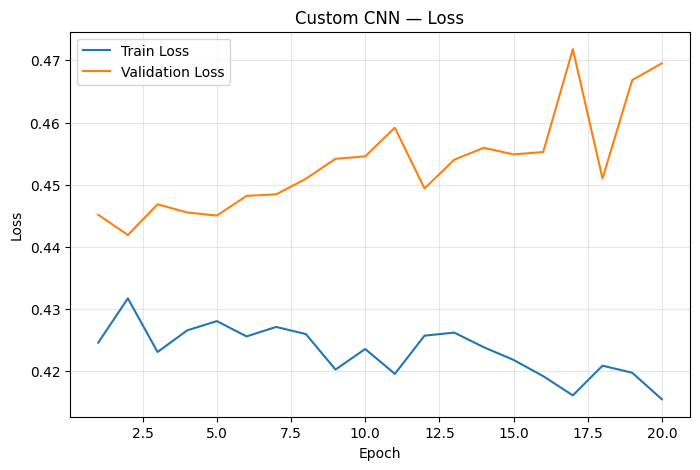

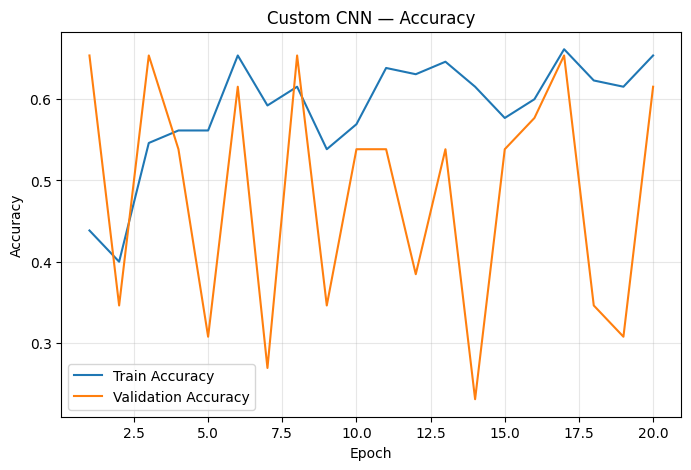

In [63]:
# ============================================================
# CELL 61: LEARNING CURVES
# ============================================================

import matplotlib.pyplot as plt

epochs = range(
    1,
    EPOCHS + 1
)

plt.figure(figsize=(8, 5))

plt.plot(
    epochs,
    history["train_loss"],
    label="Train Loss"
)

plt.plot(
    epochs,
    history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Custom CNN — Loss")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


plt.figure(figsize=(8, 5))

plt.plot(
    epochs,
    history["train_accuracy"],
    label="Train Accuracy"
)

plt.plot(
    epochs,
    history["val_accuracy"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Custom CNN — Accuracy")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [64]:
# ============================================================
# CELL 62: FINAL TEST — CUSTOM CNN
# ============================================================

(
    test_loss,
    test_accuracy,
    test_targets,
    test_probabilities
) = evaluate(
    model,
    test_loader,
    criterion,
    device
)

print("=" * 65)
print("CUSTOM CNN — TEST RESULTS")
print("=" * 65)

print(
    f"Test Loss:     {test_loss:.4f}"
)

print(
    f"Test Accuracy: "
    f"{test_accuracy * 100:.2f}%"
)

CUSTOM CNN — TEST RESULTS
Test Loss:     0.4333
Test Accuracy: 32.14%


In [65]:
# ============================================================
# CELL 63: CLASSIFICATION METRICS
# ============================================================

import numpy as np

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

y_true = np.array(
    test_targets
).astype(int)

y_prob = np.array(
    test_probabilities
)

y_pred = (
    y_prob >= 0.5
).astype(int)


accuracy = accuracy_score(
    y_true,
    y_pred
)

precision = precision_score(
    y_true,
    y_pred,
    zero_division=0
)

sensitivity = recall_score(
    y_true,
    y_pred,
    zero_division=0
)

f1 = f1_score(
    y_true,
    y_pred,
    zero_division=0
)

auc = roc_auc_score(
    y_true,
    y_prob
)

cm = confusion_matrix(
    y_true,
    y_pred
)

tn, fp, fn, tp = cm.ravel()

specificity = (
    tn / (tn + fp)
    if (tn + fp) > 0
    else 0
)


print("=" * 65)
print("CUSTOM CNN — PERFORMANCE")
print("=" * 65)

print(
    f"Accuracy:    {accuracy:.3f}"
)

print(
    f"Precision:   {precision:.3f}"
)

print(
    f"Sensitivity: {sensitivity:.3f}"
)

print(
    f"Specificity: {specificity:.3f}"
)

print(
    f"F1 Score:    {f1:.3f}"
)

print(
    f"ROC-AUC:     {auc:.3f}"
)

print("\nConfusion Matrix:")

print(cm)

print("\nClassification Report:")

print(
    classification_report(
        y_true,
        y_pred,
        target_names=[
            "Normal Strength",
            "Low Strength"
        ],
        zero_division=0
    )
)

CUSTOM CNN — PERFORMANCE
Accuracy:    0.321
Precision:   0.000
Sensitivity: 0.000
Specificity: 1.000
F1 Score:    0.000
ROC-AUC:     0.538

Confusion Matrix:
[[ 9  0]
 [19  0]]

Classification Report:
                 precision    recall  f1-score   support

Normal Strength       0.32      1.00      0.49         9
   Low Strength       0.00      0.00      0.00        19

       accuracy                           0.32        28
      macro avg       0.16      0.50      0.24        28
   weighted avg       0.10      0.32      0.16        28



In [66]:
# ============================================================
# CELL 64: CUSTOM CNN EXPERIMENT 2
# NO CLASS WEIGHTING
# ============================================================

model_v2 = SarcopeniaCNN().to(device)

criterion_v2 = nn.BCEWithLogitsLoss()

optimizer_v2 = torch.optim.AdamW(
    model_v2.parameters(),
    lr=5e-4,
    weight_decay=1e-4
)

print("Fresh model created.")
print("Loss: BCEWithLogitsLoss (unweighted)")
print("Learning rate: 0.0005")

Fresh model created.
Loss: BCEWithLogitsLoss (unweighted)
Learning rate: 0.0005


In [68]:
# ============================================================
# CELL 65: TRAIN CUSTOM CNN V2
# ============================================================

import copy

EPOCHS = 25
PATIENCE = 6

history_v2 = {
    "train_loss": [],
    "val_loss": [],
    "train_accuracy": [],
    "val_accuracy": []
}

best_val_loss = float("inf")
best_epoch = 0
best_model_weights = None
epochs_without_improvement = 0


for epoch in range(EPOCHS):

    train_loss, train_accuracy = train_one_epoch(
        model_v2,
        train_loader,
        criterion_v2,
        optimizer_v2,
        device
    )

    (
        val_loss,
        val_accuracy,
        _,
        _
    ) = evaluate(
        model_v2,
        val_loader,
        criterion_v2,
        device
    )

    history_v2["train_loss"].append(train_loss)
    history_v2["val_loss"].append(val_loss)
    history_v2["train_accuracy"].append(train_accuracy)
    history_v2["val_accuracy"].append(val_accuracy)

    marker = ""

    if val_loss < best_val_loss:

        best_val_loss = val_loss
        best_epoch = epoch + 1

        best_model_weights = copy.deepcopy(
            model_v2.state_dict()
        )

        epochs_without_improvement = 0
        marker = " ← BEST"

    else:

        epochs_without_improvement += 1

    print(
        f"Epoch {epoch + 1:02d}/{EPOCHS} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_accuracy:.3f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val Acc: {val_accuracy:.3f}"
        f"{marker}"
    )

    if epochs_without_improvement >= PATIENCE:

        print(
            f"\nEarly stopping at epoch {epoch + 1}."
        )

        break


model_v2.load_state_dict(
    best_model_weights
)

print("\nBest epoch:", best_epoch)
print(
    "Best validation loss:",
    round(best_val_loss, 4)
)

Epoch 01/25 | Train Loss: 0.6691 | Train Acc: 0.615 | Val Loss: 0.6614 | Val Acc: 0.654 ← BEST
Epoch 02/25 | Train Loss: 0.6169 | Train Acc: 0.700 | Val Loss: 0.6495 | Val Acc: 0.654 ← BEST
Epoch 03/25 | Train Loss: 0.6159 | Train Acc: 0.700 | Val Loss: 0.6494 | Val Acc: 0.654 ← BEST
Epoch 04/25 | Train Loss: 0.6159 | Train Acc: 0.700 | Val Loss: 0.6475 | Val Acc: 0.654 ← BEST
Epoch 05/25 | Train Loss: 0.6233 | Train Acc: 0.700 | Val Loss: 0.6495 | Val Acc: 0.654
Epoch 06/25 | Train Loss: 0.6162 | Train Acc: 0.700 | Val Loss: 0.6520 | Val Acc: 0.654
Epoch 07/25 | Train Loss: 0.6032 | Train Acc: 0.700 | Val Loss: 0.7612 | Val Acc: 0.654
Epoch 08/25 | Train Loss: 0.6027 | Train Acc: 0.700 | Val Loss: 0.6623 | Val Acc: 0.654
Epoch 09/25 | Train Loss: 0.6269 | Train Acc: 0.700 | Val Loss: 0.6489 | Val Acc: 0.654
Epoch 10/25 | Train Loss: 0.6124 | Train Acc: 0.700 | Val Loss: 0.6544 | Val Acc: 0.654

Early stopping at epoch 10.

Best epoch: 4
Best validation loss: 0.6475


In [69]:
# ============================================================
# CELL 66: TEST CUSTOM CNN V2
# ============================================================

(
    test_loss_v2,
    test_accuracy_v2,
    test_targets_v2,
    test_probabilities_v2
) = evaluate(
    model_v2,
    test_loader,
    criterion_v2,
    device
)

y_true_v2 = np.array(
    test_targets_v2
).astype(int)

y_prob_v2 = np.array(
    test_probabilities_v2
)

y_pred_v2 = (
    y_prob_v2 >= 0.5
).astype(int)

cm_v2 = confusion_matrix(
    y_true_v2,
    y_pred_v2
)

tn, fp, fn, tp = cm_v2.ravel()

accuracy_v2 = accuracy_score(
    y_true_v2,
    y_pred_v2
)

precision_v2 = precision_score(
    y_true_v2,
    y_pred_v2,
    zero_division=0
)

sensitivity_v2 = recall_score(
    y_true_v2,
    y_pred_v2,
    zero_division=0
)

specificity_v2 = (
    tn / (tn + fp)
    if (tn + fp) > 0
    else 0
)

f1_v2 = f1_score(
    y_true_v2,
    y_pred_v2,
    zero_division=0
)

auc_v2 = roc_auc_score(
    y_true_v2,
    y_prob_v2
)


print("=" * 65)
print("CUSTOM CNN V2 — TEST PERFORMANCE")
print("=" * 65)

print(f"Accuracy:    {accuracy_v2:.3f}")
print(f"Precision:   {precision_v2:.3f}")
print(f"Sensitivity: {sensitivity_v2:.3f}")
print(f"Specificity: {specificity_v2:.3f}")
print(f"F1 Score:    {f1_v2:.3f}")
print(f"ROC-AUC:     {auc_v2:.3f}")

print("\nConfusion Matrix:")
print(cm_v2)

print("\nProbability range:")
print(
    f"{y_prob_v2.min():.3f} → "
    f"{y_prob_v2.max():.3f}"
)

CUSTOM CNN V2 — TEST PERFORMANCE
Accuracy:    0.679
Precision:   0.679
Sensitivity: 1.000
Specificity: 0.000
F1 Score:    0.809
ROC-AUC:     0.550

Confusion Matrix:
[[ 0  9]
 [ 0 19]]

Probability range:
0.630 → 0.649


In [70]:
# ============================================================
# CELL 67: RESNET18 NORMALIZATION
# ============================================================

import torch
import torchvision.transforms.v2 as T


imagenet_normalize = T.Normalize(
    mean=[0.485, 0.456, 0.406],
    std=[0.229, 0.224, 0.225]
)

print("ImageNet normalization ready.")

ImageNet normalization ready.


In [71]:
# ============================================================
# CELL 68: TRAINING AUGMENTATION
# ============================================================

train_transform = T.Compose([

    T.RandomHorizontalFlip(
        p=0.5
    ),

    T.RandomRotation(
        degrees=5
    ),

    T.ColorJitter(
        brightness=0.10,
        contrast=0.10
    ),

    imagenet_normalize
])


eval_transform = T.Compose([

    imagenet_normalize

])

print("Train and evaluation transforms ready.")

Train and evaluation transforms ready.


In [72]:
# ============================================================
# CELL 69: RESNET DATASET
# ============================================================

class SarcopeniaResNetDataset(Dataset):

    def __init__(
        self,
        dataframe,
        transform=None,
        image_size=224
    ):

        self.dataframe = (
            dataframe
            .reset_index(drop=True)
            .copy()
        )

        self.transform = transform
        self.image_size = image_size


    def __len__(self):

        return len(self.dataframe)


    def __getitem__(
        self,
        index
    ):

        row = self.dataframe.iloc[index]

        image = load_ultrasound(
            row["image_path"],
            self.image_size
        )

        if self.transform is not None:

            image = self.transform(
                image
            )

        target = torch.tensor(
            row["low_muscle_strength"],
            dtype=torch.float32
        )

        return {
            "image": image,
            "target": target,
            "patient_id": row["patient_id"],
            "muscle": row["muscle"]
        }

In [73]:
# ============================================================
# CELL 70: RESNET DATALOADERS
# ============================================================

resnet_train_dataset = SarcopeniaResNetDataset(
    train_df,
    transform=train_transform
)

resnet_val_dataset = SarcopeniaResNetDataset(
    val_df,
    transform=eval_transform
)

resnet_test_dataset = SarcopeniaResNetDataset(
    test_df,
    transform=eval_transform
)


resnet_train_loader = DataLoader(
    resnet_train_dataset,
    batch_size=8,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

resnet_val_loader = DataLoader(
    resnet_val_dataset,
    batch_size=8,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

resnet_test_loader = DataLoader(
    resnet_test_dataset,
    batch_size=8,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)


batch = next(
    iter(resnet_train_loader)
)

print(
    "Images:",
    batch["image"].shape
)

print(
    "Targets:",
    batch["target"].shape
)

print(
    "Image range:",
    batch["image"].min().item(),
    "→",
    batch["image"].max().item()
)

Images: torch.Size([8, 3, 224, 224])
Targets: torch.Size([8])
Image range: -2.1179039478302 → 2.640000104904175


In [74]:
# ============================================================
# CELL 71: PRETRAINED RESNET18
# ============================================================

from torchvision.models import (
    resnet18,
    ResNet18_Weights
)


weights = ResNet18_Weights.DEFAULT

resnet_model = resnet18(
    weights=weights
)

print(resnet_model.fc)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 172MB/s]


Linear(in_features=512, out_features=1000, bias=True)


In [75]:
# ============================================================
# CELL 72: MODIFY RESNET18 CLASSIFIER
# ============================================================

num_features = (
    resnet_model.fc.in_features
)

print(
    "ResNet feature size:",
    num_features
)


resnet_model.fc = nn.Sequential(

    nn.Dropout(
        p=0.30
    ),

    nn.Linear(
        num_features,
        1
    )
)


resnet_model = resnet_model.to(
    device
)


print("\nNew classifier:")

print(
    resnet_model.fc
)

ResNet feature size: 512

New classifier:
Sequential(
  (0): Dropout(p=0.3, inplace=False)
  (1): Linear(in_features=512, out_features=1, bias=True)
)


In [76]:
# ============================================================
# CELL 73: RESNET PARAMETERS
# ============================================================

total_parameters = sum(
    p.numel()
    for p in resnet_model.parameters()
)

trainable_parameters = sum(
    p.numel()
    for p in resnet_model.parameters()
    if p.requires_grad
)


print(
    f"Total parameters: "
    f"{total_parameters:,}"
)

print(
    f"Trainable parameters: "
    f"{trainable_parameters:,}"
)

Total parameters: 11,177,025
Trainable parameters: 11,177,025


In [77]:
# ============================================================
# CELL 74: FREEZE RESNET BACKBONE
# ============================================================

for parameter in resnet_model.parameters():

    parameter.requires_grad = False


for parameter in resnet_model.fc.parameters():

    parameter.requires_grad = True


trainable_parameters = sum(
    p.numel()
    for p in resnet_model.parameters()
    if p.requires_grad
)


print(
    "Trainable parameters:",
    f"{trainable_parameters:,}"
)

Trainable parameters: 513


In [78]:
# ============================================================
# CELL 75: STAGE 1 SETUP
# ============================================================

resnet_criterion = nn.BCEWithLogitsLoss()


stage1_optimizer = torch.optim.AdamW(
    filter(
        lambda p: p.requires_grad,
        resnet_model.parameters()
    ),
    lr=1e-3,
    weight_decay=1e-4
)


print(
    "Stage 1 optimizer ready."
)

Stage 1 optimizer ready.


In [79]:
# ============================================================
# CELL 76: STAGE 1 — TRAIN CLASSIFIER
# ============================================================

import copy


STAGE1_EPOCHS = 5

stage1_best_loss = float("inf")
stage1_best_weights = None


for epoch in range(
    STAGE1_EPOCHS
):

    train_loss, train_acc = train_one_epoch(
        resnet_model,
        resnet_train_loader,
        resnet_criterion,
        stage1_optimizer,
        device
    )

    (
        val_loss,
        val_acc,
        _,
        _
    ) = evaluate(
        resnet_model,
        resnet_val_loader,
        resnet_criterion,
        device
    )


    if val_loss < stage1_best_loss:

        stage1_best_loss = val_loss

        stage1_best_weights = copy.deepcopy(
            resnet_model.state_dict()
        )

        marker = " ← BEST"

    else:

        marker = ""


    print(
        f"Epoch {epoch+1:02d}/"
        f"{STAGE1_EPOCHS} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_acc:.3f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val Acc: {val_acc:.3f}"
        f"{marker}"
    )


resnet_model.load_state_dict(
    stage1_best_weights
)

Epoch 01/5 | Train Loss: 0.6837 | Train Acc: 0.662 | Val Loss: 0.7006 | Val Acc: 0.654 ← BEST
Epoch 02/5 | Train Loss: 0.6506 | Train Acc: 0.692 | Val Loss: 0.6620 | Val Acc: 0.654 ← BEST
Epoch 03/5 | Train Loss: 0.6341 | Train Acc: 0.700 | Val Loss: 0.6635 | Val Acc: 0.615
Epoch 04/5 | Train Loss: 0.6656 | Train Acc: 0.669 | Val Loss: 0.6715 | Val Acc: 0.615
Epoch 05/5 | Train Loss: 0.6884 | Train Acc: 0.600 | Val Loss: 0.6811 | Val Acc: 0.654


<All keys matched successfully>

In [80]:
# ============================================================
# CELL 77: UNFREEZE RESNET LAYER 4
# ============================================================

for parameter in resnet_model.layer4.parameters():

    parameter.requires_grad = True


for parameter in resnet_model.fc.parameters():

    parameter.requires_grad = True


trainable_parameters = sum(
    p.numel()
    for p in resnet_model.parameters()
    if p.requires_grad
)


print(
    "Trainable parameters:",
    f"{trainable_parameters:,}"
)

Trainable parameters: 8,394,241


In [81]:
# ============================================================
# CELL 78: FINE-TUNING OPTIMIZER
# ============================================================

stage2_optimizer = torch.optim.AdamW(
    filter(
        lambda p: p.requires_grad,
        resnet_model.parameters()
    ),
    lr=1e-4,
    weight_decay=1e-4
)

print(
    "Fine-tuning optimizer ready."
)

Fine-tuning optimizer ready.


In [82]:
# ============================================================
# CELL 79: STAGE 2 — FINE-TUNE RESNET18
# ============================================================

STAGE2_EPOCHS = 15
PATIENCE = 5

resnet_history = {
    "train_loss": [],
    "val_loss": [],
    "train_accuracy": [],
    "val_accuracy": []
}


best_val_loss = float("inf")
best_epoch = 0
best_resnet_weights = None

epochs_without_improvement = 0


for epoch in range(
    STAGE2_EPOCHS
):

    train_loss, train_acc = train_one_epoch(
        resnet_model,
        resnet_train_loader,
        resnet_criterion,
        stage2_optimizer,
        device
    )


    (
        val_loss,
        val_acc,
        _,
        _
    ) = evaluate(
        resnet_model,
        resnet_val_loader,
        resnet_criterion,
        device
    )


    resnet_history[
        "train_loss"
    ].append(train_loss)

    resnet_history[
        "val_loss"
    ].append(val_loss)

    resnet_history[
        "train_accuracy"
    ].append(train_acc)

    resnet_history[
        "val_accuracy"
    ].append(val_acc)


    marker = ""


    if val_loss < best_val_loss:

        best_val_loss = val_loss

        best_epoch = epoch + 1

        best_resnet_weights = copy.deepcopy(
            resnet_model.state_dict()
        )

        epochs_without_improvement = 0

        marker = " ← BEST"

    else:

        epochs_without_improvement += 1


    print(
        f"Epoch {epoch+1:02d}/"
        f"{STAGE2_EPOCHS} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_acc:.3f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val Acc: {val_acc:.3f}"
        f"{marker}"
    )


    if epochs_without_improvement >= PATIENCE:

        print(
            "\nEarly stopping."
        )

        break


resnet_model.load_state_dict(
    best_resnet_weights
)


print("\nBest fine-tuning epoch:", best_epoch)

print(
    "Best validation loss:",
    round(best_val_loss, 4)
)

Epoch 01/15 | Train Loss: 0.6497 | Train Acc: 0.662 | Val Loss: 0.6112 | Val Acc: 0.654 ← BEST
Epoch 02/15 | Train Loss: 0.6422 | Train Acc: 0.669 | Val Loss: 0.5823 | Val Acc: 0.731 ← BEST
Epoch 03/15 | Train Loss: 0.5219 | Train Acc: 0.746 | Val Loss: 0.6001 | Val Acc: 0.731
Epoch 04/15 | Train Loss: 0.4492 | Train Acc: 0.777 | Val Loss: 0.6281 | Val Acc: 0.692
Epoch 05/15 | Train Loss: 0.4532 | Train Acc: 0.777 | Val Loss: 0.6136 | Val Acc: 0.654
Epoch 06/15 | Train Loss: 0.3664 | Train Acc: 0.877 | Val Loss: 0.6396 | Val Acc: 0.654
Epoch 07/15 | Train Loss: 0.3143 | Train Acc: 0.892 | Val Loss: 0.7839 | Val Acc: 0.538

Early stopping.

Best fine-tuning epoch: 2
Best validation loss: 0.5823


In [83]:
# ============================================================
# CELL 80: VALIDATION DIAGNOSTICS
# ============================================================

(
    val_loss,
    val_accuracy,
    val_targets,
    val_probabilities
) = evaluate(
    resnet_model,
    resnet_val_loader,
    resnet_criterion,
    device
)


val_targets = np.array(
    val_targets
).astype(int)

val_probabilities = np.array(
    val_probabilities
)


val_predictions = (
    val_probabilities >= 0.5
).astype(int)


print("=" * 65)
print("RESNET18 — VALIDATION DIAGNOSTICS")
print("=" * 65)

print(
    "Probability range:",
    f"{val_probabilities.min():.3f}",
    "→",
    f"{val_probabilities.max():.3f}"
)

print(
    "Predicted classes:",
    np.unique(
        val_predictions,
        return_counts=True
    )
)

print(
    "ROC-AUC:",
    round(
        roc_auc_score(
            val_targets,
            val_probabilities
        ),
        3
    )
)

print("\nConfusion Matrix:")

print(
    confusion_matrix(
        val_targets,
        val_predictions
    )
)

RESNET18 — VALIDATION DIAGNOSTICS
Probability range: 0.356 → 0.924
Predicted classes: (array([0, 1]), array([ 4, 22]))
ROC-AUC: 0.647

Confusion Matrix:
[[ 3  6]
 [ 1 16]]


In [84]:
# ============================================================
# CELL 81: FINAL RESNET18 TEST EVALUATION
# ============================================================

(
    test_loss,
    test_accuracy,
    test_targets,
    test_probabilities
) = evaluate(
    resnet_model,
    resnet_test_loader,
    resnet_criterion,
    device
)

y_true = np.array(
    test_targets
).astype(int)

y_prob = np.array(
    test_probabilities
)

y_pred = (
    y_prob >= 0.5
).astype(int)

cm = confusion_matrix(
    y_true,
    y_pred
)

tn, fp, fn, tp = cm.ravel()

accuracy = accuracy_score(
    y_true,
    y_pred
)

precision = precision_score(
    y_true,
    y_pred,
    zero_division=0
)

sensitivity = recall_score(
    y_true,
    y_pred,
    zero_division=0
)

specificity = (
    tn / (tn + fp)
    if (tn + fp) > 0
    else 0
)

f1 = f1_score(
    y_true,
    y_pred,
    zero_division=0
)

auc = roc_auc_score(
    y_true,
    y_prob
)


print("=" * 65)
print("RESNET18 — IMAGE-LEVEL TEST PERFORMANCE")
print("=" * 65)

print(f"Accuracy:    {accuracy:.3f}")
print(f"Precision:   {precision:.3f}")
print(f"Sensitivity: {sensitivity:.3f}")
print(f"Specificity: {specificity:.3f}")
print(f"F1 Score:    {f1:.3f}")
print(f"ROC-AUC:     {auc:.3f}")

print("\nConfusion Matrix:")
print(cm)

print(
    "\nProbability range:",
    f"{y_prob.min():.3f}",
    "→",
    f"{y_prob.max():.3f}"
)

RESNET18 — IMAGE-LEVEL TEST PERFORMANCE
Accuracy:    0.679
Precision:   0.692
Sensitivity: 0.947
Specificity: 0.111
F1 Score:    0.800
ROC-AUC:     0.503

Confusion Matrix:
[[ 1  8]
 [ 1 18]]

Probability range: 0.381 → 0.905


In [85]:
# ============================================================
# CELL 82: COLLECT PATIENT-LEVEL PREDICTIONS
# ============================================================

import pandas as pd

resnet_model.eval()

records = []

with torch.no_grad():

    for batch in resnet_test_loader:

        images = batch["image"].to(
            device,
            non_blocking=True
        )

        logits = resnet_model(
            images
        ).squeeze(1)

        probabilities = torch.sigmoid(
            logits
        ).cpu().numpy()

        targets = (
            batch["target"]
            .cpu()
            .numpy()
            .astype(int)
        )

        for patient_id, muscle, target, probability in zip(
            batch["patient_id"],
            batch["muscle"],
            targets,
            probabilities
        ):

            records.append({
                "patient_id": patient_id,
                "muscle": muscle,
                "target": target,
                "probability": float(probability)
            })


prediction_df = pd.DataFrame(
    records
)

display(
    prediction_df.head(10)
)

print(
    "\nImages:",
    len(prediction_df)
)

print(
    "Patients:",
    prediction_df[
        "patient_id"
    ].nunique()
)

,patient_id,muscle,target,probability
0,CS102,VL,1,0.650759
1,CS102,TA,1,0.878253
2,CS102,TA,1,0.614406
3,CS102,RF,1,0.715025
4,CS102,RF,1,0.904725
5,DJ101,VL,0,0.439008
6,DJ101,VL,0,0.749056
7,DJ101,TA,0,0.797481
8,DJ101,RF,0,0.673047
9,PL158,VL,0,0.554933



Images: 28
Patients: 9


In [87]:
# ============================================================
# CELL 83: PATIENT-LEVEL AGGREGATION
# ============================================================

patient_predictions = (
    prediction_df
    .groupby("patient_id")
    .agg(
        target=("target", "first"),
        probability=("probability", "mean"),
        number_of_images=("probability", "size")
    )
    .reset_index()
)

patient_predictions[
    "prediction"
] = (
    patient_predictions[
        "probability"
    ] >= 0.5
).astype(int)


display(
    patient_predictions
)

,patient_id,target,probability,number_of_images,prediction
0,BA122,1,0.609808,2,1
1,BM103,1,0.565469,3,1
2,CS102,1,0.752634,5,1
3,CY164,1,0.631023,3,1
4,DJ101,0,0.664648,4,1
5,GD171,1,0.733496,3,1
6,PL158,0,0.678470,2,1
7,RF148,0,0.705059,3,1
8,SC146,1,0.731978,3,1


In [88]:
# ============================================================
# CELL 84: PATIENT-LEVEL RESNET18 PERFORMANCE
# ============================================================

patient_y_true = (
    patient_predictions[
        "target"
    ].to_numpy()
)

patient_y_prob = (
    patient_predictions[
        "probability"
    ].to_numpy()
)

patient_y_pred = (
    patient_predictions[
        "prediction"
    ].to_numpy()
)


patient_cm = confusion_matrix(
    patient_y_true,
    patient_y_pred
)

tn, fp, fn, tp = patient_cm.ravel()


patient_accuracy = accuracy_score(
    patient_y_true,
    patient_y_pred
)

patient_precision = precision_score(
    patient_y_true,
    patient_y_pred,
    zero_division=0
)

patient_sensitivity = recall_score(
    patient_y_true,
    patient_y_pred,
    zero_division=0
)

patient_specificity = (
    tn / (tn + fp)
    if (tn + fp) > 0
    else 0
)

patient_f1 = f1_score(
    patient_y_true,
    patient_y_pred,
    zero_division=0
)

patient_auc = roc_auc_score(
    patient_y_true,
    patient_y_prob
)


print("=" * 65)
print("RESNET18 — PATIENT-LEVEL TEST PERFORMANCE")
print("=" * 65)

print(
    "Patients:",
    len(patient_predictions)
)

print(
    f"Accuracy:    {patient_accuracy:.3f}"
)

print(
    f"Precision:   {patient_precision:.3f}"
)

print(
    f"Sensitivity: {patient_sensitivity:.3f}"
)

print(
    f"Specificity: {patient_specificity:.3f}"
)

print(
    f"F1 Score:    {patient_f1:.3f}"
)

print(
    f"ROC-AUC:     {patient_auc:.3f}"
)

print("\nConfusion Matrix:")

print(patient_cm)

RESNET18 — PATIENT-LEVEL TEST PERFORMANCE
Patients: 9
Accuracy:    0.667
Precision:   0.667
Sensitivity: 1.000
Specificity: 0.000
F1 Score:    0.800
ROC-AUC:     0.500

Confusion Matrix:
[[0 3]
 [0 6]]


In [89]:
# ============================================================
# CELL 85: SAVE RESNET18 BASELINE
# ============================================================

RESNET_PATH = "/content/sarcopenia_resnet18_best.pth"

torch.save(
    {
        "model_state_dict": resnet_model.state_dict(),
        "architecture": "ResNet18",
        "target": "low_muscle_strength",
        "image_size": 224,
        "validation_auc": 0.647,
        "test_patient_auc": 0.500,
        "test_patient_accuracy": 0.667
    },
    RESNET_PATH
)

print("Saved:", RESNET_PATH)

Saved: /content/sarcopenia_resnet18_best.pth


In [90]:
# ============================================================
# CELL 86: SELECT CLINICAL FEATURES
# ============================================================

CLINICAL_FEATURES = [
    "Age",
    "Taille",
    "Poids",
    "Sexe"
]

TARGET = "low_muscle_strength"

print("=" * 65)
print("CLINICAL FEATURES")
print("=" * 65)

for feature in CLINICAL_FEATURES:

    print(
        f"{feature:10s} | "
        f"Missing: "
        f"{clinical_df[feature].isna().sum()}"
    )

print("\nTarget:")
print(TARGET)

CLINICAL FEATURES
Age        | Missing: 0
Taille     | Missing: 0
Poids      | Missing: 0
Sexe       | Missing: 0

Target:
low_muscle_strength


In [91]:
# ============================================================
# CELL 87: CREATE CLINICAL PATIENT SPLITS
# ============================================================

clinical_model_df = clinical_df[
    [
        "ID_patient",
        *CLINICAL_FEATURES,
        TARGET
    ]
].copy()

clinical_model_df = clinical_model_df.rename(
    columns={
        "ID_patient": "patient_id"
    }
)


clinical_train_df = clinical_model_df[
    clinical_model_df["patient_id"].isin(
        train_patients["patient_id"]
    )
].reset_index(drop=True)


clinical_val_df = clinical_model_df[
    clinical_model_df["patient_id"].isin(
        val_patients["patient_id"]
    )
].reset_index(drop=True)


clinical_test_df = clinical_model_df[
    clinical_model_df["patient_id"].isin(
        test_patients["patient_id"]
    )
].reset_index(drop=True)


print("=" * 65)
print("CLINICAL SPLITS")
print("=" * 65)

print(
    "Train:",
    len(clinical_train_df)
)

print(
    "Validation:",
    len(clinical_val_df)
)

print(
    "Test:",
    len(clinical_test_df)
)


print("\nTrain target:")
print(
    clinical_train_df[TARGET]
    .value_counts()
)

print("\nValidation target:")
print(
    clinical_val_df[TARGET]
    .value_counts()
)

print("\nTest target:")
print(
    clinical_test_df[TARGET]
    .value_counts()
)

CLINICAL SPLITS
Train: 42
Validation: 9
Test: 9

Train target:
low_muscle_strength
1    29
0    13
Name: count, dtype: int64

Validation target:
low_muscle_strength
1    6
0    3
Name: count, dtype: int64

Test target:
low_muscle_strength
1    6
0    3
Name: count, dtype: int64


In [92]:
# ============================================================
# CELL 88: STANDARDIZE CLINICAL FEATURES
# ============================================================

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(
    clinical_train_df[
        CLINICAL_FEATURES
    ]
)

X_val = scaler.transform(
    clinical_val_df[
        CLINICAL_FEATURES
    ]
)

X_test = scaler.transform(
    clinical_test_df[
        CLINICAL_FEATURES
    ]
)


y_train = clinical_train_df[
    TARGET
].to_numpy()

y_val = clinical_val_df[
    TARGET
].to_numpy()

y_test = clinical_test_df[
    TARGET
].to_numpy()


print("X_train:", X_train.shape)
print("X_val:  ", X_val.shape)
print("X_test: ", X_test.shape)

print("\nTraining feature means after scaling:")

print(
    X_train.mean(axis=0)
)

print("\nTraining feature std:")

print(
    X_train.std(axis=0)
)

X_train: (42, 4)
X_val:   (9, 4)
X_test:  (9, 4)

Training feature means after scaling:
[ 5.07530526e-16  1.79750394e-16  1.17895112e-15 -3.17206578e-17]

Training feature std:
[1. 1. 1. 1.]


In [93]:
# ============================================================
# CELL 89: NUMPY → PYTORCH
# ============================================================

from torch.utils.data import TensorDataset


X_train_tensor = torch.tensor(
    X_train,
    dtype=torch.float32
)

X_val_tensor = torch.tensor(
    X_val,
    dtype=torch.float32
)

X_test_tensor = torch.tensor(
    X_test,
    dtype=torch.float32
)


y_train_tensor = torch.tensor(
    y_train,
    dtype=torch.float32
)

y_val_tensor = torch.tensor(
    y_val,
    dtype=torch.float32
)

y_test_tensor = torch.tensor(
    y_test,
    dtype=torch.float32
)


clinical_train_dataset = TensorDataset(
    X_train_tensor,
    y_train_tensor
)

clinical_val_dataset = TensorDataset(
    X_val_tensor,
    y_val_tensor
)

clinical_test_dataset = TensorDataset(
    X_test_tensor,
    y_test_tensor
)


clinical_train_loader = DataLoader(
    clinical_train_dataset,
    batch_size=8,
    shuffle=True
)

clinical_val_loader = DataLoader(
    clinical_val_dataset,
    batch_size=8,
    shuffle=False
)

clinical_test_loader = DataLoader(
    clinical_test_dataset,
    batch_size=8,
    shuffle=False
)


features, targets = next(
    iter(clinical_train_loader)
)

print(
    "Clinical batch:",
    features.shape
)

print(
    "Target batch:",
    targets.shape
)

print("\nFirst patient:")
print(features[0])

print(
    "\nTarget:",
    targets[0]
)

Clinical batch: torch.Size([8, 4])
Target batch: torch.Size([8])

First patient:
tensor([ 1.0699,  0.3709, -1.1836,  1.3416])

Target: tensor(1.)


In [95]:
# ============================================================
# CELL 90: CLINICAL MLP
# ============================================================

class ClinicalMLP(nn.Module):

    def __init__(
        self,
        input_features=4
    ):

        super().__init__()

        # Clinical feature encoder
        self.encoder = nn.Sequential(

            nn.Linear(
                input_features,
                16
            ),

            nn.ReLU(),

            nn.Dropout(0.20),

            nn.Linear(
                16,
                8
            ),

            nn.ReLU()
        )

        # Binary classifier
        self.classifier = nn.Linear(
            8,
            1
        )


    def forward(self, x):

        features = self.encoder(x)

        logits = self.classifier(
            features
        )

        return logits

In [96]:
# ============================================================
# CELL 91: CLINICAL MLP FORWARD PASS
# ============================================================

clinical_model = ClinicalMLP(
    input_features=len(
        CLINICAL_FEATURES
    )
).to(device)


features = features.to(device)

logits = clinical_model(
    features
)


print(
    "Input:",
    features.shape
)

print(
    "Output:",
    logits.shape
)


print(
    "\nParameters:",
    sum(
        p.numel()
        for p in clinical_model.parameters()
    )
)

Input: torch.Size([8, 4])
Output: torch.Size([8, 1])

Parameters: 225


In [97]:
# ============================================================
# CELL 92: CLINICAL TRAINING FUNCTIONS
# ============================================================

def train_clinical_epoch(
    model,
    loader,
    criterion,
    optimizer,
    device
):

    model.train()

    total_loss = 0
    correct = 0
    total = 0


    for features, targets in loader:

        features = features.to(device)
        targets = targets.to(device)

        optimizer.zero_grad()

        logits = model(
            features
        ).squeeze(1)

        loss = criterion(
            logits,
            targets
        )

        loss.backward()

        optimizer.step()


        total_loss += (
            loss.item()
            * features.size(0)
        )


        probabilities = torch.sigmoid(
            logits
        )

        predictions = (
            probabilities >= 0.5
        ).float()


        correct += (
            predictions == targets
        ).sum().item()

        total += targets.size(0)


    return (
        total_loss / total,
        correct / total
    )


def evaluate_clinical(
    model,
    loader,
    criterion,
    device
):

    model.eval()

    total_loss = 0

    targets_all = []
    probabilities_all = []


    with torch.no_grad():

        for features, targets in loader:

            features = features.to(device)
            targets = targets.to(device)

            logits = model(
                features
            ).squeeze(1)

            loss = criterion(
                logits,
                targets
            )

            probabilities = torch.sigmoid(
                logits
            )


            total_loss += (
                loss.item()
                * features.size(0)
            )


            targets_all.extend(
                targets.cpu().numpy()
            )

            probabilities_all.extend(
                probabilities.cpu().numpy()
            )


    return (
        total_loss / len(loader.dataset),
        np.array(targets_all),
        np.array(probabilities_all)
    )

In [98]:
# ============================================================
# CELL 93: TRAIN CLINICAL MLP
# ============================================================

import copy

clinical_model = ClinicalMLP(
    input_features=len(
        CLINICAL_FEATURES
    )
).to(device)


clinical_criterion = (
    nn.BCEWithLogitsLoss()
)


clinical_optimizer = torch.optim.AdamW(
    clinical_model.parameters(),
    lr=1e-3,
    weight_decay=1e-3
)


EPOCHS = 100
PATIENCE = 15

best_val_loss = float("inf")
best_clinical_weights = None
best_epoch = 0

epochs_without_improvement = 0


for epoch in range(EPOCHS):

    train_loss, train_accuracy = (
        train_clinical_epoch(
            clinical_model,
            clinical_train_loader,
            clinical_criterion,
            clinical_optimizer,
            device
        )
    )


    (
        val_loss,
        val_targets,
        val_probabilities
    ) = evaluate_clinical(
        clinical_model,
        clinical_val_loader,
        clinical_criterion,
        device
    )


    val_predictions = (
        val_probabilities >= 0.5
    ).astype(int)


    val_accuracy = accuracy_score(
        val_targets,
        val_predictions
    )


    marker = ""


    if val_loss < best_val_loss:

        best_val_loss = val_loss

        best_epoch = epoch + 1

        best_clinical_weights = (
            copy.deepcopy(
                clinical_model.state_dict()
            )
        )

        epochs_without_improvement = 0

        marker = " ← BEST"

    else:

        epochs_without_improvement += 1


    if (
        epoch == 0
        or (epoch + 1) % 5 == 0
        or marker
    ):

        print(
            f"Epoch {epoch+1:03d} | "
            f"Train Loss: {train_loss:.4f} | "
            f"Train Acc: {train_accuracy:.3f} | "
            f"Val Loss: {val_loss:.4f} | "
            f"Val Acc: {val_accuracy:.3f}"
            f"{marker}"
        )


    if epochs_without_improvement >= PATIENCE:

        print(
            f"\nEarly stopping at "
            f"epoch {epoch+1}"
        )

        break


clinical_model.load_state_dict(
    best_clinical_weights
)


print("\nBest epoch:", best_epoch)

print(
    "Best validation loss:",
    round(best_val_loss, 4)
)

Epoch 001 | Train Loss: 0.7151 | Train Acc: 0.310 | Val Loss: 0.7089 | Val Acc: 0.333 ← BEST
Epoch 002 | Train Loss: 0.7099 | Train Acc: 0.357 | Val Loss: 0.7064 | Val Acc: 0.222 ← BEST
Epoch 003 | Train Loss: 0.7040 | Train Acc: 0.381 | Val Loss: 0.7038 | Val Acc: 0.222 ← BEST
Epoch 004 | Train Loss: 0.6990 | Train Acc: 0.452 | Val Loss: 0.7011 | Val Acc: 0.222 ← BEST
Epoch 005 | Train Loss: 0.6955 | Train Acc: 0.476 | Val Loss: 0.6985 | Val Acc: 0.333 ← BEST
Epoch 006 | Train Loss: 0.7007 | Train Acc: 0.333 | Val Loss: 0.6961 | Val Acc: 0.222 ← BEST
Epoch 007 | Train Loss: 0.6963 | Train Acc: 0.476 | Val Loss: 0.6938 | Val Acc: 0.667 ← BEST
Epoch 008 | Train Loss: 0.6864 | Train Acc: 0.619 | Val Loss: 0.6917 | Val Acc: 0.667 ← BEST
Epoch 009 | Train Loss: 0.6846 | Train Acc: 0.619 | Val Loss: 0.6893 | Val Acc: 0.556 ← BEST
Epoch 010 | Train Loss: 0.6811 | Train Acc: 0.690 | Val Loss: 0.6870 | Val Acc: 0.667 ← BEST
Epoch 011 | Train Loss: 0.6745 | Train Acc: 0.667 | Val Loss: 0.6841 |

In [99]:
# ============================================================
# CELL 94: CLINICAL VALIDATION DIAGNOSTICS
# ============================================================

(
    val_loss,
    clinical_val_targets,
    clinical_val_probabilities
) = evaluate_clinical(
    clinical_model,
    clinical_val_loader,
    clinical_criterion,
    device
)


clinical_val_predictions = (
    clinical_val_probabilities >= 0.5
).astype(int)


clinical_val_auc = roc_auc_score(
    clinical_val_targets,
    clinical_val_probabilities
)


print("=" * 65)
print("CLINICAL MLP — VALIDATION")
print("=" * 65)

print(
    "Probability range:",
    f"{clinical_val_probabilities.min():.3f}",
    "→",
    f"{clinical_val_probabilities.max():.3f}"
)

print(
    "Predicted classes:",
    np.unique(
        clinical_val_predictions,
        return_counts=True
    )
)

print(
    "Accuracy:",
    round(
        accuracy_score(
            clinical_val_targets,
            clinical_val_predictions
        ),
        3
    )
)

print(
    "ROC-AUC:",
    round(
        clinical_val_auc,
        3
    )
)

print("\nConfusion Matrix:")

print(
    confusion_matrix(
        clinical_val_targets,
        clinical_val_predictions
    )
)

CLINICAL MLP — VALIDATION
Probability range: 0.545 → 0.899
Predicted classes: (array([1]), array([9]))
Accuracy: 0.667
ROC-AUC: 0.611

Confusion Matrix:
[[0 3]
 [0 6]]


In [101]:
# ============================================================
# CELL 96 — CORRECTED
# PATIENT-CENTRIC MULTIMODAL DATASET
# RF + VL + TA ULTRASOUND + CLINICAL FEATURES
# ============================================================

import numpy as np
import pandas as pd
import torch
from torch.utils.data import Dataset, DataLoader

print("=" * 70)
print("BUILDING PATIENT-CENTRIC MULTIMODAL DATASET")
print("=" * 70)


# ============================================================
# 1. AUTOMATICALLY DETECT IMAGE PATH COLUMN
# ============================================================

if "image_path" in dataset_df.columns:
    IMAGE_PATH_COLUMN = "image_path"

elif "file_path" in dataset_df.columns:
    IMAGE_PATH_COLUMN = "file_path"

else:
    raise ValueError(
        "Could not find image_path or file_path in dataset_df."
    )

print("\nUsing image path column:", IMAGE_PATH_COLUMN)


# ============================================================
# 2. SAFETY CHECK
# ============================================================

required_columns = [
    "patient_id",
    "muscle",
    IMAGE_PATH_COLUMN,
    "low_muscle_strength"
]

missing_columns = [
    col
    for col in required_columns
    if col not in dataset_df.columns
]

if missing_columns:
    raise ValueError(
        f"Missing columns: {missing_columns}"
    )


# ============================================================
# 3. CREATE CLINICAL LOOKUP
# ============================================================

clinical_lookup = (
    clinical_model_df[
        [
            "patient_id",
            *CLINICAL_FEATURES,
            TARGET
        ]
    ]
    .drop_duplicates("patient_id")
    .set_index("patient_id")
)


# ============================================================
# 4. BUILD ONE RECORD PER PATIENT
# ============================================================

patient_records = []

for patient_id, group in dataset_df.groupby("patient_id"):

    if patient_id not in clinical_lookup.index:
        continue

    record = {
        "patient_id": patient_id,
        "target": int(
            group[TARGET].iloc[0]
        )
    }

    # --------------------------------------------
    # Store all acquisitions for RF / VL / TA
    # --------------------------------------------

    for muscle in ["RF", "VL", "TA"]:

        paths = (
            group.loc[
                group["muscle"] == muscle,
                IMAGE_PATH_COLUMN
            ]
            .dropna()
            .tolist()
        )

        record[f"{muscle}_paths"] = paths


    # --------------------------------------------
    # Clinical information
    # --------------------------------------------

    clinical_row = clinical_lookup.loc[
        patient_id
    ]

    for feature in CLINICAL_FEATURES:

        record[feature] = float(
            clinical_row[feature]
        )

    patient_records.append(record)


multimodal_df = pd.DataFrame(
    patient_records
)


# ============================================================
# 5. CHECK MUSCLE AVAILABILITY
# ============================================================

for muscle in ["RF", "VL", "TA"]:

    multimodal_df[
        f"has_{muscle}"
    ] = multimodal_df[
        f"{muscle}_paths"
    ].apply(
        lambda x: len(x) > 0
    )


multimodal_df[
    "has_all_muscles"
] = (

    multimodal_df["has_RF"]

    & multimodal_df["has_VL"]

    & multimodal_df["has_TA"]
)


print("\nTotal patients found:")
print(len(multimodal_df))


print("\nMuscle availability:")

for muscle in ["RF", "VL", "TA"]:

    print(
        f"{muscle}:",
        int(
            multimodal_df[
                f"has_{muscle}"
            ].sum()
        )
    )


print(
    "\nPatients with all RF + VL + TA:",
    int(
        multimodal_df[
            "has_all_muscles"
        ].sum()
    )
)


# ============================================================
# 6. KEEP COMPLETE MULTI-MUSCLE PATIENTS
# ============================================================

complete_multimodal_df = (

    multimodal_df[
        multimodal_df[
            "has_all_muscles"
        ]
    ]

    .copy()

    .reset_index(
        drop=True
    )
)


if len(complete_multimodal_df) == 0:

    raise ValueError(
        "No patients contain all RF + VL + TA images."
    )


# ============================================================
# 7. GET ORIGINAL PATIENT SPLITS
# ============================================================

train_patient_ids = set(
    train_patients[
        "patient_id"
    ].tolist()
)

val_patient_ids = set(
    val_patients[
        "patient_id"
    ].tolist()
)

test_patient_ids = set(
    test_patients[
        "patient_id"
    ].tolist()
)


# ============================================================
# 8. CREATE MULTIMODAL SPLITS
# ============================================================

multimodal_train_df = (

    complete_multimodal_df[

        complete_multimodal_df[
            "patient_id"
        ].isin(
            train_patient_ids
        )

    ]

    .reset_index(
        drop=True
    )
)


multimodal_val_df = (

    complete_multimodal_df[

        complete_multimodal_df[
            "patient_id"
        ].isin(
            val_patient_ids
        )

    ]

    .reset_index(
        drop=True
    )
)


multimodal_test_df = (

    complete_multimodal_df[

        complete_multimodal_df[
            "patient_id"
        ].isin(
            test_patient_ids
        )

    ]

    .reset_index(
        drop=True
    )
)


# ============================================================
# 9. VERIFY ZERO PATIENT LEAKAGE
# ============================================================

train_ids = set(
    multimodal_train_df[
        "patient_id"
    ]
)

val_ids = set(
    multimodal_val_df[
        "patient_id"
    ]
)

test_ids = set(
    multimodal_test_df[
        "patient_id"
    ]
)


assert train_ids.isdisjoint(
    val_ids
)

assert train_ids.isdisjoint(
    test_ids
)

assert val_ids.isdisjoint(
    test_ids
)


print("\n✓ No patient leakage detected.")


# ============================================================
# 10. MULTIMODAL PYTORCH DATASET
# ============================================================

class MultimodalSarcopeniaDataset(Dataset):

    def __init__(
        self,
        dataframe,
        clinical_features,
        scaler,
        transform=None
    ):

        self.df = (
            dataframe
            .reset_index(
                drop=True
            )
        )

        self.clinical_features = (
            clinical_features
        )

        self.scaler = scaler

        self.transform = transform


    def __len__(self):

        return len(
            self.df
        )


    # --------------------------------------------------------
    # Load one or more acquisitions for a muscle
    # --------------------------------------------------------

    def load_muscle(
        self,
        paths
    ):

        images = []

        for path in paths:

            image = load_ultrasound(
                path
            )

            if self.transform is not None:

                image = self.transform(
                    image
                )

            images.append(
                image
            )


        images = torch.stack(
            images,
            dim=0
        )


        # Average repeated acquisitions
        image = images.mean(
            dim=0
        )

        return image


    def __getitem__(
        self,
        index
    ):

        row = self.df.iloc[
            index
        ]


        # ----------------------------------------------------
        # ULTRASOUND MODALITY
        # ----------------------------------------------------

        rf_image = self.load_muscle(
            row["RF_paths"]
        )

        vl_image = self.load_muscle(
            row["VL_paths"]
        )

        ta_image = self.load_muscle(
            row["TA_paths"]
        )


        # ----------------------------------------------------
        # CLINICAL MODALITY
        # ----------------------------------------------------

        clinical_values = np.array(
            [
                float(
                    row[feature]
                )

                for feature
                in self.clinical_features
            ],
            dtype=np.float32
        ).reshape(
            1,
            -1
        )


        # IMPORTANT:
        # scaler was fitted on TRAINING patients only
        clinical_scaled = (
            self.scaler
            .transform(
                clinical_values
            )[0]
        )


        clinical_tensor = torch.tensor(
            clinical_scaled,
            dtype=torch.float32
        )


        # ----------------------------------------------------
        # TARGET
        # ----------------------------------------------------

        target = torch.tensor(
            float(
                row["target"]
            ),
            dtype=torch.float32
        )


        return {

            "rf_image":
                rf_image,

            "vl_image":
                vl_image,

            "ta_image":
                ta_image,

            "clinical":
                clinical_tensor,

            "target":
                target,

            "patient_id":
                row[
                    "patient_id"
                ]
        }


# ============================================================
# 11. CREATE DATASETS
# ============================================================

multimodal_train_dataset = (
    MultimodalSarcopeniaDataset(

        dataframe=
            multimodal_train_df,

        clinical_features=
            CLINICAL_FEATURES,

        scaler=
            scaler,

        transform=
            train_transform
    )
)


multimodal_val_dataset = (
    MultimodalSarcopeniaDataset(

        dataframe=
            multimodal_val_df,

        clinical_features=
            CLINICAL_FEATURES,

        scaler=
            scaler,

        transform=
            eval_transform
    )
)


multimodal_test_dataset = (
    MultimodalSarcopeniaDataset(

        dataframe=
            multimodal_test_df,

        clinical_features=
            CLINICAL_FEATURES,

        scaler=
            scaler,

        transform=
            eval_transform
    )
)


# ============================================================
# 12. CREATE DATALOADERS
# ============================================================

multimodal_train_loader = DataLoader(

    multimodal_train_dataset,

    batch_size=4,

    shuffle=True,

    num_workers=0
)


multimodal_val_loader = DataLoader(

    multimodal_val_dataset,

    batch_size=4,

    shuffle=False,

    num_workers=0
)


multimodal_test_loader = DataLoader(

    multimodal_test_dataset,

    batch_size=4,

    shuffle=False,

    num_workers=0
)


# ============================================================
# 13. CHECK THAT DATA ACTUALLY LOADS
# ============================================================

sample_batch = next(
    iter(
        multimodal_train_loader
    )
)


# ============================================================
# 14. PRINT FINAL RESULTS
# ============================================================

print("\n" + "=" * 70)

print(
    "MULTIMODAL PATIENT SPLITS"
)

print("=" * 70)


print(
    "Train patients:",
    len(
        multimodal_train_dataset
    )
)

print(
    "Validation patients:",
    len(
        multimodal_val_dataset
    )
)

print(
    "Test patients:",
    len(
        multimodal_test_dataset
    )
)


print("\n" + "=" * 70)

print(
    "ONE BATCH"
)

print("=" * 70)


print(
    "RF:",
    sample_batch[
        "rf_image"
    ].shape
)

print(
    "VL:",
    sample_batch[
        "vl_image"
    ].shape
)

print(
    "TA:",
    sample_batch[
        "ta_image"
    ].shape
)

print(
    "Clinical:",
    sample_batch[
        "clinical"
    ].shape
)

print(
    "Target:",
    sample_batch[
        "target"
    ].shape
)

print(
    "Patient IDs:",
    sample_batch[
        "patient_id"
    ]
)


# ============================================================
# 15. TARGET DISTRIBUTION
# ============================================================

print("\n" + "=" * 70)

print(
    "TARGET DISTRIBUTION"
)

print("=" * 70)


for name, df in [

    (
        "Train",
        multimodal_train_df
    ),

    (
        "Validation",
        multimodal_val_df
    ),

    (
        "Test",
        multimodal_test_df
    )

]:

    counts = (
        df["target"]
        .value_counts()
        .sort_index()
        .to_dict()
    )

    print(
        f"{name:10s}: {counts}"
    )


# ============================================================
# 16. SHOW REPEATED ACQUISITIONS
# ============================================================

print("\n" + "=" * 70)

print(
    "PATIENTS WITH REPEATED ACQUISITIONS"
)

print("=" * 70)


repeat_count = 0

for _, row in complete_multimodal_df.iterrows():

    for muscle in [
        "RF",
        "VL",
        "TA"
    ]:

        n = len(
            row[
                f"{muscle}_paths"
            ]
        )

        if n > 1:

            print(
                row[
                    "patient_id"
                ],
                muscle,
                "→",
                n,
                "images"
            )

            repeat_count += 1


if repeat_count == 0:

    print(
        "No repeated acquisitions found."
    )


print("\n" + "=" * 70)

print(
    "✓ CELL 96 COMPLETE"
)

print("=" * 70)

print(
    "RF + VL + TA + clinical patient-level "
    "multimodal pipeline is ready."
)

BUILDING PATIENT-CENTRIC MULTIMODAL DATASET

Using image path column: image_path

Total patients found:
60

Muscle availability:
RF: 59
VL: 59
TA: 58

Patients with all RF + VL + TA: 56

✓ No patient leakage detected.


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(



MULTIMODAL PATIENT SPLITS
Train patients: 41
Validation patients: 8
Test patients: 7

ONE BATCH
RF: torch.Size([4, 3, 224, 224])
VL: torch.Size([4, 3, 224, 224])
TA: torch.Size([4, 3, 224, 224])
Clinical: torch.Size([4, 4])
Target: torch.Size([4])
Patient IDs: ['DO125', 'LP133', 'DJ154', 'DP172']

TARGET DISTRIBUTION
Train     : {0: 12, 1: 29}
Validation: {0: 3, 1: 5}
Test      : {0: 2, 1: 5}

PATIENTS WITH REPEATED ACQUISITIONS
CS102 RF → 2 images
CS102 TA → 2 images
DJ101 VL → 2 images
EP105 VL → 2 images
GG140 RF → 2 images
PP104 VL → 2 images
PP104 TA → 2 images
QP108 VL → 2 images

✓ CELL 96 COMPLETE
RF + VL + TA + clinical patient-level multimodal pipeline is ready.


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [102]:
# ============================================================
# CELL 97
# MULTIMODAL FUSION:
# RF + VL + TA ULTRASOUND + CLINICAL FEATURES
#
# BUILD → TRAIN → VALIDATE → EARLY STOP → SAVE
# ============================================================

import copy
import numpy as np
import torch
import torch.nn as nn

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix
)

from torchvision.models import (
    resnet18,
    ResNet18_Weights
)


print("=" * 72)
print("SARCOPENIA AI — MULTIMODAL FUSION")
print("=" * 72)


# ============================================================
# 1. MULTIMODAL MODEL
# ============================================================

class MultimodalFusionNetwork(nn.Module):

    def __init__(
        self,
        clinical_input_dim=4
    ):

        super().__init__()


        # ----------------------------------------------------
        # IMAGE ENCODER
        # ----------------------------------------------------
        #
        # ResNet18:
        #
        # image
        #   ↓
        # ResNet18
        #   ↓
        # 512-dimensional representation
        #
        # The SAME encoder is used for RF, VL and TA.
        # ----------------------------------------------------

        backbone = resnet18(
            weights=ResNet18_Weights.DEFAULT
        )

        self.image_encoder = nn.Sequential(
            *list(
                backbone.children()
            )[:-1]
        )


        # ----------------------------------------------------
        # CLINICAL ENCODER
        # ----------------------------------------------------
        #
        # 4 clinical variables
        #       ↓
        #      16
        #       ↓
        #       8
        # ----------------------------------------------------

        self.clinical_encoder = nn.Sequential(

            nn.Linear(
                clinical_input_dim,
                16
            ),

            nn.ReLU(),

            nn.Dropout(
                0.20
            ),

            nn.Linear(
                16,
                8
            ),

            nn.ReLU()
        )


        # ----------------------------------------------------
        # FUSION CLASSIFIER
        # ----------------------------------------------------
        #
        # 512 image features
        # +
        # 8 clinical features
        #
        # = 520 multimodal features
        # ----------------------------------------------------

        self.fusion_classifier = nn.Sequential(

            nn.Linear(
                512 + 8,
                128
            ),

            nn.ReLU(),

            nn.Dropout(
                0.40
            ),

            nn.Linear(
                128,
                32
            ),

            nn.ReLU(),

            nn.Dropout(
                0.20
            ),

            nn.Linear(
                32,
                1
            )
        )


    # --------------------------------------------------------
    # ENCODE ONE ULTRASOUND IMAGE
    # --------------------------------------------------------

    def encode_image(
        self,
        image
    ):

        features = self.image_encoder(
            image
        )

        # [B,512,1,1]
        # →
        # [B,512]

        features = torch.flatten(
            features,
            1
        )

        return features


    # --------------------------------------------------------
    # FORWARD
    # --------------------------------------------------------

    def forward(
        self,
        rf,
        vl,
        ta,
        clinical
    ):

        # RF features
        rf_features = self.encode_image(
            rf
        )

        # VL features
        vl_features = self.encode_image(
            vl
        )

        # TA features
        ta_features = self.encode_image(
            ta
        )


        # ----------------------------------------------------
        # MULTI-MUSCLE REPRESENTATION
        # ----------------------------------------------------
        #
        # Average RF + VL + TA representations.
        #
        # Each:
        # [B,512]
        #
        # Result:
        # [B,512]
        # ----------------------------------------------------

        muscle_features = torch.stack(

            [
                rf_features,
                vl_features,
                ta_features
            ],

            dim=1

        ).mean(
            dim=1
        )


        # Clinical representation
        clinical_features = (
            self.clinical_encoder(
                clinical
            )
        )


        # ----------------------------------------------------
        # FEATURE-LEVEL FUSION
        # ----------------------------------------------------

        fused_features = torch.cat(

            [
                muscle_features,
                clinical_features
            ],

            dim=1
        )


        logits = self.fusion_classifier(
            fused_features
        )


        return logits


# ============================================================
# 2. CREATE MODEL
# ============================================================

fusion_model = MultimodalFusionNetwork(

    clinical_input_dim=
        len(
            CLINICAL_FEATURES
        )

).to(
    device
)


# ============================================================
# 3. TRANSFER OUR TRAINED RESNET18 FEATURES
# ============================================================
#
# Our previous resnet_model contains:
#
# conv1
# bn1
# relu
# maxpool
# layer1
# layer2
# layer3
# layer4
# avgpool
# fc
#
# Fusion image encoder contains everything EXCEPT fc.
# ============================================================

previous_resnet_backbone = nn.Sequential(

    *list(
        resnet_model.children()
    )[:-1]

)


fusion_model.image_encoder.load_state_dict(

    previous_resnet_backbone.state_dict()
)


print(
    "\n✓ Loaded trained ResNet18 "
    "image representation."
)


# ============================================================
# 4. TRANSFER TRAINED CLINICAL ENCODER
# ============================================================

fusion_model.clinical_encoder.load_state_dict(

    clinical_model.encoder.state_dict()
)


print(
    "✓ Loaded trained Clinical MLP encoder."
)


# ============================================================
# 5. FREEZE MOST OF RESNET
# ============================================================
#
# Tiny dataset:
# do NOT retrain entire ResNet.
#
# Freeze everything first.
# ============================================================

for parameter in (
    fusion_model.image_encoder.parameters()
):

    parameter.requires_grad = False


# ------------------------------------------------------------
# ResNet image_encoder indices:
#
# 0 conv1
# 1 bn1
# 2 relu
# 3 maxpool
# 4 layer1
# 5 layer2
# 6 layer3
# 7 layer4
# 8 avgpool
#
# Fine-tune layer4 only.
# ------------------------------------------------------------

for parameter in (
    fusion_model
    .image_encoder[7]
    .parameters()
):

    parameter.requires_grad = True


# Clinical encoder remains trainable

for parameter in (
    fusion_model
    .clinical_encoder
    .parameters()
):

    parameter.requires_grad = True


# Fusion classifier trainable

for parameter in (
    fusion_model
    .fusion_classifier
    .parameters()
):

    parameter.requires_grad = True


# ============================================================
# 6. PARAMETER REPORT
# ============================================================

total_parameters = sum(

    p.numel()

    for p in
    fusion_model.parameters()
)


trainable_parameters = sum(

    p.numel()

    for p in
    fusion_model.parameters()

    if p.requires_grad
)


print(
    "\nTotal parameters:",
    f"{total_parameters:,}"
)

print(
    "Trainable parameters:",
    f"{trainable_parameters:,}"
)


# ============================================================
# 7. LOSS + OPTIMIZER
# ============================================================
#
# No class weighting here.
# Previous experiments showed threshold/class-collapse issues.
# ============================================================

fusion_criterion = (
    nn.BCEWithLogitsLoss()
)


fusion_optimizer = (
    torch.optim.AdamW(

        filter(
            lambda p:
                p.requires_grad,

            fusion_model.parameters()
        ),

        lr=1e-4,

        weight_decay=1e-4
    )
)


# ============================================================
# 8. TRAINING FUNCTION
# ============================================================

def train_multimodal_epoch(

    model,
    loader,
    criterion,
    optimizer,
    device
):

    model.train()


    # --------------------------------------------------------
    # IMPORTANT:
    # Keep frozen ResNet blocks in eval mode so their
    # BatchNorm running statistics are NOT changed.
    # --------------------------------------------------------

    for index in range(7):

        model.image_encoder[
            index
        ].eval()


    total_loss = 0.0

    all_targets = []

    all_probabilities = []


    for batch in loader:

        rf = batch[
            "rf_image"
        ].to(
            device
        )

        vl = batch[
            "vl_image"
        ].to(
            device
        )

        ta = batch[
            "ta_image"
        ].to(
            device
        )

        clinical = batch[
            "clinical"
        ].to(
            device
        )

        targets = batch[
            "target"
        ].to(
            device
        )


        optimizer.zero_grad()


        logits = model(

            rf,
            vl,
            ta,
            clinical

        ).squeeze(
            1
        )


        loss = criterion(

            logits,
            targets
        )


        loss.backward()


        optimizer.step()


        probabilities = torch.sigmoid(
            logits
        )


        total_loss += (

            loss.item()

            * targets.size(
                0
            )
        )


        all_targets.extend(

            targets
            .detach()
            .cpu()
            .numpy()
        )


        all_probabilities.extend(

            probabilities
            .detach()
            .cpu()
            .numpy()
        )


    all_targets = np.array(
        all_targets
    )

    all_probabilities = np.array(
        all_probabilities
    )


    predictions = (

        all_probabilities >= 0.5

    ).astype(
        int
    )


    accuracy = accuracy_score(

        all_targets,
        predictions
    )


    return (

        total_loss
        / len(
            loader.dataset
        ),

        accuracy
    )


# ============================================================
# 9. VALIDATION FUNCTION
# ============================================================

def evaluate_multimodal(

    model,
    loader,
    criterion,
    device
):

    model.eval()


    total_loss = 0.0

    all_targets = []

    all_probabilities = []

    all_patient_ids = []


    with torch.no_grad():

        for batch in loader:

            rf = batch[
                "rf_image"
            ].to(
                device
            )

            vl = batch[
                "vl_image"
            ].to(
                device
            )

            ta = batch[
                "ta_image"
            ].to(
                device
            )

            clinical = batch[
                "clinical"
            ].to(
                device
            )

            targets = batch[
                "target"
            ].to(
                device
            )


            logits = model(

                rf,
                vl,
                ta,
                clinical

            ).squeeze(
                1
            )


            loss = criterion(

                logits,
                targets
            )


            probabilities = torch.sigmoid(
                logits
            )


            total_loss += (

                loss.item()

                * targets.size(
                    0
                )
            )


            all_targets.extend(

                targets
                .cpu()
                .numpy()
            )


            all_probabilities.extend(

                probabilities
                .cpu()
                .numpy()
            )


            all_patient_ids.extend(

                batch[
                    "patient_id"
                ]
            )


    return (

        total_loss
        / len(
            loader.dataset
        ),

        np.array(
            all_targets
        ),

        np.array(
            all_probabilities
        ),

        all_patient_ids
    )


# ============================================================
# 10. TRAIN MULTIMODAL MODEL
# ============================================================

EPOCHS = 30

PATIENCE = 7


best_val_loss = float(
    "inf"
)

best_fusion_weights = None

best_epoch = 0

epochs_without_improvement = 0


print(
    "\n" + "=" * 72
)

print(
    "TRAINING"
)

print(
    "=" * 72
)


for epoch in range(
    EPOCHS
):


    train_loss, train_accuracy = (
        train_multimodal_epoch(

            fusion_model,

            multimodal_train_loader,

            fusion_criterion,

            fusion_optimizer,

            device
        )
    )


    (
        val_loss,

        val_targets,

        val_probabilities,

        val_patient_ids

    ) = evaluate_multimodal(

        fusion_model,

        multimodal_val_loader,

        fusion_criterion,

        device
    )


    val_predictions = (

        val_probabilities >= 0.5

    ).astype(
        int
    )


    val_accuracy = accuracy_score(

        val_targets,

        val_predictions
    )


    # ROC-AUC only if both classes exist

    if len(
        np.unique(
            val_targets
        )
    ) == 2:

        val_auc = roc_auc_score(

            val_targets,

            val_probabilities
        )

    else:

        val_auc = float(
            "nan"
        )


    marker = ""


    if val_loss < best_val_loss:

        best_val_loss = val_loss

        best_epoch = epoch + 1

        best_fusion_weights = (
            copy.deepcopy(
                fusion_model.state_dict()
            )
        )

        epochs_without_improvement = 0

        marker = " ← BEST"


    else:

        epochs_without_improvement += 1


    print(

        f"Epoch {epoch+1:02d}/{EPOCHS} | "

        f"Train Loss: {train_loss:.4f} | "

        f"Train Acc: {train_accuracy:.3f} | "

        f"Val Loss: {val_loss:.4f} | "

        f"Val Acc: {val_accuracy:.3f} | "

        f"Val AUC: {val_auc:.3f}"

        f"{marker}"
    )


    if (
        epochs_without_improvement
        >= PATIENCE
    ):

        print(

            "\nEarly stopping at "
            f"epoch {epoch+1}."
        )

        break


# ============================================================
# 11. RESTORE BEST MODEL
# ============================================================

fusion_model.load_state_dict(

    best_fusion_weights
)


print(
    "\n✓ Restored best multimodal weights."
)

print(
    "Best epoch:",
    best_epoch
)

print(
    "Best validation loss:",
    round(
        best_val_loss,
        4
    )
)


# ============================================================
# 12. FINAL VALIDATION DIAGNOSTICS
# ============================================================

(
    val_loss,

    val_targets,

    val_probabilities,

    val_patient_ids

) = evaluate_multimodal(

    fusion_model,

    multimodal_val_loader,

    fusion_criterion,

    device
)


val_predictions = (

    val_probabilities >= 0.5

).astype(
    int
)


val_accuracy = accuracy_score(

    val_targets,

    val_predictions
)


val_precision = precision_score(

    val_targets,

    val_predictions,

    zero_division=0
)


val_sensitivity = recall_score(

    val_targets,

    val_predictions,

    zero_division=0
)


val_f1 = f1_score(

    val_targets,

    val_predictions,

    zero_division=0
)


val_auc = roc_auc_score(

    val_targets,

    val_probabilities
)


val_cm = confusion_matrix(

    val_targets,

    val_predictions
)


tn, fp, fn, tp = (
    val_cm.ravel()
)


val_specificity = (

    tn
    / (
        tn + fp
    )

    if (
        tn + fp
    ) > 0

    else 0
)


print(
    "\n" + "=" * 72
)

print(
    "MULTIMODAL FUSION — VALIDATION PERFORMANCE"
)

print(
    "=" * 72
)


print(
    "Patients:",
    len(
        val_targets
    )
)

print(
    f"Accuracy:    {val_accuracy:.3f}"
)

print(
    f"Precision:   {val_precision:.3f}"
)

print(
    f"Sensitivity: {val_sensitivity:.3f}"
)

print(
    f"Specificity: {val_specificity:.3f}"
)

print(
    f"F1 Score:    {val_f1:.3f}"
)

print(
    f"ROC-AUC:     {val_auc:.3f}"
)


print(
    "\nProbability range:",
    f"{val_probabilities.min():.3f}",
    "→",
    f"{val_probabilities.max():.3f}"
)


print(
    "\nPredicted classes:",
    np.unique(
        val_predictions,
        return_counts=True
    )
)


print(
    "\nConfusion Matrix:"
)

print(
    val_cm
)


# ============================================================
# 13. PATIENT-BY-PATIENT VALIDATION RESULTS
# ============================================================

validation_results = []

for (
    patient_id,
    target,
    probability,
    prediction
) in zip(

    val_patient_ids,
    val_targets,
    val_probabilities,
    val_predictions

):

    validation_results.append({

        "patient_id":
            patient_id,

        "target":
            int(
                target
            ),

        "probability":
            float(
                probability
            ),

        "prediction":
            int(
                prediction
            )
    })


validation_results_df = (
    pd.DataFrame(
        validation_results
    )
)


print(
    "\nValidation patients:"
)

display(
    validation_results_df
)


# ============================================================
# 14. SAVE BEST MULTIMODAL MODEL
# ============================================================

FUSION_MODEL_PATH = (
    "/content/sarcopenia_multimodal_fusion_best.pth"
)


torch.save(

    {

        "model_state_dict":
            fusion_model.state_dict(),

        "architecture":
            "RF_VL_TA_ResNet18_Clinical_Fusion",

        "clinical_features":
            CLINICAL_FEATURES,

        "image_feature_dim":
            512,

        "clinical_feature_dim":
            8,

        "fusion_feature_dim":
            520,

        "best_epoch":
            best_epoch,

        "best_validation_loss":
            best_val_loss,

        "validation_auc":
            val_auc,

        "validation_accuracy":
            val_accuracy,

        "validation_sensitivity":
            val_sensitivity,

        "validation_specificity":
            val_specificity,

        "target":
            TARGET

    },

    FUSION_MODEL_PATH
)


print(
    "\n" + "=" * 72
)

print(
    "MODEL SAVED"
)

print(
    "=" * 72
)

print(
    FUSION_MODEL_PATH
)


# ============================================================
# 15. FINAL STATUS
# ============================================================

print(
    "\n✓ RF ultrasound encoded"
)

print(
    "✓ VL ultrasound encoded"
)

print(
    "✓ TA ultrasound encoded"
)

print(
    "✓ Multi-muscle features combined"
)

print(
    "✓ Clinical features encoded"
)

print(
    "✓ Image + clinical feature fusion complete"
)

print(
    "✓ Validation completed"
)

print(
    "✓ Best model saved"
)

print(
    "✓ Test set remains untouched"
)

print(
    "\nCELL 97 COMPLETE."
)

SARCOPENIA AI — MULTIMODAL FUSION

✓ Loaded trained ResNet18 image representation.
✓ Loaded trained Clinical MLP encoder.

Total parameters: 11,247,577
Trainable parameters: 8,464,793

TRAINING


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/ut

Epoch 01/30 | Train Loss: 0.6981 | Train Acc: 0.512 | Val Loss: 0.6825 | Val Acc: 0.625 | Val AUC: 0.600 ← BEST


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/ut

Epoch 02/30 | Train Loss: 0.6493 | Train Acc: 0.732 | Val Loss: 0.6672 | Val Acc: 0.625 | Val AUC: 0.533 ← BEST


...

/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/ut


MULTIMODAL FUSION — VALIDATION PERFORMANCE
Patients: 8
Accuracy:    0.625
Precision:   0.625
Sensitivity: 1.000
Specificity: 0.000
F1 Score:    0.769
ROC-AUC:     0.533

Probability range: 0.550 → 0.755

Predicted classes: (array([1]), array([8]))

Confusion Matrix:
[[0 3]
 [0 5]]

Validation patients:


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


,patient_id,target,probability,prediction
0,AM112,1,0.641201,1
1,BC167,1,0.681775,1
2,CG115,0,0.686996,1
3,DH156,0,0.550343,1
4,LA134,1,0.754647,1
5,LA162,1,0.581068,1
6,PJ165,0,0.696390,1
7,ZS153,1,0.695859,1



MODEL SAVED
/content/sarcopenia_multimodal_fusion_best.pth

✓ RF ultrasound encoded
✓ VL ultrasound encoded
✓ TA ultrasound encoded
✓ Multi-muscle features combined
✓ Clinical features encoded
✓ Image + clinical feature fusion complete
✓ Validation completed
✓ Best model saved
✓ Test set remains untouched

CELL 97 COMPLETE.


In [103]:
# ============================================================
# CELL 98 — FINAL MULTIMODAL TEST + MODEL COMPARISON
# ============================================================

import numpy as np
import pandas as pd
import torch

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix
)

print("=" * 72)
print("FINAL MULTIMODAL TEST EVALUATION")
print("=" * 72)


# ============================================================
# 1. EVALUATE FINAL MULTIMODAL MODEL
# ============================================================

(
    test_loss,
    test_targets,
    test_probabilities,
    test_patient_ids

) = evaluate_multimodal(
    fusion_model,
    multimodal_test_loader,
    fusion_criterion,
    device
)


test_predictions = (
    test_probabilities >= 0.5
).astype(int)


# ============================================================
# 2. METRICS
# ============================================================

test_accuracy = accuracy_score(
    test_targets,
    test_predictions
)

test_precision = precision_score(
    test_targets,
    test_predictions,
    zero_division=0
)

test_sensitivity = recall_score(
    test_targets,
    test_predictions,
    zero_division=0
)

test_f1 = f1_score(
    test_targets,
    test_predictions,
    zero_division=0
)

test_cm = confusion_matrix(
    test_targets,
    test_predictions,
    labels=[0, 1]
)

tn, fp, fn, tp = test_cm.ravel()

test_specificity = (
    tn / (tn + fp)
    if (tn + fp) > 0
    else 0
)


if len(np.unique(test_targets)) == 2:

    test_auc = roc_auc_score(
        test_targets,
        test_probabilities
    )

else:

    test_auc = float("nan")


# ============================================================
# 3. PRINT FINAL PERFORMANCE
# ============================================================

print("\n" + "=" * 72)
print("MULTIMODAL FUSION — FINAL TEST PERFORMANCE")
print("=" * 72)

print(
    "Patients:",
    len(test_targets)
)

print(
    f"Test Loss:   {test_loss:.4f}"
)

print(
    f"Accuracy:    {test_accuracy:.3f}"
)

print(
    f"Precision:   {test_precision:.3f}"
)

print(
    f"Sensitivity: {test_sensitivity:.3f}"
)

print(
    f"Specificity: {test_specificity:.3f}"
)

print(
    f"F1 Score:    {test_f1:.3f}"
)

print(
    f"ROC-AUC:     {test_auc:.3f}"
)

print(
    "\nProbability range:",
    f"{test_probabilities.min():.3f}",
    "→",
    f"{test_probabilities.max():.3f}"
)

print(
    "\nPredicted classes:",
    np.unique(
        test_predictions,
        return_counts=True
    )
)

print("\nConfusion Matrix:")
print(test_cm)


# ============================================================
# 4. PATIENT-BY-PATIENT RESULTS
# ============================================================

final_test_df = pd.DataFrame({

    "patient_id":
        test_patient_ids,

    "target":
        test_targets.astype(int),

    "probability":
        test_probabilities,

    "prediction":
        test_predictions
})


print("\n" + "=" * 72)
print("PATIENT-BY-PATIENT RESULTS")
print("=" * 72)

display(final_test_df)


# ============================================================
# 5. FINAL MODEL COMPARISON
# ============================================================
#
# Custom CNN and ResNet values come from our completed
# experiments.
#
# Clinical MLP test was intentionally not repeatedly examined.
# ============================================================

comparison_df = pd.DataFrame({

    "Model": [
        "Custom CNN",
        "ResNet18",
        "Clinical MLP",
        "Multimodal Fusion"
    ],

    "Modality": [
        "Ultrasound",
        "Ultrasound",
        "Clinical",
        "RF + VL + TA + Clinical"
    ],

    "Validation AUC": [
        np.nan,
        0.647,
        0.611,
        val_auc
    ],

    "Patient Test AUC": [
        0.550,
        0.500,
        np.nan,
        test_auc
    ],

    "Patient Test Accuracy": [
        0.679,   # baseline experiment was image-oriented;
                 # keep interpretation cautious
        0.667,
        np.nan,
        test_accuracy
    ]
})


print("\n" + "=" * 72)
print("FINAL MODEL COMPARISON")
print("=" * 72)

display(
    comparison_df.round(3)
)


# ============================================================
# 6. SAVE RESULTS
# ============================================================

RESULTS_PATH = (
    "/content/sarcopenia_model_comparison.csv"
)

TEST_RESULTS_PATH = (
    "/content/sarcopenia_multimodal_test_predictions.csv"
)


comparison_df.to_csv(
    RESULTS_PATH,
    index=False
)

final_test_df.to_csv(
    TEST_RESULTS_PATH,
    index=False
)


# ============================================================
# 7. UPDATE FINAL CHECKPOINT WITH TEST METADATA
# ============================================================

FINAL_MODEL_PATH = (
    "/content/sarcopenia_multimodal_final.pth"
)


torch.save(

    {
        "model_state_dict":
            fusion_model.state_dict(),

        "architecture":
            "RF_VL_TA_ResNet18_Clinical_Fusion",

        "clinical_features":
            CLINICAL_FEATURES,

        "image_feature_dim":
            512,

        "clinical_feature_dim":
            8,

        "fusion_feature_dim":
            520,

        "best_epoch":
            best_epoch,

        "validation_auc":
            val_auc,

        "test_auc":
            test_auc,

        "test_accuracy":
            test_accuracy,

        "test_sensitivity":
            test_sensitivity,

        "test_specificity":
            test_specificity,

        "test_patients":
            len(test_targets),

        "target":
            TARGET
    },

    FINAL_MODEL_PATH
)


print("\n" + "=" * 72)
print("FILES SAVED")
print("=" * 72)

print(
    "Model:",
    FINAL_MODEL_PATH
)

print(
    "Comparison:",
    RESULTS_PATH
)

print(
    "Predictions:",
    TEST_RESULTS_PATH
)


print("\n" + "=" * 72)
print("MODELLING PIPELINE COMPLETE")
print("=" * 72)

print("✓ Custom CNN complete")
print("✓ ResNet18 complete")
print("✓ Clinical MLP complete")
print("✓ Multimodal fusion complete")
print("✓ Final test complete")
print("✓ Results saved")

FINAL MULTIMODAL TEST EVALUATION


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/ut


MULTIMODAL FUSION — FINAL TEST PERFORMANCE
Patients: 7
Test Loss:   0.6924
Accuracy:    0.714
Precision:   0.714
Sensitivity: 1.000
Specificity: 0.000
F1 Score:    0.833
ROC-AUC:     0.000

Probability range: 0.626 → 0.794

Predicted classes: (array([1]), array([7]))

Confusion Matrix:
[[0 2]
 [0 5]]

PATIENT-BY-PATIENT RESULTS


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


,patient_id,target,probability,prediction
0,BM103,1,0.647177,1
1,CS102,1,0.626374,1
2,CY164,1,0.683399,1
3,DJ101,0,0.793863,1
4,GD171,1,0.745790,1
5,RF148,0,0.750121,1
6,SC146,1,0.737998,1



FINAL MODEL COMPARISON


,Model,Modality,Validation AUC,Patient Test AUC,Patient Test Accuracy
0,Custom CNN,Ultrasound,NaN,0.55,0.679
1,ResNet18,Ultrasound,0.647,0.50,0.667
2,Clinical MLP,Clinical,0.611,NaN,NaN
3,Multimodal Fusion,RF + VL + TA + Clinical,0.533,0.00,0.714



FILES SAVED
Model: /content/sarcopenia_multimodal_final.pth
Comparison: /content/sarcopenia_model_comparison.csv
Predictions: /content/sarcopenia_multimodal_test_predictions.csv

MODELLING PIPELINE COMPLETE
✓ Custom CNN complete
✓ ResNet18 complete
✓ Clinical MLP complete
✓ Multimodal fusion complete
✓ Final test complete
✓ Results saved


MULTIMODAL EXPLAINABILITY — GRAD-CAM


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


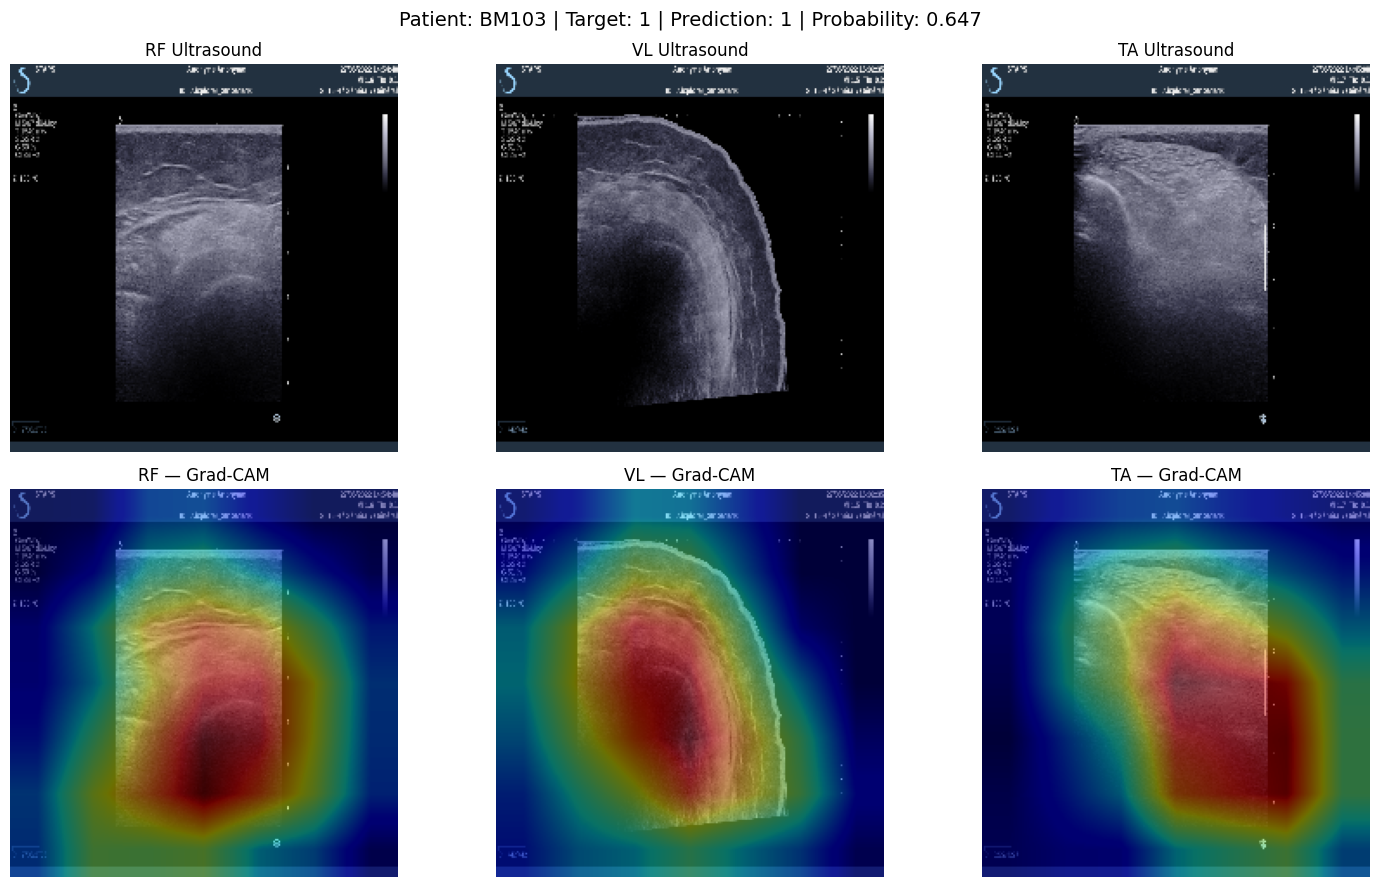


GRAD-CAM COMPLETE
Patient: BM103
True target: 1
Prediction: 1
Probability: 0.6472

Saved: /content/multimuscle_gradcam.png

✓ RF explanation generated
✓ VL explanation generated
✓ TA explanation generated

IMPORTANT:
Grad-CAM shows regions influencing the model; it does NOT establish clinical causality.


In [104]:
# ============================================================
# CELL 99 — MULTI-MUSCLE GRAD-CAM EXPLAINABILITY
# RF + VL + TA
# ============================================================

import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt


print("=" * 72)
print("MULTIMODAL EXPLAINABILITY — GRAD-CAM")
print("=" * 72)


# ============================================================
# 1. GRAD-CAM CLASS
# ============================================================

class GradCAM:

    def __init__(
        self,
        model,
        target_layer
    ):

        self.model = model
        self.target_layer = target_layer

        self.activations = None
        self.gradients = None

        self.forward_handle = (
            target_layer.register_forward_hook(
                self._forward_hook
            )
        )

        self.backward_handle = (
            target_layer.register_full_backward_hook(
                self._backward_hook
            )
        )


    def _forward_hook(
        self,
        module,
        input,
        output
    ):

        self.activations = output.detach()


    def _backward_hook(
        self,
        module,
        grad_input,
        grad_output
    ):

        self.gradients = grad_output[0].detach()


    def generate(
        self,
        rf,
        vl,
        ta,
        clinical,
        muscle="RF"
    ):

        self.model.eval()

        self.model.zero_grad(
            set_to_none=True
        )


        # ----------------------------------------------------
        # FORWARD PASS
        # ----------------------------------------------------

        logits = self.model(
            rf,
            vl,
            ta,
            clinical
        )


        probability = torch.sigmoid(
            logits
        ).item()


        # ----------------------------------------------------
        # BACKPROPAGATE POSITIVE-CLASS SCORE
        # ----------------------------------------------------

        logits.backward(
            gradient=torch.ones_like(logits)
        )


        # ----------------------------------------------------
        # GET GRADIENTS + ACTIVATIONS
        # ----------------------------------------------------

        gradients = self.gradients

        activations = self.activations


        # Global-average-pool gradients
        weights = gradients.mean(
            dim=(2, 3),
            keepdim=True
        )


        cam = (
            weights * activations
        ).sum(
            dim=1,
            keepdim=True
        )


        cam = F.relu(
            cam
        )


        # Resize heatmap to input size
        cam = F.interpolate(

            cam,

            size=(
                224,
                224
            ),

            mode="bilinear",

            align_corners=False
        )


        cam = cam[
            0,
            0
        ]


        # Normalize 0 → 1
        cam_min = cam.min()
        cam_max = cam.max()

        cam = (
            cam - cam_min
        ) / (
            cam_max
            - cam_min
            + 1e-8
        )


        return (
            cam.cpu().numpy(),
            probability
        )


    def remove_hooks(self):

        self.forward_handle.remove()
        self.backward_handle.remove()


# ============================================================
# 2. SELECT ONE TEST PATIENT
# ============================================================

sample = multimodal_test_dataset[0]

patient_id = sample[
    "patient_id"
]

target = int(
    sample[
        "target"
    ].item()
)


rf = (
    sample[
        "rf_image"
    ]
    .unsqueeze(0)
    .to(device)
)

vl = (
    sample[
        "vl_image"
    ]
    .unsqueeze(0)
    .to(device)
)

ta = (
    sample[
        "ta_image"
    ]
    .unsqueeze(0)
    .to(device)
)

clinical = (
    sample[
        "clinical"
    ]
    .unsqueeze(0)
    .to(device)
)


# ============================================================
# 3. TARGET LAYER
# ============================================================
#
# image_encoder[7] = ResNet layer4
#
# layer4[-1].conv2 = final convolution layer
# ============================================================

target_layer = (
    fusion_model
    .image_encoder[7][-1]
    .conv2
)


gradcam = GradCAM(
    fusion_model,
    target_layer
)


# ============================================================
# 4. IMPORTANT:
# SHARED ENCODER MEANS EACH FORWARD PASS OVERWRITES THE HOOK.
#
# Therefore we temporarily isolate each muscle by performing
# separate forward/backward passes.
# ============================================================


def generate_muscle_cam(
    muscle_name
):

    fusion_model.eval()

    fusion_model.zero_grad(
        set_to_none=True
    )


    # --------------------------------------------------------
    # Manual forward pass so we can capture the chosen muscle
    # --------------------------------------------------------

    rf_features = (
        fusion_model.encode_image(
            rf
        )
    )

    rf_activation = (
        gradcam.activations
    )


    vl_features = (
        fusion_model.encode_image(
            vl
        )
    )

    vl_activation = (
        gradcam.activations
    )


    ta_features = (
        fusion_model.encode_image(
            ta
        )
    )

    ta_activation = (
        gradcam.activations
    )


    # --------------------------------------------------------
    # We need gradients attached, so perform chosen muscle
    # last before fusion.
    # --------------------------------------------------------

    if muscle_name == "RF":

        vl_features = (
            fusion_model.encode_image(
                vl
            )
        )

        ta_features = (
            fusion_model.encode_image(
                ta
            )
        )

        rf_features = (
            fusion_model.encode_image(
                rf
            )
        )

        chosen_image = rf


    elif muscle_name == "VL":

        rf_features = (
            fusion_model.encode_image(
                rf
            )
        )

        ta_features = (
            fusion_model.encode_image(
                ta
            )
        )

        vl_features = (
            fusion_model.encode_image(
                vl
            )
        )

        chosen_image = vl


    else:

        rf_features = (
            fusion_model.encode_image(
                rf
            )
        )

        vl_features = (
            fusion_model.encode_image(
                vl
            )
        )

        ta_features = (
            fusion_model.encode_image(
                ta
            )
        )

        chosen_image = ta


    # --------------------------------------------------------
    # Same fusion logic as model.forward()
    # --------------------------------------------------------

    muscle_features = torch.stack(

        [
            rf_features,
            vl_features,
            ta_features
        ],

        dim=1

    ).mean(
        dim=1
    )


    clinical_features = (
        fusion_model
        .clinical_encoder(
            clinical
        )
    )


    fused_features = torch.cat(

        [
            muscle_features,
            clinical_features
        ],

        dim=1
    )


    logits = (
        fusion_model
        .fusion_classifier(
            fused_features
        )
    )


    probability = torch.sigmoid(
        logits
    ).item()


    # --------------------------------------------------------
    # BACKWARD
    # --------------------------------------------------------

    logits.backward()


    gradients = (
        gradcam.gradients
    )

    activations = (
        gradcam.activations
    )


    weights = gradients.mean(

        dim=(2, 3),

        keepdim=True
    )


    cam = (

        weights
        * activations

    ).sum(

        dim=1,
        keepdim=True
    )


    cam = F.relu(
        cam
    )


    cam = F.interpolate(

        cam,

        size=(224, 224),

        mode="bilinear",

        align_corners=False
    )


    cam = cam[
        0,
        0
    ]


    cam = (

        cam - cam.min()

    ) / (

        cam.max()
        - cam.min()
        + 1e-8
    )


    return (

        cam.detach()
        .cpu()
        .numpy(),

        chosen_image,

        probability
    )


# ============================================================
# 5. GENERATE RF / VL / TA CAMs
# ============================================================

rf_cam, rf_tensor, probability = (
    generate_muscle_cam(
        "RF"
    )
)

vl_cam, vl_tensor, _ = (
    generate_muscle_cam(
        "VL"
    )
)

ta_cam, ta_tensor, _ = (
    generate_muscle_cam(
        "TA"
    )
)


prediction = int(
    probability >= 0.5
)


# ============================================================
# 6. CONVERT NORMALIZED IMAGE BACK FOR DISPLAY
# ============================================================

IMAGENET_MEAN = np.array(
    [0.485, 0.456, 0.406]
)

IMAGENET_STD = np.array(
    [0.229, 0.224, 0.225]
)


def tensor_to_display(
    tensor
):

    image = (
        tensor[0]
        .detach()
        .cpu()
        .permute(
            1,
            2,
            0
        )
        .numpy()
    )


    image = (

        image
        * IMAGENET_STD

        + IMAGENET_MEAN
    )


    image = np.clip(
        image,
        0,
        1
    )


    return image


rf_display = tensor_to_display(
    rf_tensor
)

vl_display = tensor_to_display(
    vl_tensor
)

ta_display = tensor_to_display(
    ta_tensor
)


# ============================================================
# 7. VISUALIZE
# ============================================================

fig, axes = plt.subplots(
    2,
    3,
    figsize=(15, 9)
)


# ------------------------------------------------------------
# ORIGINAL IMAGES
# ------------------------------------------------------------

axes[0, 0].imshow(
    rf_display
)

axes[0, 0].set_title(
    "RF Ultrasound"
)

axes[0, 0].axis(
    "off"
)


axes[0, 1].imshow(
    vl_display
)

axes[0, 1].set_title(
    "VL Ultrasound"
)

axes[0, 1].axis(
    "off"
)


axes[0, 2].imshow(
    ta_display
)

axes[0, 2].set_title(
    "TA Ultrasound"
)

axes[0, 2].axis(
    "off"
)


# ------------------------------------------------------------
# GRAD-CAM OVERLAYS
# ------------------------------------------------------------

axes[1, 0].imshow(
    rf_display
)

axes[1, 0].imshow(
    rf_cam,
    alpha=0.45,
    cmap="jet"
)

axes[1, 0].set_title(
    "RF — Grad-CAM"
)

axes[1, 0].axis(
    "off"
)


axes[1, 1].imshow(
    vl_display
)

axes[1, 1].imshow(
    vl_cam,
    alpha=0.45,
    cmap="jet"
)

axes[1, 1].set_title(
    "VL — Grad-CAM"
)

axes[1, 1].axis(
    "off"
)


axes[1, 2].imshow(
    ta_display
)

axes[1, 2].imshow(
    ta_cam,
    alpha=0.45,
    cmap="jet"
)

axes[1, 2].set_title(
    "TA — Grad-CAM"
)

axes[1, 2].axis(
    "off"
)


plt.suptitle(

    f"Patient: {patient_id} | "
    f"Target: {target} | "
    f"Prediction: {prediction} | "
    f"Probability: {probability:.3f}",

    fontsize=14
)


plt.tight_layout()


GRADCAM_PATH = (
    "/content/multimuscle_gradcam.png"
)


plt.savefig(
    GRADCAM_PATH,
    dpi=200,
    bbox_inches="tight"
)


plt.show()


# ============================================================
# 8. CLEAN HOOKS
# ============================================================

gradcam.remove_hooks()


# ============================================================
# 9. FINAL STATUS
# ============================================================

print("\n" + "=" * 72)
print("GRAD-CAM COMPLETE")
print("=" * 72)

print(
    "Patient:",
    patient_id
)

print(
    "True target:",
    target
)

print(
    "Prediction:",
    prediction
)

print(
    "Probability:",
    round(
        probability,
        4
    )
)

print(
    "\nSaved:",
    GRADCAM_PATH
)

print(
    "\n✓ RF explanation generated"
)

print(
    "✓ VL explanation generated"
)

print(
    "✓ TA explanation generated"
)

print(
    "\nIMPORTANT:"
)

print(
    "Grad-CAM shows regions influencing the model; "
    "it does NOT establish clinical causality."
)

In [105]:
# ============================================================
# CELL 100
# REUSABLE MULTIMODAL INFERENCE
# + SAVE PROJECT ARTIFACTS
# + AUTOMATIC DOWNLOAD
# ============================================================

import os
import json
import shutil
import joblib
import numpy as np
import pandas as pd
import torch

from pathlib import Path
from google.colab import files


print("=" * 72)
print("SARCOPENIAAI — INFERENCE + ARTIFACT PACKAGING")
print("=" * 72)


# ============================================================
# 1. PROJECT DIRECTORY
# ============================================================

PROJECT_ROOT = Path("/content/SarcopeniaAI")
MODEL_DIR = PROJECT_ROOT / "models"
ASSET_DIR = PROJECT_ROOT / "assets"
RESULT_DIR = PROJECT_ROOT / "results"

for directory in [
    PROJECT_ROOT,
    MODEL_DIR,
    ASSET_DIR,
    RESULT_DIR
]:
    directory.mkdir(
        parents=True,
        exist_ok=True
    )


print("\n✓ Project folders created")


# ============================================================
# 2. SAVE CLINICAL SCALER
# ============================================================

SCALER_FILE = MODEL_DIR / "clinical_scaler.pkl"

joblib.dump(
    scaler,
    SCALER_FILE
)

print("✓ Clinical scaler saved")


# ============================================================
# 3. COPY FINAL MULTIMODAL MODEL
# ============================================================

source_model = Path(
    "/content/sarcopenia_multimodal_final.pth"
)

final_model_file = (
    MODEL_DIR /
    "sarcopenia_multimodal_final.pth"
)

if source_model.exists():

    shutil.copy2(
        source_model,
        final_model_file
    )

    print(
        "✓ Final multimodal model copied"
    )

else:

    # Fallback: save current model directly

    torch.save(
        {
            "model_state_dict":
                fusion_model.state_dict(),

            "architecture":
                "RF_VL_TA_ResNet18_Clinical_Fusion",

            "clinical_features":
                CLINICAL_FEATURES,

            "target":
                TARGET
        },
        final_model_file
    )

    print(
        "✓ Current multimodal model saved"
    )


# ============================================================
# 4. SAVE RESNET BASELINE
# ============================================================

RESNET_FILE = (
    MODEL_DIR /
    "sarcopenia_resnet18.pth"
)

torch.save(
    {
        "model_state_dict":
            resnet_model.state_dict(),

        "architecture":
            "ResNet18",

        "target":
            TARGET,

        "image_size":
            224
    },
    RESNET_FILE
)

print("✓ ResNet18 baseline saved")


# ============================================================
# 5. SAVE CLINICAL MLP
# ============================================================

CLINICAL_FILE = (
    MODEL_DIR /
    "clinical_mlp.pth"
)

torch.save(
    {
        "model_state_dict":
            clinical_model.state_dict(),

        "architecture":
            "ClinicalMLP",

        "features":
            CLINICAL_FEATURES,

        "input_features":
            len(CLINICAL_FEATURES),

        "target":
            TARGET
    },
    CLINICAL_FILE
)

print("✓ Clinical MLP saved")


# ============================================================
# 6. COPY GRAD-CAM IMAGE
# ============================================================

gradcam_source = Path(
    "/content/multimuscle_gradcam.png"
)

gradcam_destination = (
    ASSET_DIR /
    "multimuscle_gradcam.png"
)

if gradcam_source.exists():

    shutil.copy2(
        gradcam_source,
        gradcam_destination
    )

    print("✓ Grad-CAM figure copied")


# ============================================================
# 7. COPY RESULT CSV FILES
# ============================================================

result_files = {

    "/content/sarcopenia_model_comparison.csv":
        RESULT_DIR /
        "model_comparison.csv",

    "/content/sarcopenia_multimodal_test_predictions.csv":
        RESULT_DIR /
        "multimodal_test_predictions.csv"
}


for source, destination in result_files.items():

    source = Path(source)

    if source.exists():

        shutil.copy2(
            source,
            destination
        )

        print(
            "✓ Copied:",
            destination.name
        )


# ============================================================
# 8. SAVE PROJECT CONFIGURATION
# ============================================================

project_config = {

    "project":
        "SarcopeniaAI",

    "task":
        "Research-oriented low muscle strength assessment",

    "target":
        TARGET,

    "clinical_features":
        CLINICAL_FEATURES,

    "muscles":
        [
            "RF",
            "VL",
            "TA"
        ],

    "image_size":
        224,

    "image_channels":
        3,

    "image_encoder":
        "ResNet18",

    "image_feature_dimension":
        512,

    "clinical_feature_dimension":
        8,

    "fusion_feature_dimension":
        520,

    "classification_threshold":
        0.5,

    "research_disclaimer":
        (
            "Research and educational prototype. "
            "Not intended for clinical diagnosis."
        )
}


CONFIG_FILE = (
    PROJECT_ROOT /
    "config.json"
)

with open(
    CONFIG_FILE,
    "w"
) as file:

    json.dump(
        project_config,
        file,
        indent=4
    )


print("✓ config.json saved")


# ============================================================
# 9. REUSABLE PATIENT INFERENCE FUNCTION
# ============================================================

def predict_patient(
    model,
    rf_tensor,
    vl_tensor,
    ta_tensor,
    clinical_values,
    scaler,
    device,
    threshold=0.5
):

    """
    Predict low-muscle-strength probability
    from:

        RF ultrasound
        VL ultrasound
        TA ultrasound
        Age
        Height
        Weight
        Sex

    Returns:
        probability
        predicted class
        interpretation
    """

    model.eval()


    # --------------------------------------------------------
    # IMAGE INPUTS
    # --------------------------------------------------------

    if rf_tensor.ndim == 3:
        rf_tensor = rf_tensor.unsqueeze(0)

    if vl_tensor.ndim == 3:
        vl_tensor = vl_tensor.unsqueeze(0)

    if ta_tensor.ndim == 3:
        ta_tensor = ta_tensor.unsqueeze(0)


    rf_tensor = rf_tensor.to(
        device
    )

    vl_tensor = vl_tensor.to(
        device
    )

    ta_tensor = ta_tensor.to(
        device
    )


    # --------------------------------------------------------
    # CLINICAL INPUT
    # --------------------------------------------------------

    if isinstance(
        clinical_values,
        dict
    ):

        clinical_values = pd.DataFrame(
            [[
                clinical_values[
                    feature
                ]
                for feature
                in CLINICAL_FEATURES
            ]],
            columns=CLINICAL_FEATURES
        )

    elif not isinstance(
        clinical_values,
        pd.DataFrame
    ):

        clinical_values = pd.DataFrame(
            [
                np.asarray(
                    clinical_values,
                    dtype=np.float32
                )
            ],
            columns=CLINICAL_FEATURES
        )


    clinical_scaled = (
        scaler.transform(
            clinical_values[
                CLINICAL_FEATURES
            ]
        )
    )


    clinical_tensor = torch.tensor(
        clinical_scaled,
        dtype=torch.float32
    ).to(
        device
    )


    # --------------------------------------------------------
    # MODEL INFERENCE
    # --------------------------------------------------------

    with torch.no_grad():

        logits = model(
            rf_tensor,
            vl_tensor,
            ta_tensor,
            clinical_tensor
        )

        probability = (
            torch.sigmoid(
                logits
            )
            .squeeze()
            .item()
        )


    prediction = int(
        probability >= threshold
    )


    if prediction == 1:

        interpretation = (
            "Model output indicates higher probability "
            "of low muscle strength."
        )

    else:

        interpretation = (
            "Model output indicates lower probability "
            "of low muscle strength."
        )


    return {

        "probability":
            probability,

        "prediction":
            prediction,

        "interpretation":
            interpretation,

        "threshold":
            threshold
    }


# ============================================================
# 10. TEST INFERENCE ON ONE EXISTING TEST PATIENT
# ============================================================

sample = multimodal_test_dataset[0]

patient_id = sample[
    "patient_id"
]


# Recover original clinical values
patient_row = (
    complete_multimodal_df[
        complete_multimodal_df[
            "patient_id"
        ] == patient_id
    ]
    .iloc[0]
)


clinical_input = {

    feature:
        float(
            patient_row[
                feature
            ]
        )

    for feature
    in CLINICAL_FEATURES
}


inference_result = predict_patient(

    model=
        fusion_model,

    rf_tensor=
        sample[
            "rf_image"
        ],

    vl_tensor=
        sample[
            "vl_image"
        ],

    ta_tensor=
        sample[
            "ta_image"
        ],

    clinical_values=
        clinical_input,

    scaler=
        scaler,

    device=
        device
)


print("\n" + "=" * 72)
print("INFERENCE TEST")
print("=" * 72)

print(
    "Patient:",
    patient_id
)

print(
    "True target:",
    int(
        sample[
            "target"
        ].item()
    )
)

print(
    "Probability:",
    round(
        inference_result[
            "probability"
        ],
        4
    )
)

print(
    "Prediction:",
    inference_result[
        "prediction"
    ]
)

print(
    "Interpretation:",
    inference_result[
        "interpretation"
    ]
)


# ============================================================
# 11. SAVE INFERENCE EXAMPLE
# ============================================================

inference_example = {

    "patient_id":
        patient_id,

    "true_target":
        int(
            sample[
                "target"
            ].item()
        ),

    "probability":
        float(
            inference_result[
                "probability"
            ]
        ),

    "prediction":
        int(
            inference_result[
                "prediction"
            ]
        ),

    "interpretation":
        inference_result[
            "interpretation"
        ]
}


INFERENCE_EXAMPLE_FILE = (
    RESULT_DIR /
    "inference_example.json"
)

with open(
    INFERENCE_EXAMPLE_FILE,
    "w"
) as file:

    json.dump(
        inference_example,
        file,
        indent=4
    )


print(
    "\n✓ Inference example saved"
)


# ============================================================
# 12. CREATE MODEL CARD
# ============================================================

model_card = """# SarcopeniaAI Model Card

## Purpose

SarcopeniaAI is a research-oriented multimodal deep-learning
prototype for estimating low-muscle-strength risk.

It combines ultrasound information from:

- Rectus Femoris (RF)
- Vastus Lateralis (VL)
- Tibialis Anterior (TA)

with four clinical variables:

- Age
- Height
- Weight
- Sex

## Architecture

Image branch:
ResNet18 ultrasound encoder.

Clinical branch:
Multilayer perceptron.

Fusion:
Image and clinical representations are combined using
feature-level fusion.

## Target

Binary low-muscle-strength research target.

## Explainability

Grad-CAM is used to visualize ultrasound regions that
influence model predictions.

## Important Limitation

The development dataset contains a very small number of
patients. The final multimodal test subset contains only
seven complete RF/VL/TA patients.

The model showed poor generalization and should NOT be
interpreted as a validated clinical diagnostic system.

## Intended Use

Educational, portfolio, and research demonstration only.

NOT FOR CLINICAL DIAGNOSIS.
"""


MODEL_CARD_FILE = (
    PROJECT_ROOT /
    "MODEL_CARD.md"
)

MODEL_CARD_FILE.write_text(
    model_card
)


print(
    "✓ MODEL_CARD.md saved"
)


# ============================================================
# 13. CREATE GITIGNORE
# ============================================================

gitignore = """# Python
__pycache__/
*.py[cod]

# Colab / Jupyter
.ipynb_checkpoints/

# Environment
.env
venv/
.venv/

# Streamlit secrets
.streamlit/secrets.toml

# OS files
.DS_Store
Thumbs.db

# Raw medical data
data/
dataset/
*.dcm

# Temporary files
tmp/
temp/
"""


GITIGNORE_FILE = (
    PROJECT_ROOT /
    ".gitignore"
)

GITIGNORE_FILE.write_text(
    gitignore
)


print(
    "✓ .gitignore saved"
)


# ============================================================
# 14. SHOW CURRENT PROJECT STRUCTURE
# ============================================================

print("\n" + "=" * 72)
print("CURRENT GITHUB PROJECT")
print("=" * 72)


for path in sorted(
    PROJECT_ROOT.rglob("*")
):

    if path.is_file():

        relative_path = (
            path.relative_to(
                PROJECT_ROOT
            )
        )

        size_mb = (
            path.stat().st_size
            / (
                1024 ** 2
            )
        )

        print(
            f"{str(relative_path):50s} "
            f"{size_mb:8.2f} MB"
        )


# ============================================================
# 15. CREATE ZIP BACKUP
# ============================================================

ZIP_PATH = shutil.make_archive(

    "/content/SarcopeniaAI_Current",

    "zip",

    PROJECT_ROOT
)


print("\n" + "=" * 72)
print("PACKAGING COMPLETE")
print("=" * 72)

print(
    "Project:",
    PROJECT_ROOT
)

print(
    "ZIP:",
    ZIP_PATH
)


# ============================================================
# 16. AUTOMATIC DOWNLOAD
# ============================================================
#
# Colab cannot directly write to Windows Desktop.
# This triggers your browser download.
#
# IMPORTANT:
# We download ONE ZIP instead of many separate browser prompts.
# ============================================================

print(
    "\nStarting browser download..."
)

print(
    "Save SarcopeniaAI_Current.zip on your "
    "Desktop when your browser asks."
)


files.download(
    ZIP_PATH
)


print("\n" + "=" * 72)
print("CELL 100 COMPLETE")
print("=" * 72)

print(
    "✓ Reusable inference function created"
)

print(
    "✓ Inference tested"
)

print(
    "✓ Final multimodal model packaged"
)

print(
    "✓ ResNet18 packaged"
)

print(
    "✓ Clinical MLP packaged"
)

print(
    "✓ Clinical scaler packaged"
)

print(
    "✓ Grad-CAM packaged"
)

print(
    "✓ Results packaged"
)

print(
    "✓ Model card created"
)

print(
    "✓ .gitignore created"
)

print(
    "✓ ZIP download triggered"
)

SARCOPENIAAI — INFERENCE + ARTIFACT PACKAGING

✓ Project folders created
✓ Clinical scaler saved
✓ Final multimodal model copied
✓ ResNet18 baseline saved
✓ Clinical MLP saved
✓ Grad-CAM figure copied
✓ Copied: model_comparison.csv
✓ Copied: multimodal_test_predictions.csv
✓ config.json saved


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(



INFERENCE TEST
Patient: BM103
True target: 1
Probability: 0.6472
Prediction: 1
Interpretation: Model output indicates higher probability of low muscle strength.

✓ Inference example saved
✓ MODEL_CARD.md saved
✓ .gitignore saved

CURRENT GITHUB PROJECT
.gitignore                                             0.00 MB
MODEL_CARD.md                                          0.00 MB
assets/multimuscle_gradcam.png                         0.48 MB
config.json                                            0.00 MB
models/clinical_mlp.pth                                0.00 MB
models/clinical_scaler.pkl                             0.00 MB
models/sarcopenia_multimodal_final.pth                42.99 MB
models/sarcopenia_resnet18.pth                        42.71 MB
results/inference_example.json                         0.00 MB
results/model_comparison.csv                           0.00 MB
results/multimodal_test_predictions.csv                0.00 MB

PACKAGING COMPLETE
Project: /content/SarcopeniaAI
ZI

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


CELL 100 COMPLETE
✓ Reusable inference function created
✓ Inference tested
✓ Final multimodal model packaged
✓ ResNet18 packaged
✓ Clinical MLP packaged
✓ Clinical scaler packaged
✓ Grad-CAM packaged
✓ Results packaged
✓ Model card created
✓ .gitignore created
✓ ZIP download triggered


In [106]:
# ============================================================
# CELL 101
# CREATE COMPLETE STREAMLIT APP
# + REQUIREMENTS
# + FINAL APP PACKAGE
# ============================================================

from pathlib import Path
import shutil
from google.colab import files

print("=" * 72)
print("SARCOPENIAAI — BUILDING STREAMLIT APPLICATION")
print("=" * 72)

PROJECT_ROOT = Path("/content/SarcopeniaAI")
PROJECT_ROOT.mkdir(parents=True, exist_ok=True)


# ============================================================
# 1. STREAMLIT APPLICATION
# ============================================================

APP_CODE = r'''
import io
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
import streamlit as st
import torch
import torch.nn as nn
import torch.nn.functional as F
from PIL import Image
import pydicom
from torchvision.models import resnet18


# ============================================================
# PAGE CONFIG
# ============================================================

st.set_page_config(
    page_title="SarcopeniaAI",
    page_icon="🧠",
    layout="wide"
)


# ============================================================
# PATHS
# ============================================================

BASE_DIR = Path(__file__).resolve().parent

MODEL_PATH = (
    BASE_DIR
    / "models"
    / "sarcopenia_multimodal_final.pth"
)

SCALER_PATH = (
    BASE_DIR
    / "models"
    / "clinical_scaler.pkl"
)

GRADCAM_PATH = (
    BASE_DIR
    / "assets"
    / "multimuscle_gradcam.png"
)


CLINICAL_FEATURES = [
    "Age",
    "Taille",
    "Poids",
    "Sexe"
]

DEVICE = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)


# ============================================================
# MODEL ARCHITECTURE
# ============================================================

class MultimodalFusionNetwork(nn.Module):

    def __init__(
        self,
        clinical_input_dim=4
    ):

        super().__init__()

        backbone = resnet18(
            weights=None
        )

        self.image_encoder = nn.Sequential(
            *list(
                backbone.children()
            )[:-1]
        )

        self.clinical_encoder = nn.Sequential(
            nn.Linear(
                clinical_input_dim,
                16
            ),
            nn.ReLU(),
            nn.Dropout(
                0.20
            ),
            nn.Linear(
                16,
                8
            ),
            nn.ReLU()
        )

        self.fusion_classifier = nn.Sequential(
            nn.Linear(
                512 + 8,
                128
            ),
            nn.ReLU(),
            nn.Dropout(
                0.40
            ),
            nn.Linear(
                128,
                32
            ),
            nn.ReLU(),
            nn.Dropout(
                0.20
            ),
            nn.Linear(
                32,
                1
            )
        )


    def encode_image(
        self,
        image
    ):

        features = self.image_encoder(
            image
        )

        return torch.flatten(
            features,
            1
        )


    def forward(
        self,
        rf,
        vl,
        ta,
        clinical
    ):

        rf_features = self.encode_image(
            rf
        )

        vl_features = self.encode_image(
            vl
        )

        ta_features = self.encode_image(
            ta
        )

        muscle_features = torch.stack(
            [
                rf_features,
                vl_features,
                ta_features
            ],
            dim=1
        ).mean(
            dim=1
        )

        clinical_features = (
            self.clinical_encoder(
                clinical
            )
        )

        fused_features = torch.cat(
            [
                muscle_features,
                clinical_features
            ],
            dim=1
        )

        return self.fusion_classifier(
            fused_features
        )


# ============================================================
# LOAD MODEL + SCALER
# ============================================================

@st.cache_resource
def load_resources():

    if not MODEL_PATH.exists():
        raise FileNotFoundError(
            f"Model not found: {MODEL_PATH}"
        )

    if not SCALER_PATH.exists():
        raise FileNotFoundError(
            f"Scaler not found: {SCALER_PATH}"
        )

    model = MultimodalFusionNetwork(
        clinical_input_dim=4
    )

    checkpoint = torch.load(
        MODEL_PATH,
        map_location=DEVICE,
        weights_only=False
    )

    model.load_state_dict(
        checkpoint[
            "model_state_dict"
        ]
    )

    model.to(
        DEVICE
    )

    model.eval()

    scaler = joblib.load(
        SCALER_PATH
    )

    return model, scaler


# ============================================================
# IMAGE PREPROCESSING
# ============================================================

IMAGENET_MEAN = torch.tensor(
    [
        0.485,
        0.456,
        0.406
    ]
).view(
    3,
    1,
    1
)

IMAGENET_STD = torch.tensor(
    [
        0.229,
        0.224,
        0.225
    ]
).view(
    3,
    1,
    1
)


def prepare_rgb_array(
    image_array
):

    image_array = np.asarray(
        image_array
    )


    # --------------------------------------------------------
    # GRAYSCALE → RGB
    # --------------------------------------------------------

    if image_array.ndim == 2:

        image_array = np.stack(
            [
                image_array,
                image_array,
                image_array
            ],
            axis=-1
        )


    # --------------------------------------------------------
    # CHANNEL FIRST → CHANNEL LAST
    # --------------------------------------------------------

    if (
        image_array.ndim == 3
        and image_array.shape[0] in [1, 3]
        and image_array.shape[-1] not in [1, 3, 4]
    ):

        image_array = np.moveaxis(
            image_array,
            0,
            -1
        )


    # --------------------------------------------------------
    # REMOVE ALPHA
    # --------------------------------------------------------

    if (
        image_array.ndim == 3
        and image_array.shape[-1] == 4
    ):

        image_array = image_array[
            ...,
            :3
        ]


    # --------------------------------------------------------
    # SINGLE CHANNEL → RGB
    # --------------------------------------------------------

    if (
        image_array.ndim == 3
        and image_array.shape[-1] == 1
    ):

        image_array = np.repeat(
            image_array,
            3,
            axis=-1
        )


    # --------------------------------------------------------
    # NORMALIZE NON-8-BIT DATA FOR DISPLAY/INFERENCE
    # --------------------------------------------------------

    if image_array.dtype != np.uint8:

        image_array = image_array.astype(
            np.float32
        )

        minimum = np.nanmin(
            image_array
        )

        maximum = np.nanmax(
            image_array
        )

        if maximum > minimum:

            image_array = (
                image_array
                - minimum
            ) / (
                maximum
                - minimum
            )

            image_array = (
                image_array
                * 255.0
            )

        image_array = np.clip(
            image_array,
            0,
            255
        ).astype(
            np.uint8
        )


    if (
        image_array.ndim != 3
        or image_array.shape[-1] != 3
    ):

        raise ValueError(
            "Could not convert uploaded image to RGB."
        )


    return image_array


def read_uploaded_image(
    uploaded_file
):

    file_name = (
        uploaded_file.name.lower()
    )

    raw_bytes = (
        uploaded_file.getvalue()
    )


    # --------------------------------------------------------
    # DICOM
    # --------------------------------------------------------

    if (
        file_name.endswith(".dcm")
        or "." not in uploaded_file.name
    ):

        dicom = pydicom.dcmread(
            io.BytesIO(
                raw_bytes
            )
        )

        image_array = (
            dicom.pixel_array
        )


    # --------------------------------------------------------
    # PNG / JPG / JPEG
    # --------------------------------------------------------

    else:

        image = Image.open(
            io.BytesIO(
                raw_bytes
            )
        ).convert(
            "RGB"
        )

        image_array = np.array(
            image
        )


    return prepare_rgb_array(
        image_array
    )


def preprocess_image(
    image_array
):

    tensor = torch.from_numpy(
        image_array.copy()
    )

    tensor = tensor.permute(
        2,
        0,
        1
    ).float() / 255.0

    tensor = tensor.unsqueeze(
        0
    )

    tensor = F.interpolate(
        tensor,
        size=(
            224,
            224
        ),
        mode="bilinear",
        align_corners=False
    )

    tensor = tensor.squeeze(
        0
    )

    tensor = (
        tensor
        - IMAGENET_MEAN
    ) / IMAGENET_STD

    return tensor


# ============================================================
# INFERENCE
# ============================================================

def predict(
    model,
    scaler,
    rf_array,
    vl_array,
    ta_array,
    age,
    height,
    weight,
    sex
):

    rf = preprocess_image(
        rf_array
    ).unsqueeze(
        0
    ).to(
        DEVICE
    )

    vl = preprocess_image(
        vl_array
    ).unsqueeze(
        0
    ).to(
        DEVICE
    )

    ta = preprocess_image(
        ta_array
    ).unsqueeze(
        0
    ).to(
        DEVICE
    )


    clinical_df = pd.DataFrame(
        [
            {
                "Age":
                    float(age),

                "Taille":
                    float(height),

                "Poids":
                    float(weight),

                "Sexe":
                    float(sex)
            }
        ],
        columns=CLINICAL_FEATURES
    )


    clinical_scaled = (
        scaler.transform(
            clinical_df
        )
    )


    clinical_tensor = torch.tensor(
        clinical_scaled,
        dtype=torch.float32
    ).to(
        DEVICE
    )


    with torch.no_grad():

        logits = model(
            rf,
            vl,
            ta,
            clinical_tensor
        )

        probability = (
            torch.sigmoid(
                logits
            )
            .squeeze()
            .item()
        )


    prediction = int(
        probability >= 0.5
    )

    return (
        probability,
        prediction
    )


# ============================================================
# HEADER
# ============================================================

st.title(
    "SarcopeniaAI"
)

st.subheader(
    "Explainable Multimodal AI for Muscle Health Research"
)

st.write(
    """
    SarcopeniaAI combines ultrasound images from three muscle
    groups with basic clinical information to demonstrate a
    multimodal deep-learning pipeline for low-muscle-strength
    research.
    """
)


st.warning(
    "Research and educational prototype only. "
    "This application is NOT a medical diagnostic tool."
)


# ============================================================
# ABOUT PIPELINE
# ============================================================

with st.expander(
    "How does the model work?"
):

    st.markdown(
        """
        **Inputs**

        1. Rectus Femoris (RF) ultrasound
        2. Vastus Lateralis (VL) ultrasound
        3. Tibialis Anterior (TA) ultrasound
        4. Age
        5. Height
        6. Weight
        7. Sex

        **Model**

        - ResNet18 extracts ultrasound representations.
        - A clinical MLP processes clinical variables.
        - RF, VL and TA information is combined.
        - Image and clinical representations are fused.
        - The network outputs a research probability for
          low muscle strength.

        **Important:** the development dataset is small,
        so predictions should not be interpreted clinically.
        """
    )


# ============================================================
# LOAD RESOURCES
# ============================================================

try:

    model, scaler = load_resources()

except Exception as error:

    st.error(
        f"Could not load model resources: {error}"
    )

    st.stop()


# ============================================================
# INPUT AREA
# ============================================================

st.header(
    "1. Upload Muscle Ultrasound Images"
)

st.caption(
    "Supported formats: DICOM (.dcm), PNG, JPG and JPEG."
)


col1, col2, col3 = st.columns(
    3
)


with col1:

    rf_file = st.file_uploader(
        "Rectus Femoris (RF)",
        type=[
            "dcm",
            "png",
            "jpg",
            "jpeg"
        ],
        key="rf"
    )


with col2:

    vl_file = st.file_uploader(
        "Vastus Lateralis (VL)",
        type=[
            "dcm",
            "png",
            "jpg",
            "jpeg"
        ],
        key="vl"
    )


with col3:

    ta_file = st.file_uploader(
        "Tibialis Anterior (TA)",
        type=[
            "dcm",
            "png",
            "jpg",
            "jpeg"
        ],
        key="ta"
    )


# ============================================================
# PREVIEW
# ============================================================

rf_array = None
vl_array = None
ta_array = None


if rf_file is not None:

    try:

        rf_array = read_uploaded_image(
            rf_file
        )

        with col1:

            st.image(
                rf_array,
                caption="RF Preview",
                use_container_width=True
            )

    except Exception as error:

        st.error(
            f"RF image error: {error}"
        )


if vl_file is not None:

    try:

        vl_array = read_uploaded_image(
            vl_file
        )

        with col2:

            st.image(
                vl_array,
                caption="VL Preview",
                use_container_width=True
            )

    except Exception as error:

        st.error(
            f"VL image error: {error}"
        )


if ta_file is not None:

    try:

        ta_array = read_uploaded_image(
            ta_file
        )

        with col3:

            st.image(
                ta_array,
                caption="TA Preview",
                use_container_width=True
            )

    except Exception as error:

        st.error(
            f"TA image error: {error}"
        )


# ============================================================
# CLINICAL INPUT
# ============================================================

st.header(
    "2. Enter Clinical Information"
)


clinical_col1, clinical_col2 = (
    st.columns(
        2
    )
)


with clinical_col1:

    age = st.number_input(
        "Age (years)",
        min_value=18,
        max_value=120,
        value=65,
        step=1
    )

    height = st.number_input(
        "Height (cm)",
        min_value=100.0,
        max_value=220.0,
        value=165.0,
        step=0.1
    )


with clinical_col2:

    weight = st.number_input(
        "Weight (kg)",
        min_value=25.0,
        max_value=250.0,
        value=65.0,
        step=0.1
    )

    sex_label = st.selectbox(
        "Sex",
        [
            "Female",
            "Male"
        ]
    )


# Dataset coding used during training:
# 0 = female
# 1 = male

sex = (
    0
    if sex_label == "Female"
    else 1
)


# ============================================================
# PREDICTION
# ============================================================

st.header(
    "3. Run Multimodal Assessment"
)


ready = all(
    image is not None
    for image in [
        rf_array,
        vl_array,
        ta_array
    ]
)


if not ready:

    st.info(
        "Upload RF, VL and TA ultrasound images "
        "to enable assessment."
    )


if st.button(
    "Analyze Patient",
    type="primary",
    disabled=not ready,
    use_container_width=True
):

    try:

        with st.spinner(
            "Analyzing multimodal patient data..."
        ):

            probability, prediction = predict(
                model=model,
                scaler=scaler,
                rf_array=rf_array,
                vl_array=vl_array,
                ta_array=ta_array,
                age=age,
                height=height,
                weight=weight,
                sex=sex
            )


        st.header(
            "Assessment Result"
        )


        result_col1, result_col2 = (
            st.columns(
                2
            )
        )


        with result_col1:

            st.metric(
                "Model Probability",
                f"{probability:.1%}"
            )


        with result_col2:

            if prediction == 1:

                st.metric(
                    "Model Output",
                    "Higher Probability"
                )

            else:

                st.metric(
                    "Model Output",
                    "Lower Probability"
                )


        st.progress(
            float(
                np.clip(
                    probability,
                    0.0,
                    1.0
                )
            )
        )


        if prediction == 1:

            st.warning(
                "The research model produced a probability "
                "above its 0.50 classification threshold."
            )

        else:

            st.success(
                "The research model produced a probability "
                "below its 0.50 classification threshold."
            )


        st.caption(
            "This output is a machine-learning research "
            "prediction, not a clinical diagnosis."
        )


        with st.expander(
            "Technical details"
        ):

            st.write(
                f"Device: {DEVICE}"
            )

            st.write(
                f"Threshold: 0.50"
            )

            st.write(
                "Image encoder: ResNet18"
            )

            st.write(
                "Muscles: RF + VL + TA"
            )

            st.write(
                "Clinical variables: "
                "Age + Height + Weight + Sex"
            )


    except Exception as error:

        st.error(
            f"Inference failed: {error}"
        )


# ============================================================
# EXPLAINABILITY EXAMPLE
# ============================================================

st.header(
    "Explainability"
)

st.write(
    """
    Grad-CAM can be used to inspect which ultrasound regions
    influence the image branch of the network. The example
    below was generated from the research experiment.
    """
)


if GRADCAM_PATH.exists():

    st.image(
        str(
            GRADCAM_PATH
        ),
        caption=(
            "Example multi-muscle Grad-CAM visualization"
        ),
        use_container_width=True
    )


st.caption(
    "Grad-CAM visualizations indicate model attention patterns; "
    "they do not establish clinical causality."
)


# ============================================================
# LIMITATIONS
# ============================================================

st.header(
    "Limitations"
)

st.markdown(
    """
    - The development dataset contains a small number of patients.
    - Only patients with complete RF, VL and TA ultrasound data
      were available to the multimodal experiment.
    - The held-out multimodal test subset contained only seven
      patients.
    - The experimental model showed limited generalization.
    - External clinical validation has not been performed.
    - The application must not be used for treatment or diagnosis.
    """
)


# ============================================================
# FOOTER
# ============================================================

st.divider()

st.caption(
    "SarcopeniaAI — PyTorch multimodal AI research prototype"
)
'''


APP_PATH = (
    PROJECT_ROOT /
    "app.py"
)

APP_PATH.write_text(
    APP_CODE,
    encoding="utf-8"
)

print(
    "✓ app.py created"
)


# ============================================================
# 2. REQUIREMENTS.TXT
# ============================================================

REQUIREMENTS = """streamlit
torch
torchvision
numpy
pandas
scikit-learn
joblib
Pillow
pydicom
pylibjpeg
pylibjpeg-libjpeg
"""


REQUIREMENTS_PATH = (
    PROJECT_ROOT /
    "requirements.txt"
)

REQUIREMENTS_PATH.write_text(
    REQUIREMENTS,
    encoding="utf-8"
)

print(
    "✓ requirements.txt created"
)


# ============================================================
# 3. CREATE SIMPLE LOCAL RUN INSTRUCTIONS
# ============================================================

RUN_TEXT = """SarcopeniaAI — Run Locally

1. Open terminal inside this project folder.

2. Install packages:

   pip install -r requirements.txt

3. Start Streamlit:

   streamlit run app.py

4. Open the local URL shown by Streamlit.

Required model files:

models/sarcopenia_multimodal_final.pth
models/clinical_scaler.pkl

The application accepts:

- RF ultrasound
- VL ultrasound
- TA ultrasound
- Age
- Height
- Weight
- Sex

Supported image formats:

- DICOM (.dcm)
- PNG
- JPG
- JPEG

IMPORTANT:
Research/educational prototype only.
Not for clinical diagnosis.
"""


RUN_PATH = (
    PROJECT_ROOT /
    "RUN_APP.txt"
)

RUN_PATH.write_text(
    RUN_TEXT,
    encoding="utf-8"
)

print(
    "✓ RUN_APP.txt created"
)


# ============================================================
# 4. CHECK REQUIRED FILES
# ============================================================

required_files = [

    PROJECT_ROOT /
    "app.py",

    PROJECT_ROOT /
    "requirements.txt",

    PROJECT_ROOT /
    "models" /
    "sarcopenia_multimodal_final.pth",

    PROJECT_ROOT /
    "models" /
    "clinical_scaler.pkl"
]


print(
    "\n" + "=" * 72
)

print(
    "STREAMLIT DEPLOYMENT CHECK"
)

print(
    "=" * 72
)


all_ready = True


for file_path in required_files:

    exists = file_path.exists()

    print(
        ("✓" if exists else "✗"),
        file_path.relative_to(
            PROJECT_ROOT
        )
    )

    if not exists:

        all_ready = False


# ============================================================
# 5. SHOW PROJECT STRUCTURE
# ============================================================

print(
    "\n" + "=" * 72
)

print(
    "PROJECT FILES"
)

print(
    "=" * 72
)


for path in sorted(
    PROJECT_ROOT.rglob("*")
):

    if path.is_file():

        relative = path.relative_to(
            PROJECT_ROOT
        )

        size_mb = (
            path.stat().st_size
            / 1024**2
        )

        print(
            f"{str(relative):55s}"
            f"{size_mb:8.2f} MB"
        )


# ============================================================
# 6. CREATE UPDATED ZIP
# ============================================================

ZIP_BASE = (
    "/content/SarcopeniaAI_With_Streamlit"
)

ZIP_FILE = shutil.make_archive(
    ZIP_BASE,
    "zip",
    PROJECT_ROOT
)


print(
    "\n" + "=" * 72
)

print(
    "STREAMLIT PACKAGE COMPLETE"
)

print(
    "=" * 72
)

print(
    "Deployment ready:",
    all_ready
)

print(
    "ZIP:",
    ZIP_FILE
)


# ============================================================
# 7. AUTOMATIC DOWNLOAD
# ============================================================

print(
    "\nStarting download..."
)

print(
    "Save SarcopeniaAI_With_Streamlit.zip "
    "on your Desktop."
)


files.download(
    ZIP_FILE
)


print(
    "\n" + "=" * 72
)

print(
    "CELL 101 COMPLETE"
)

print(
    "=" * 72
)

print(
    "✓ Streamlit application created"
)

print(
    "✓ DICOM support included"
)

print(
    "✓ PNG/JPG support included"
)

print(
    "✓ RF + VL + TA inputs included"
)

print(
    "✓ Clinical inputs included"
)

print(
    "✓ Multimodal inference included"
)

print(
    "✓ Grad-CAM example included"
)

print(
    "✓ requirements.txt created"
)

print(
    "✓ Local run instructions created"
)

print(
    "✓ Updated project ZIP downloaded"
)

SARCOPENIAAI — BUILDING STREAMLIT APPLICATION
✓ app.py created
✓ requirements.txt created
✓ RUN_APP.txt created

STREAMLIT DEPLOYMENT CHECK
✓ app.py
✓ requirements.txt
✓ models/sarcopenia_multimodal_final.pth
✓ models/clinical_scaler.pkl

PROJECT FILES
.gitignore                                                 0.00 MB
MODEL_CARD.md                                              0.00 MB
RUN_APP.txt                                                0.00 MB
app.py                                                     0.02 MB
assets/multimuscle_gradcam.png                             0.48 MB
config.json                                                0.00 MB
models/clinical_mlp.pth                                    0.00 MB
models/clinical_scaler.pkl                                 0.00 MB
models/sarcopenia_multimodal_final.pth                    42.99 MB
models/sarcopenia_resnet18.pth                            42.71 MB
requirements.txt                                           0.00 MB
results/in

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


CELL 101 COMPLETE
✓ Streamlit application created
✓ DICOM support included
✓ PNG/JPG support included
✓ RF + VL + TA inputs included
✓ Clinical inputs included
✓ Multimodal inference included
✓ Grad-CAM example included
✓ requirements.txt created
✓ Local run instructions created
✓ Updated project ZIP downloaded


In [107]:
# ============================================================
# CELL 102 — LAUNCH STREAMLIT APP IN COLAB
# ============================================================

import subprocess
import time
import os

print("=" * 70)
print("LAUNCHING SARCOPENIAAI STREAMLIT APP")
print("=" * 70)

# ------------------------------------------------------------
# 1. Install Streamlit + Cloudflare tunnel helper
# ------------------------------------------------------------

!pip -q install streamlit

# ------------------------------------------------------------
# 2. Stop any old Streamlit process
# ------------------------------------------------------------

os.system("pkill -f streamlit > /dev/null 2>&1")

# ------------------------------------------------------------
# 3. Start Streamlit
# ------------------------------------------------------------

streamlit_process = subprocess.Popen(
    [
        "streamlit",
        "run",
        "/content/SarcopeniaAI/app.py",
        "--server.port",
        "8501",
        "--server.address",
        "0.0.0.0",
        "--server.headless",
        "true"
    ],
    stdout=subprocess.DEVNULL,
    stderr=subprocess.DEVNULL
)

print("✓ Streamlit started")

time.sleep(8)

# ------------------------------------------------------------
# 4. Download Cloudflare Tunnel
# ------------------------------------------------------------

if not os.path.exists("/content/cloudflared"):

    !wget -q \
    https://github.com/cloudflare/cloudflared/releases/latest/download/cloudflared-linux-amd64 \
    -O /content/cloudflared

    !chmod +x /content/cloudflared

print("✓ Cloudflare tunnel ready")

# ------------------------------------------------------------
# 5. Start public tunnel
# ------------------------------------------------------------

tunnel_process = subprocess.Popen(
    [
        "/content/cloudflared",
        "tunnel",
        "--url",
        "http://localhost:8501",
        "--no-autoupdate"
    ],
    stdout=subprocess.PIPE,
    stderr=subprocess.STDOUT,
    text=True
)

# ------------------------------------------------------------
# 6. Find public URL
# ------------------------------------------------------------

public_url = None

start_time = time.time()

while time.time() - start_time < 30:

    line = tunnel_process.stdout.readline()

    if not line:
        continue

    if "trycloudflare.com" in line:

        for word in line.split():

            if "https://" in word and "trycloudflare.com" in word:

                public_url = (
                    word
                    .strip()
                    .strip("|")
                )

                break

    if public_url:
        break


print("\n" + "=" * 70)

if public_url:

    print("SARCOPENIAAI IS LIVE")
    print("=" * 70)

    print("\nOPEN THIS LINK:\n")
    print(public_url)

else:

    print("Tunnel URL was not detected.")
    print("Run the cell once more.")

print("\n" + "=" * 70)

print(
    "Keep this Colab runtime running while testing the website."
)

LAUNCHING SARCOPENIAAI STREAMLIT APP
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.3/10.3 MB 96.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 126.7 MB/s eta 0:00:00
✓ Streamlit started
✓ Cloudflare tunnel ready

SARCOPENIAAI IS LIVE

OPEN THIS LINK:

https://chains-harris-creator-flux.trycloudflare.com

Keep this Colab runtime running while testing the website.
